In [15]:
#Testes
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import math
import pyart
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

folder = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
netcdf_file = '/home/jovyan/privado/merge-downloader/202607/MONTHLY_ACCUM/MERGE_CPTEC_acum_jul.nc'
#radar_file = 'C:/Users/Paulo/Documents/INPE/Radar 202308/share/radar/sdcsc/chapeco/cappi/cappi15l/2023/08/recorte/R13132245_202308120006.nc'
xrds = xr.open_dataset(netcdf_file)
#xrds1 = xr.open_dataset(radar_file)
#xrds
xrds
#mucin = xrds['temperature'].values
#print(mucin)
#mucin_valido = mucin[~np.isnan(mucin)]
#print(mucin_valido)

<xarray.Dataset> Size: 3MB
Dimensions:   (time: 1, lat: 691, lon: 551)
Coordinates:
  * time      (time) datetime64[ns] 8B 2023-07-01T12:00:00
  * lat       (lat) float64 6kB -56.15 -56.05 -55.95 ... 12.65 12.75 12.85
  * lon       (lon) float64 4kB -85.05 -84.95 -84.85 ... -30.25 -30.15 -30.05
Data variables:
    precacum  (time, lat, lon) float64 3MB ...

In [16]:
#Carregar CMAPS Custom

def inicializar_colormaps(diretorio_base="/home/jovyan/privado/colormaps/"):
    """
    Varre o diretório especificado, carrega todas as matrizes .npy 
    e as registra no Matplotlib para uso imediato via string.
    """
    caminho = Path(diretorio_base)
    
    # Validação de segurança
    if not caminho.exists() or not caminho.is_dir():
        print(f"Erro: Diretório {diretorio_base} inacessível ou inexistente.")
        return
    
    # Mapeia exclusivamente os arquivos .npy (ignorando os .png de preview)
    arquivos_npy = list(caminho.glob("*.npy"))
    
    if not arquivos_npy:
        print(f"Atenção: Nenhum arquivo .npy encontrado em {diretorio_base}.")
        return

    mapas_registrados = []
    
    for arquivo in arquivos_npy:
        nome_mapa = arquivo.stem # Extrai apenas o nome (ex: 'nipyspec_c')
        
        try:
            # 1. Carrega os dados brutos da matriz RGBA
            matriz_cores = np.load(arquivo)
            
            # 2. Reconstrói o objeto colormap
            novo_cmap = mcolors.ListedColormap(matriz_cores, name=nome_mapa)
            
            # 3. Registra na sessão atual do Matplotlib (force=True sobrescreve se já existir)
            plt.colormaps.register(cmap=novo_cmap, name=nome_mapa, force=True)
            
            mapas_registrados.append(nome_mapa)
            
        except Exception as e:
            print(f"Erro crítico ao carregar '{nome_mapa}': {e}")
            
    print(f"Sucesso: {len(mapas_registrados)} colormaps prontos para uso.")
    print(f"Mapas disponíveis: {', '.join(mapas_registrados)}")

# --- Execução ---
# Chame esta função na primeira célula do seu notebook de análise
inicializar_colormaps()

# A partir deste ponto, você pode usar a string diretamente:
#plt.imshow(data, cmap="refdiff_c")

Sucesso: 6 colormaps prontos para uso.
Mapas disponíveis: RainRate_c, nipyspec_c, refdiff_c, pd17_c, pd17c, ChaseSpec_c


In [19]:
#Estatísticas Estações separadas
import os
import glob
import pandas as pd
import xarray as xr
import numpy as np

# --- 1. CONFIGURAÇÕES ---
# ATENÇÃO: Verifique se estes caminhos estão corretos.

# Caminho para a PASTA que contém TODOS os arquivos .CSV das estações
ESTACOES_DIR = r'C:\Users\Paulo\Documents\INPE\Estações'

# Caminho para a PASTA que contém os arquivos .nc do modelo MPAS
MODEL_DIR = r'C:\Users\Paulo\Documents\Python Scripts\2023081100\Full'

# Período da Análise
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-12'

# --- 2. FUNÇÕES DE PROCESSAMENTO ---

def processar_dados_inmet(caminho_arquivo, nome_estacao):
    """
    Lê um arquivo CSV do INMET, extrai metadados, limpa os dados
    e filtra por um período específico.
    """
    print(f"Processando arquivo de observação para: {nome_estacao}")
    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))
        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python'
        )
        df = df.iloc[:, :-1]
        df['datetime'] = pd.to_datetime(df['Data'] + ' ' + df['Hora UTC'], format='%Y/%m/%d %H%M UTC')
        df.set_index('datetime', inplace=True)
        
        colunas_interesse = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs',
        }
        df = df[colunas_interesse.keys()].rename(columns=colunas_interesse)
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df_filtrado = df[DATA_INICIO:DATA_FIM].copy()
        print(f"Coordenadas de {nome_estacao}: Latitude={lat}, Longitude={lon}")
        return df_filtrado, lat, lon
    except Exception as e:
        print(f"ERRO ao processar o arquivo {os.path.basename(caminho_arquivo)}: {e}")
        return None, None, None

def extrair_media_modelo_3x3(ds_modelo, lat_ponto, lon_ponto):
    """
    Encontra o ponto mais próximo em uma grade regular (lat/lon),
    seleciona uma janela 3x3 e calcula a média para as variáveis.
    """
    print(f"Extraindo média 3x3 do modelo para Lat/Lon: {lat_ponto:.4f}/{lon_ponto:.4f}")
    lat_idx = np.abs(ds_modelo['latitude'].values - lat_ponto).argmin()
    lon_idx = np.abs(ds_modelo['longitude'].values - lon_ponto).argmin()
    vizinhanca_3x3 = ds_modelo.isel(
        latitude=slice(lat_idx - 1, lat_idx + 2),
        longitude=slice(lon_idx - 1, lon_idx + 2)
    )
    VAR_PREC = 'prec'
    VAR_TEMP = 't2m'
    prec_media = vizinhanca_3x3[VAR_PREC].mean(dim=['latitude', 'longitude'])
    temp_media_k = vizinhanca_3x3[VAR_TEMP].mean(dim=['latitude', 'longitude'])
    temp_media_c = temp_media_k - 273.15
    df_modelo = pd.DataFrame({
        'prec_mod_3x3_mean': prec_media.values,
        'temp_mod_3x3_mean': temp_media_c.values
    }, index=pd.to_datetime(vizinhanca_3x3.Time.values))
    return df_modelo

def calcular_estatisticas(df_comparativo, var_obs, var_mod):
    """
    Calcula BIAS, RMSE e Correlação de Pearson entre dados observados e modelados.
    """
    df = df_comparativo[[var_obs, var_mod]].dropna()
    if df.empty or len(df) < 2:
        return np.nan, np.nan, np.nan
    bias = (df[var_mod] - df[var_obs]).mean()
    rmse = np.sqrt(((df[var_mod] - df[var_obs]) ** 2).mean())
    correlacao = df[var_obs].corr(df[var_mod])
    return bias, rmse, correlacao

# --- 3. EXECUÇÃO PRINCIPAL ---
if __name__ == "__main__":
    try:
        print("\n--- Carregando dados do Modelo MPAS ---")
        ds_modelo = xr.open_mfdataset(os.path.join(MODEL_DIR, '*.nc'), combine='by_coords', engine='netcdf4')
        if 'longitude' in ds_modelo.coords and ds_modelo['longitude'].max() > 180:
            ds_modelo['longitude'] = xr.where(ds_modelo['longitude'] > 180, ds_modelo['longitude'] - 360, ds_modelo['longitude'])
            ds_modelo = ds_modelo.sortby('longitude')
        print("Dados do modelo carregados com sucesso.")

        lista_arquivos_estacoes = glob.glob(os.path.join(ESTACOES_DIR, 'INMET_*.CSV'))
        if not lista_arquivos_estacoes:
            raise FileNotFoundError(f"Nenhum arquivo .CSV de estação encontrado em {ESTACOES_DIR}")

        resultados_precipitacao, resultados_temperatura = [], []

        for caminho_estacao in lista_arquivos_estacoes:
            nome_base = os.path.basename(caminho_estacao)
            nome_estacao = nome_base.split('_')[3]
            print("\n" + "="*50)
            
            obs_df, lat, lon = processar_dados_inmet(caminho_estacao, nome_estacao)
            if obs_df is None: continue

            mod_df = extrair_media_modelo_3x3(ds_modelo, lat, lon)
            comparativo_df = pd.concat([obs_df, mod_df], axis=1)

            bias_p, rmse_p, corr_p = calcular_estatisticas(comparativo_df, 'prec_obs', 'prec_mod_3x3_mean')
            resultados_precipitacao.append({'Estacao': nome_estacao, 'BIAS (mm)': bias_p, 'RMSE (mm)': rmse_p, 'Correlacao': corr_p})
            
            bias_t, rmse_t, corr_t = calcular_estatisticas(comparativo_df, 'temp_obs', 'temp_mod_3x3_mean')
            resultados_temperatura.append({'Estacao': nome_estacao, 'BIAS (°C)': bias_t, 'RMSE (°C)': rmse_t, 'Correlacao': corr_t})

            print(f"Análise para {nome_estacao} concluída.")

        # --- 4. EXIBIÇÃO DOS RESULTADOS POR ESTAÇÃO ---
        print("\n\n" + "#"*60)
        print("        RESULTADO CONSOLIDADO DA VALIDAÇÃO DO MODELO")
        print("#"*60)

        df_resumo_prec = pd.DataFrame(resultados_precipitacao).set_index('Estacao')
        print("\n--- Estatísticas de PRECIPITAÇÃO por Estação ---")
        print(df_resumo_prec.round(4))

        df_resumo_temp = pd.DataFrame(resultados_temperatura).set_index('Estacao')
        print("\n--- Estatísticas de TEMPERATURA por Estação ---")
        print(df_resumo_temp.round(4))

        # --- 5. NOVO: CÁLCULO E EXIBIÇÃO DAS MÉDIAS GERAIS ---
        print("\n\n" + "#"*60)
        print("              MÉDIA GERAL DAS ESTATÍSTICAS")
        print("#"*60)

        # Calcula a média de cada coluna da tabela de resumo de precipitação
        if not df_resumo_prec.dropna().empty:
            media_geral_prec = df_resumo_prec.mean()
            print("\n--- Média Geral (Precipitação) ---")
            print(media_geral_prec.round(4))

        # Calcula a média de cada coluna da tabela de resumo de temperatura
        if not df_resumo_temp.dropna().empty:
            media_geral_temp = df_resumo_temp.mean()
            print("\n--- Média Geral (Temperatura) ---")
            print(media_geral_temp.round(4))

    except Exception as e:
        print(f"Ocorreu um erro inesperado e fatal: {e}")


--- Carregando dados do Modelo MPAS ---
Dados do modelo carregados com sucesso.

Processando arquivo de observação para: A806
Coordenadas de A806: Latitude=-27.6025, Longitude=-48.61999999
Extraindo média 3x3 do modelo para Lat/Lon: -27.6025/-48.6200
Análise para A806 concluída.

Processando arquivo de observação para: A814
Coordenadas de A814: Latitude=-28.53249999, Longitude=-49.31527777
Extraindo média 3x3 do modelo para Lat/Lon: -28.5325/-49.3153
Análise para A814 concluída.

Processando arquivo de observação para: A815
Coordenadas de A815: Latitude=-28.27555554, Longitude=-49.93472221
Extraindo média 3x3 do modelo para Lat/Lon: -28.2756/-49.9347
Análise para A815 concluída.

Processando arquivo de observação para: A816
Coordenadas de A816: Latitude=-26.40638888, Longitude=-52.85027777
Extraindo média 3x3 do modelo para Lat/Lon: -26.4064/-52.8503
Análise para A816 concluída.

Processando arquivo de observação para: A817
Coordenadas de A817: Latitude=-26.91361111, Longitude=-49.268

In [15]:
import os
import glob
import sys
import pandas as pd
import xarray as xr
import numpy as np
import warnings
from scipy.spatial import cKDTree

# Ignorar avisos
warnings.filterwarnings("ignore")

# --- 1. CONFIGURAÇÕES ---
ESTACOES_DIR = r'C:\Users\Paulo\Documents\INPE\Estações'
MODEL_DIR = r'C:\Users\Paulo\Documents\Python Scripts\2023081000'
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-11'
ARQUIVO_SAIDA = r'C:\Users\Paulo\Documents\Python Scripts\estatisticas_validacao_MPAS_3x3.txt'

# Limites para evitar outliers/erros de leitura
LIMITES_FISICOS = {
    'vento': (0, 100), 
    'temp': (-80, 60), 
    'prec': (0, 500)
}

# --- 2. FUNÇÕES DE SUPORTE ---

def get_lat_lon_csv(caminho_arquivo):
    """Lê apenas o cabeçalho para pegar Lat/Lon rápido."""
    try:
        base_name = os.path.basename(caminho_arquivo)
        # Tenta extrair o código da estação do nome do arquivo (ex: INMET_..._A806_...)
        if 'INMET' in base_name and '_' in base_name:
            partes = base_name.split('_')
            # Pega o elemento que parece ser o código (4 digitos, ex: A806)
            nome_estacao = next((p for p in partes if len(p) == 4 and p[0].isalpha() and p[1].isdigit()), base_name)
        else:
            nome_estacao = base_name

        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            # Padrão INMET: Linha 4 e 5 contém Lat e Lon
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))
        return nome_estacao, lat, lon
    except Exception as e:
        return None, None, None

def processar_dados_inmet(caminho_arquivo):
    """Lê a série temporal da estação."""
    try:
        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python', na_values=['-9999', 'null', '', 'nan']
        )
        # Remove última coluna vazia se existir
        if df.columns[-1].startswith('Unnamed'):
            df = df.iloc[:, :-1]

        # Tratamento de data e hora
        df['datetime'] = pd.to_datetime(df['Data'] + ' ' + df['Hora UTC'], format='%Y/%m/%d %H%M UTC', errors='coerce')
        df.set_index('datetime', inplace=True)
        df = df.sort_index()
        
        # Filtro de Data
        df = df[DATA_INICIO:DATA_FIM]

        colunas_interesse = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs',
            'VENTO, VELOCIDADE HORARIA (m/s)': 'vento_vel_obs'
        }
        
        # Filtra apenas colunas existentes
        colunas_presentes = {k: v for k, v in colunas_interesse.items() if k in df.columns}
        if not colunas_presentes:
            return None
            
        df = df[colunas_presentes.keys()].rename(columns=colunas_presentes)
        
        # Garante numérico
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
        return df
    except Exception as e:
        return None

def calcular_stats(df, col_obs, col_mod, limites):
    data = df[[col_obs, col_mod]].replace([np.inf, -np.inf], np.nan).dropna()
    
    if limites:
        data = data[
            (data[col_obs] >= limites[0]) & (data[col_obs] <= limites[1]) &
            (data[col_mod] >= limites[0]) & (data[col_mod] <= limites[1])
        ]
        
    if len(data) < 2: 
        return [np.nan] * 3 
    
    obs, mod = data[col_obs], data[col_mod]
    diff = mod - obs
    
    bias = diff.mean()
    rmse = np.sqrt((diff**2).mean())
    corr = obs.corr(mod)
    
    return bias, rmse, corr

# --- 3. EXECUÇÃO PRINCIPAL (VECTORIZED 3x3) ---

if __name__ == "__main__":
    print("--- INICIANDO PROCESSAMENTO MPAS (VECTORIZED 3x3) ---")
    
    # 1. Mapear Estações
    lista_arquivos_estacoes = glob.glob(os.path.join(ESTACOES_DIR, 'INMET_*.CSV'))
    print(f"1. Mapeando coordenadas de {len(lista_arquivos_estacoes)} estações...")
    
    meta_estacoes = []
    for arq in lista_arquivos_estacoes:
        nome, lat, lon = get_lat_lon_csv(arq)
        if nome:
            meta_estacoes.append({'Nome': nome, 'Lat': lat, 'Lon': lon, 'Arquivo': arq})
    
    if not meta_estacoes:
        sys.exit("Nenhuma estação válida encontrada.")
    
    df_meta = pd.DataFrame(meta_estacoes)
    
    # 2. Carregar Modelo MPAS
    print("2. Carregando grade do MPAS...")
    try:
        ds = xr.open_mfdataset(os.path.join(MODEL_DIR, '*.nc'), combine='by_coords', engine='netcdf4')
        
        # Tratamento de Longitude (0-360 para -180/180)
        if 'longitude' in ds.coords and ds['longitude'].max() > 180:
            ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
            ds = ds.sortby('longitude')
            
    except Exception as e:
        sys.exit(f"Erro ao abrir MPAS: {e}")

    # Obtendo coordenadas da grade
    # Assumindo grade retilínea (lat 1D, lon 1D) comum em saídas interpoladas do MPAS
    try:
        grid_lat = ds['latitude'].values
        grid_lon = ds['longitude'].values
        
        # Se for 1D, cria meshgrid para o KDTree
        if grid_lat.ndim == 1:
            grid_lon_2d, grid_lat_2d = np.meshgrid(grid_lon, grid_lat)
        else:
            grid_lat_2d, grid_lon_2d = grid_lat, grid_lon
            
    except KeyError:
        sys.exit("Não foi possível encontrar as coordenadas 'latitude' e 'longitude' no NetCDF.")

    # 3. KDTree (Busca rápida)
    print("3. Calculando índices centrais mais próximos (KDTree)...")
    model_points = np.column_stack((grid_lat_2d.ravel(), grid_lon_2d.ravel()))
    tree = cKDTree(model_points)
    
    estacao_points = np.column_stack((df_meta['Lat'], df_meta['Lon']))
    distancias, indices_flat = tree.query(estacao_points)
    
    # Converte índice flat para índice da matriz (y, x) -> (lat, lon)
    iy_all, ix_all = np.unravel_index(indices_flat, grid_lat_2d.shape)
    
    df_meta['iy'] = iy_all
    df_meta['ix'] = ix_all
    
    # Filtra estações fora das bordas (para caber o 3x3)
    ny, nx = grid_lat_2d.shape
    df_meta = df_meta[
        (df_meta['iy'] > 1) & (df_meta['iy'] < ny-2) &
        (df_meta['ix'] > 1) & (df_meta['ix'] < nx-2)
    ]
    print(f"   -> {len(df_meta)} estações validadas dentro do domínio.")

    # 4. Extração 3x3
    print("4. Extraindo séries temporais (MÉDIA 3x3) do MPAS...")
    
    target_y = xr.DataArray(df_meta['iy'].values, dims="station")
    target_x = xr.DataArray(df_meta['ix'].values, dims="station")
    
    neighbors_list = []
    
    # Loop para pegar as 9 células (Centro + vizinhos)
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            y_shift = target_y + dy
            x_shift = target_x + dx
            
            # Carrega dados para a RAM
            # Variáveis MPAS comuns: t2m (temp), u10, v10, prec (acumulada)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                subset = ds[['t2m', 'u10', 'v10', 'prec']].isel(
                    latitude=y_shift, 
                    longitude=x_shift
                ).load()
                
            neighbors_list.append(subset)
            
    combined = xr.concat(neighbors_list, dim='nb')
    
    # --- CÁLCULO DAS MÉDIAS ---
    
    # Temp: Média das 9 células (Kelvin -> Celsius)
    temp_vals = (combined['t2m'].mean(dim='nb') - 273.15).values
    
    # Vento: Magnitude de cada célula -> Média das magnitudes
    u_all = combined['u10']
    v_all = combined['v10']
    ws_all = np.sqrt(u_all**2 + v_all**2)
    vento_vals = ws_all.mean(dim='nb').values
    
    # Chuva: Média da acumulada -> Diferença horária
    prec_acum_mean = combined['prec'].mean(dim='nb').values
    # MPAS é acumulativo? Se sim, faz diff. Se for taxa horária, não faz.
    # Assumindo acumulativo (padrão em saídas raw/diagnostic):
    prec_hora = np.diff(prec_acum_mean, axis=0, prepend=prec_acum_mean[0:1, :])
    # Se der negativo (reset do modelo), zera
    prec_hora[prec_hora < 0] = 0

    times_mod = pd.to_datetime(ds.Time.values)

    # 5. Comparação Estatística
    print("5. Calculando estatísticas...")
    resultados = []
    
    for k, row in enumerate(df_meta.itertuples()):
        nome_est = row.Nome
        arquivo_csv = row.Arquivo
        
        df_obs = processar_dados_inmet(arquivo_csv)
        if df_obs is None or df_obs.empty: continue
        
        df_mod = pd.DataFrame({
            'temp_mod': temp_vals[:, k],
            'vento_vel_mod': vento_vals[:, k],
            'prec_mod': prec_hora[:, k]
        }, index=times_mod)
        
        # Ajuste de Fuso/Indice para garantir match
        df_mod.index = df_mod.index.round('1h')
        if df_mod.index.tz is not None: df_mod.index = df_mod.index.tz_localize(None)

        # Merge (Inner Join nas datas)
        df_final = pd.merge(df_obs, df_mod, left_index=True, right_index=True, how='inner')
        if df_final.empty: continue

        stats_cfg = [
            ('Precipitação', 'prec_obs', 'prec_mod', LIMITES_FISICOS['prec'], 'mm'),
            ('Temperatura', 'temp_obs', 'temp_mod', LIMITES_FISICOS['temp'], '°C'),
            ('Vento', 'vento_vel_obs', 'vento_vel_mod', LIMITES_FISICOS['vento'], 'm/s')
        ]

        for var_name, col_o, col_m, lim, unit in stats_cfg:
            if col_o in df_final:
                b, r, c = calcular_stats(df_final, col_o, col_m, lim)
                if not np.isnan(b):
                    resultados.append({
                        'Estacao': nome_est, 
                        'Var': var_name, 
                        'Unit': unit,
                        'BIAS': b, 
                        'RMSE': r, 
                        'Correlacao': c
                    })

    # --- 6. GERAÇÃO DO ARQUIVO TXT (COM FILTRO) ---
    def log(f_obj, text):
        print(text)
        f_obj.write(text + "\n")

    if resultados:
        res = pd.DataFrame(resultados)
        print(f"\nSalvando resultados em: {ARQUIVO_SAIDA}")
        
        with open(ARQUIVO_SAIDA, 'w', encoding='utf-8') as f:
            log(f, "#" * 60)
            log(f, f"{'RESULTADO CONSOLIDADO - MPAS (MÉDIA 3x3)':^60}")
            log(f, "#" * 60)
            log(f, "")
            
            ordem_vars = ['Precipitação', 'Temperatura', 'Vento']
            
            # --- TABELAS INDIVIDUAIS (TODAS AS ESTAÇÕES) ---
            for var in ordem_vars:
                df_var = res[res['Var'] == var].copy()
                if not df_var.empty:
                    unit = df_var['Unit'].iloc[0]
                    cols_renomeadas = {
                        'BIAS': f'BIAS ({unit})',
                        'RMSE': f'RMSE ({unit})',
                        'Correlacao': 'Correlacao'
                    }
                    tabela = df_var.set_index('Estacao')[['BIAS', 'RMSE', 'Correlacao']].rename(columns=cols_renomeadas)
                    tabela = tabela.sort_index()
                    
                    log(f, f"--- Estatísticas de {var.upper()} por Estação ---")
                    log(f, tabela.to_string(float_format="%.4f"))
                    log(f, "\n")

            # --- RESUMO GERAL (COM FILTRO CORR >= 0.1 NA MÉDIA) ---
            log(f, "#" * 60)
            log(f, f"{'MÉDIA GERAL DAS ESTATÍSTICAS':^60}")
            log(f, f"{'(Filtro: Correlação >= 0.1)':^60}")
            log(f, "#" * 60)
            log(f, "")
            
            # Aplica filtro para calcular a média
            res_filtrado = res[res['Correlacao'] >= 0.1]
            summary = res_filtrado.groupby('Var')[['BIAS', 'RMSE', 'Correlacao']].mean()
            contagem = res_filtrado.groupby('Var')['Estacao'].count()
            
            for var in ordem_vars:
                if var in summary.index:
                    stats = summary.loc[var]
                    qtd = contagem.loc[var]
                    unit = res[res['Var'] == var]['Unit'].iloc[0]
                    
                    log(f, f"--- Média Geral ({var}) ---")
                    log(f, f"Calculado com {qtd} estações válidas.")
                    log(f, f"{f'BIAS ({unit})':<15} {stats['BIAS']:.4f}")
                    log(f, f"{f'RMSE ({unit})':<15} {stats['RMSE']:.4f}")
                    log(f, f"{'Correlacao':<15} {stats['Correlacao']:.4f}")
                    log(f, "")
    else:
        print("Nenhum dado cruzado encontrado.")

--- INICIANDO PROCESSAMENTO MPAS (VECTORIZED 3x3) ---
1. Mapeando coordenadas de 24 estações...
2. Carregando grade do MPAS...
3. Calculando índices centrais mais próximos (KDTree)...
   -> 24 estações validadas dentro do domínio.
4. Extraindo séries temporais (MÉDIA 3x3) do MPAS...
5. Calculando estatísticas...

Salvando resultados em: C:\Users\Paulo\Documents\Python Scripts\estatisticas_validacao_MPAS_3x3.txt
############################################################
          RESULTADO CONSOLIDADO - MPAS (MÉDIA 3x3)          
############################################################

--- Estatísticas de PRECIPITAÇÃO por Estação ---
         BIAS (mm)  RMSE (mm)  Correlacao
Estacao                                  
A806       -0.0669     0.3438      0.6293
A814       -0.0012     0.0550     -0.0658
A815        0.2359     1.0543         NaN
A816       -1.1840     3.4653     -0.0750
A817        0.0752     0.4388      0.0473
A841       -0.1906     1.5252      0.2380
A845        0.09

Bibliotecas importadas com sucesso.
Configurações prontas. Zoom definido para a Região Sul: [-55.5, -48, -30, -25.5]
Lendo e combinando 2 arquivos GRIB manualmente...
  -> Lendo arquivo: MERGE_CPTEC_20230811.grib2
  -> Lendo arquivo: MERGE_CPTEC_20230812.grib2
Precipitação acumulada para o período com sucesso.
Iniciando a plotagem do mapa...

Mapa salvo com sucesso como 'C:\Users\Paulo\Documents\INPE\mapa_merge_acumulado_2dias_zoom_sul.png'


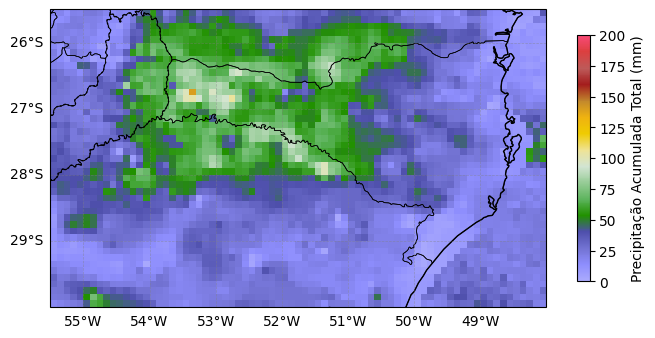

In [51]:
#MERGE CPTEC
"""
Script para calcular a precipitação acumulada de múltiplos arquivos
diários do MERGE, com zoom na Região Sul do Brasil.
"""

# --- 1. Importação das Bibliotecas ---
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart.graph.cm as cm

print("Bibliotecas importadas com sucesso.")

# --- 2. CONFIGURAÇÕES ---
INPUT_DIR = r"C:\Users\Paulo\Documents\INPE"
GRIB_FILENAMES = [
    "MERGE_CPTEC_20230811.grib2",
    "MERGE_CPTEC_20230812.grib2"
]
VARIAVEL_MERGE = 'prec'
OUTPUT_DIR = r"C:\Users\Paulo\Documents\INPE"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CMAP_CHUVA = 'pyart_Theodore16'

# Limites aproximados SC: [Oeste, Leste, Sul, Norte]
SUL_BRASIL_EXTENT = [-55.5, -48, -30, -25.5]
# ---------------------------------------------

# --- 3. EXECUÇÃO DO SCRIPT ---
print(f"Configurações prontas. Zoom definido para a Região Sul: {SUL_BRASIL_EXTENT}")

caminhos_completos = [os.path.join(INPUT_DIR, f) for f in GRIB_FILENAMES]
arquivos_encontrados = all(os.path.exists(p) for p in caminhos_completos)

if not arquivos_encontrados:
    print("ERRO: Um ou mais arquivos da lista não foram encontrados.")
    for p in caminhos_completos:
        if not os.path.exists(p):
            print(f"  -> Arquivo não encontrado: {p}")
else:
    try:
        # Leitura manual e concatenação
        print(f"Lendo e combinando {len(caminhos_completos)} arquivos GRIB manualmente...")
        lista_de_arrays_prec = []
        for caminho in caminhos_completos:
            print(f"  -> Lendo arquivo: {os.path.basename(caminho)}")
            with xr.open_dataset(caminho, engine='cfgrib') as ds_individual:
                lista_de_arrays_prec.append(ds_individual[VARIAVEL_MERGE])

        precip_combinada = xr.concat(lista_de_arrays_prec, dim='dia')
        precip_acumulada = precip_combinada.sum(dim='dia')
        
        lats = ds_individual['latitude']
        lons_raw = ds_individual['longitude']

        lons = np.where(lons_raw > 180, lons_raw - 360, lons_raw)
        precip_acumulada['longitude'] = lons
        precip_acumulada = precip_acumulada.sortby('longitude')
        print("Precipitação acumulada para o período com sucesso.")

        # --- Plotagem do Mapa ---
        print("Iniciando a plotagem do mapa...")
        fig = plt.figure(figsize=(8, 8)) # Ajustado para um formato mais vertical
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        
        # Adiciona elementos geográficos
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'))
        ax.add_feature(cfeature.BORDERS.with_scale('10m'), linestyle=':')
        ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', linewidth=0.5)
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False

        mapa = ax.pcolormesh(
            precip_acumulada['longitude'],
            precip_acumulada['latitude'],
            precip_acumulada.values,
            cmap=CMAP_CHUVA,
            vmin=0,
            vmax=200,
            transform=ccrs.PlateCarree() # Adicionado transform para garantir a projeção correta
        )
        
        # --- ALTERAÇÃO: Aplica o zoom definido ---
        ax.set_extent(SUL_BRASIL_EXTENT, crs=ccrs.PlateCarree())
        # ----------------------------------------
        
        cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', shrink=0.4)
        unidade = ds_individual[VARIAVEL_MERGE].attrs.get("units", "mm")
        cbar.set_label(f'Precipitação Acumulada Total (mm)')
        
        #ax.set_title(f'MERGE/CPTEC', fontsize=16)

        output_filename = os.path.join(OUTPUT_DIR, f"mapa_merge_acumulado_2dias_zoom_sul.png")
        plt.savefig(output_filename, dpi=500, bbox_inches='tight')

        print(f"\nMapa salvo com sucesso como '{output_filename}'")
        plt.show()

    except Exception as e:
        print(f"\nOcorreu um erro durante o processo: {e}")

In [27]:
xrds1 = xr.open_dataset(era5_file)
xrds1

Ignoring index file 'era5monan.grib.5b7b6.idx' older than GRIB file
skipping variable: paramId==228 shortName='tp'
Traceback (most recent call last):
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 721, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 639, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1691712000, 1691715600, 1691719200, 1691722800, 1691726400,
       1691730000, 1691733600, 1691737200, 1691740800, 1691744400,
       1691748000, 1691751600, 1691755200, 1691758800, 1691762400,
       1691766000, 1691769600, 1691773200, 1691776800, 1691780400,
       1691784000, 1691787600, 1691791200, 1691794800, 1691798400,
       1691802000, 1691805600, 1691809200, 1691812800, 1691816400,
       1691820000, 1691823600, 1691827200, 1691830

<xarray.Dataset> Size: 26MB
Dimensions:     (time: 48, latitude: 121, longitude: 161)
Coordinates:
    number      int32 4B ...
  * time        (time) datetime64[ns] 384B 2023-08-11 ... 2023-08-12T23:00:00
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 968B -20.0 -20.25 -20.5 ... -49.75 -50.0
  * longitude   (longitude) float64 1kB -60.0 -59.75 -59.5 ... -20.25 -20.0
    valid_time  (time) datetime64[ns] 384B ...
Data variables:
    u10         (time, latitude, longitude) float32 4MB ...
    v10         (time, latitude, longitude) float32 4MB ...
    d2m         (time, latitude, longitude) float32 4MB ...
    t2m         (time, latitude, longitude) float32 4MB ...
    cape        (time, latitude, longitude) float32 4MB ...
    tcwv        (time, latitude, longitude) float32 4MB ...
    tcrw        (time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-18T11:34 GRIB to CDM+CF via cfgrib-0.9.1...

Bibliotecas importadas com sucesso.
Configurações prontas. Zoom definido para a área: [-54.6152, -50.6152, -29.1, -25.1]

--- Processando o arquivo IMERG: 3B-HHR-E.MS.MRG.3IMERG.20230812-S000000-E002959.0000.V07B.HDF5 ---
Arquivo 3B-HHR-E.MS.MRG.3IMERG.20230812-S000000-E002959.0000.V07B.HDF5 processado com sucesso.
Iniciando a plotagem de: mapa_imerg_chapeco_202308120000.png (título: '')
Mapa salvo com sucesso em: C:\Users\Paulo\Documents\INPE\SAIDAS_IMERG12\IMERG_mapas_30min\mapa_imerg_chapeco_202308120000.png

--- Processando o arquivo IMERG: 3B-HHR-E.MS.MRG.3IMERG.20230812-S003000-E005959.0030.V07B.HDF5 ---
Arquivo 3B-HHR-E.MS.MRG.3IMERG.20230812-S003000-E005959.0030.V07B.HDF5 processado com sucesso.
Iniciando a plotagem de: mapa_imerg_chapeco_202308120030.png (título: '')
Mapa salvo com sucesso em: C:\Users\Paulo\Documents\INPE\SAIDAS_IMERG12\IMERG_mapas_30min\mapa_imerg_chapeco_202308120030.png

--- Processando o arquivo IMERG: 3B-HHR-E.MS.MRG.3IMERG.20230812-S010000-E012959.0060.

KeyboardInterrupt: 

In [41]:
#1
# -*- coding: utf-8 -*-
"""
Script para calcular e plotar mapas de PRECIPITAÇÃO TOTAL ACUMULADA 
do modelo MPAS e do satélite IMERG, com a mesma área e escala de cores.
"""

# --- 1. Importação das Bibliotecas ---
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

print("Bibliotecas importadas com sucesso.")

# --- 2. Configuração dos Caminhos e Parâmetros ---
IMERG_DIR = r"C:\Users\Paulo\Documents\INPE\IMERG\"
MODEL_DIR = r"C:\Users\Paulo\Documents\Python Scripts\2023081100\recorte"
OUTPUT_DIR = r"C:\Users\Paulo\Documents\INPE"

VARIAVEL_MODELO = 'prec'
VARIAVEL_IMERG = 'precipitation'
CMAP_CHUVA = 'pyart_Theodore16'

OUTPUT_IMERG_PATH = os.path.join(OUTPUT_DIR, 'IMERG_mapas_comparativo')
OUTPUT_MODEL_PATH = os.path.join(OUTPUT_DIR, 'MPAS_mapas_comparativo')
os.makedirs(OUTPUT_IMERG_PATH, exist_ok=True)
os.makedirs(OUTPUT_MODEL_PATH, exist_ok=True)

print(f"Pastas de saída verificadas/criadas.")

# --- 3. Função de Plotagem Aprimorada ---
def plotar_mapa_precipitacao(dados, lats, lons, titulo, caminho_salvar, nome_arquivo, cmap, extent=None, vmin=None, vmax=None):
    """
    Gera um mapa de precipitação com opções para zoom e escala de cores unificada.
    """
    print(f"Iniciando a plotagem de: {titulo}")
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.coastlines(resolution='50m', color='black', linewidth=0.8)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    mapa = plt.pcolormesh(lons, lats, dados, cmap=cmap, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)
    
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', pad=0.05, aspect=20)
    cbar.set_label('Precipitação Acumulada Total (mm)', fontsize=12)
    ax.set_title(titulo, fontsize=16, pad=20)
    
    caminho_completo = os.path.join(caminho_salvar, nome_arquivo)
    plt.savefig(caminho_completo, dpi=300, bbox_inches='tight')
    print(f"Mapa salvo com sucesso em: {caminho_completo}")
    plt.close(fig)

# --- 4. PROCESSAMENTO DOS DADOS ---
precip_acumulada_modelo = None
precip_acumulada_imerg = None
lats_modelo, lons_modelo = None, None
lats_imerg, lons_imerg = None, None
modelo_extent = None

try:
    print("\n--- Processando dados ACUMULADOS do Modelo MPAS ---")
    padrao_modelo = os.path.join(MODEL_DIR, '*.nc')
    ds_modelo = xr.open_mfdataset(glob.glob(padrao_modelo), combine='by_coords', engine='netcdf4')
    precip_acumulada_modelo = ds_modelo[VARIAVEL_MODELO].sum(dim='Time')
    lats_modelo = ds_modelo['latitude']
    lons_modelo = ds_modelo['longitude']
    print("Dados do MPAS carregados e somados.")

    # CORREÇÃO: Usando .compute() em vez de .item() para funcionar com Dask
    lat_min, lat_max = lats_modelo.min().compute(), lats_modelo.max().compute()
    lon_min, lon_max = lons_modelo.min().compute(), lons_modelo.max().compute()
    modelo_extent = [-55.5, -48, -30, -25.5]
    print(f"Área do modelo definida: {modelo_extent}")
    
except Exception as e:
    print(f"ERRO ao processar os arquivos do modelo MPAS: {e}")

try:
    print("\n--- Processando dados ACUMULADOS do Satélite IMERG ---")
    padrao_imerg = os.path.join(IMERG_DIR, '*.HDF5*')
    ds_imerg = xr.open_mfdataset(glob.glob(padrao_imerg), group='Grid', combine='by_coords', engine='h5netcdf')
    precip_acumulada_imerg = ds_imerg[VARIAVEL_IMERG].sum(dim='time').transpose('lat', 'lon')
    lats_imerg = ds_imerg['lat']
    lons_imerg = ds_imerg['lon']
    print("Dados do IMERG carregados e somados.")

except Exception as e:
    print(f"ERRO ao processar os arquivos do IMERG: {e}")

# --- 5. PLOTAGEM COMPARATIVA ---
if precip_acumulada_modelo is not None and precip_acumulada_imerg is not None:

    # CORREÇÃO: Usando .compute() em vez de .item() para funcionar com Dask
    min_global = min(precip_acumulada_modelo.min().compute(), precip_acumulada_imerg.min().compute())
    max_global = max(precip_acumulada_modelo.max().compute(), precip_acumulada_imerg.max().compute())
    print(f"\nEscala de cores unificada definida: min={min_global:.2f}, max={max_global:.2f}")

    plotar_mapa_precipitacao(
        dados=precip_acumulada_modelo.values,
        lats=lats_modelo.values,
        lons=lons_modelo.values,
        titulo=f'',
        caminho_salvar=OUTPUT_MODEL_PATH,
        nome_arquivo='mapa_precip_comparativo_mpas12.png',
        cmap=CMAP_CHUVA,
        vmin=min_global,
        vmax=max_global
    )

    plotar_mapa_precipitacao(
        dados=precip_acumulada_imerg.values,
        lats=lats_imerg.values,
        lons=lons_imerg.values,
        titulo=f'',
        caminho_salvar=OUTPUT_IMERG_PATH,
        nome_arquivo='mapa_precip_comparativo_imerg12.png',
        cmap=CMAP_CHUVA,
        extent=modelo_extent,
        vmin=min_global,
        vmax=max_global
    )

else:
    print("\nUm dos conjuntos de dados falhou ao carregar. A plotagem comparativa foi cancelada.")

print("\nScript finalizado.")

Bibliotecas importadas com sucesso.
Pastas de saída verificadas/criadas.

--- Processando dados ACUMULADOS do Modelo MPAS ---
Dados do MPAS carregados e somados.
Área do modelo definida: [-55.5, -48, -30, -25.5]

--- Processando dados ACUMULADOS do Satélite IMERG ---
Dados do IMERG carregados e somados.

Escala de cores unificada definida: min=0.00, max=578.68
Iniciando a plotagem de: 
Mapa salvo com sucesso em: C:\Users\Paulo\Documents\INPE\MPAS_mapas_comparativo\mapa_precip_comparativo_mpas11.png
Iniciando a plotagem de: 
Mapa salvo com sucesso em: C:\Users\Paulo\Documents\INPE\IMERG_mapas_comparativo\mapa_precip_comparativo_imerg11.png

Script finalizado.


In [53]:
#IMERG 
"""
Script para comparar a PRECIPITAÇÃO ACUMULADA do modelo MPAS com um 
arquivo diário do IMERG
"""

# --- 1. Importação das Bibliotecas ---
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart.graph.cm as cm

print("Bibliotecas importadas com sucesso.")

# --- 2. CONFIGURAÇÕES ---
IMERG_DIR = r"C:\Users\Paulo\Documents\INPE\IMERG"
MODEL_DIR = r"C:\Users\Paulo\Documents\Python Scripts\2023081100\Full"
OUTPUT_DIR = r"C:\Users\Paulo\Documents\INPE"

#IMERG_FILENAME = "IMERG11.nc4" 
VARIAVEL_MODELO = 'prec'
VARIAVEL_IMERG = 'precipitation'

CMAP_CHUVA = 'pyart_Theodore16'

# Definição do Zoom em Chapecó
LAT_CHAPECO = -27.1
LON_CHAPECO = -52.6
GRAUS_ZOOM = 2.0
chapeco_extent = [
    -55.5, -48,
    -30, -25.5
]

OUTPUT_IMERG_PATH = os.path.join(OUTPUT_DIR, 'IMERG_mapas_chapeco')
OUTPUT_MODEL_PATH = os.path.join(OUTPUT_DIR, 'MPAS_mapas_chapeco')
os.makedirs(OUTPUT_IMERG_PATH, exist_ok=True)
os.makedirs(OUTPUT_MODEL_PATH, exist_ok=True)

print(f"Configurações prontas. Zoom definido para a área: {chapeco_extent}")

# --- 3. Função de Plotagem (com alterações) ---
def plotar_mapa_precipitacao(dados, lats, lons, caminho_salvar, nome_arquivo, cmap, extent=None, vmin=None, vmax=None):
    print(f"Iniciando a plotagem de: {nome_arquivo}") # Título removido, agora informa o nome do arquivo
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, edgecolor='gray', linewidth=0.6)
    estados = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
    ax.add_feature(estados, edgecolor='black', linewidth=0.6)
    
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    mapa = plt.pcolormesh(lons, lats, dados, cmap=cmap, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)
    
    if extent:
        ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # --- ALTERAÇÃO APLICADA AQUI ---
    cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', shrink=0.5)
    cbar.set_label('Precipitação Acumulada Total (mm)', fontsize=12)
    # Título já estava comentado/removido do plot.
    
    caminho_completo = os.path.join(caminho_salvar, nome_arquivo)
    plt.savefig(caminho_completo, dpi=500, bbox_inches='tight')
    print(f"Mapa salvo com sucesso em: {caminho_completo}")
    plt.close(fig)

# --- 4. PROCESSAMENTO DOS DADOS (sem alterações) ---
precip_acumulada_modelo = None
precip_acumulada_imerg = None

try:
    print("\n--- Processando e acumulando dados do Modelo MPAS ---")
    padrao_modelo = os.path.join(MODEL_DIR, '*.nc')
    ds_modelo = xr.open_mfdataset(glob.glob(padrao_modelo), combine='by_coords', engine='netcdf4')
    precip_acumulada_modelo_raw = ds_modelo[VARIAVEL_MODELO].sum(dim='Time')
    lats_modelo = ds_modelo['latitude']
    lons_modelo_raw = ds_modelo['longitude']
    
    print("Verificando e corrigindo a convenção de longitude do modelo...")
    lons_modelo_corrigida = np.where(lons_modelo_raw > 180, lons_modelo_raw - 360, lons_modelo_raw)
    precip_acumulada_modelo = precip_acumulada_modelo_raw.assign_coords(longitude=lons_modelo_corrigida)
    precip_acumulada_modelo = precip_acumulada_modelo.sortby('longitude')
    lons_modelo = precip_acumulada_modelo['longitude']
    print("Dados do MPAS carregados, somados e com longitude corrigida.")
    
except Exception as e:
    print(f"ERRO ao processar os arquivos do modelo MPAS: {e}")

try:
    print(f"\n--- Processando e somando os arquivos diários do IMERG ---")
    
    imerg_files = ['IMERG.nc4', 'IMERG11.nc4']
    imerg_paths = [os.path.join(IMERG_DIR, f) for f in imerg_files]
    
    # Abrir os dois arquivos individualmente
    ds_list = [xr.open_dataset(fp) for fp in imerg_paths]
    
    # Extrair e somar os campos de precipitação
    precip_list = [ds[VARIAVEL_IMERG].squeeze(drop=True) for ds in ds_list]
    precip_soma = precip_list[0] + precip_list[1]

    # Ajustar dimensões e coordenadas
    precip_acumulada_imerg = precip_soma.transpose('lat', 'lon')
    lats_imerg = ds_list[0]['lat']
    lons_imerg = ds_list[0]['lon']

    # Fechar os arquivos
    for ds in ds_list:
        ds.close()

    print("Soma dos arquivos IMERG concluída.")

except Exception as e:
    print(f"ERRO ao processar os arquivos do IMERG: {e}")


# --- 5. PLOTAGEM COMPARATIVA (com alterações) ---
if precip_acumulada_modelo is not None and precip_acumulada_imerg is not None:

    # --- NOVO: Mascarar valores de precipitação zero ---
    # O método .where() do xarray mantém os valores onde a condição é verdadeira
    # e substitui os outros (zero e negativos) por NaN (Not a Number).
    # O Matplotlib não desenha valores NaN, deixando-os transparentes.
    print("\nAplicando máscara para remover valores de precipitação zero...")
    precip_acumulada_modelo = precip_acumulada_modelo.where(precip_acumulada_modelo > 0)
    precip_acumulada_imerg = precip_acumulada_imerg.where(precip_acumulada_imerg > 0)
    # ----------------------------------------------------

    # --- ALTERAÇÃO ---
    # Ajusta a escala de cores para começar em 1, já que os zeros foram removidos.
    min_global = 1 
    max_global = 200
    print(f"Escala de cores FIXA definida: min={min_global}, max={max_global} mm")
    # -----------------

    # --- ALTERAÇÃO APLICADA AQUI (chamada da função sem o título) ---
    plotar_mapa_precipitacao(
        dados=precip_acumulada_modelo.values,
        lats=lats_modelo.values,
        lons=lons_modelo.values,
        caminho_salvar=OUTPUT_MODEL_PATH,
        nome_arquivo='mapa_mpas_chapeco_mascaradoT.png',
        cmap=CMAP_CHUVA,
        extent=chapeco_extent,
        vmin=min_global,
        vmax=max_global
    )
    
    # --- ALTERAÇÃO APLICADA AQUI (chamada da função sem o título) ---
    plotar_mapa_precipitacao(
        dados=precip_acumulada_imerg.values,
        lats=lats_imerg.values,
        lons=lons_imerg.values,
        caminho_salvar=OUTPUT_IMERG_PATH,
        nome_arquivo='mapa_imerg_chapeco_mascaradoT.png',
        cmap=CMAP_CHUVA,
        extent=chapeco_extent,
        vmin=min_global,
        vmax=max_global
    )

else:
    print("\nUm dos conjuntos de dados falhou ao carregar. A plotagem comparativa foi cancelada.")

print("\nScript finalizado.")

Bibliotecas importadas com sucesso.
Configurações prontas. Zoom definido para a área: [-55.5, -48, -30, -25.5]

--- Processando e acumulando dados do Modelo MPAS ---
Verificando e corrigindo a convenção de longitude do modelo...
Dados do MPAS carregados, somados e com longitude corrigida.

--- Processando e somando os arquivos diários do IMERG ---
Soma dos arquivos IMERG concluída.

Aplicando máscara para remover valores de precipitação zero...
Escala de cores FIXA definida: min=1, max=200 mm
Iniciando a plotagem de: mapa_mpas_chapeco_mascaradoT.png
Mapa salvo com sucesso em: C:\Users\Paulo\Documents\INPE\MPAS_mapas_chapeco\mapa_mpas_chapeco_mascaradoT.png
Iniciando a plotagem de: mapa_imerg_chapeco_mascaradoT.png
Mapa salvo com sucesso em: C:\Users\Paulo\Documents\INPE\IMERG_mapas_chapeco\mapa_imerg_chapeco_mascaradoT.png

Script finalizado.


In [17]:
#ESTATÍSTICAS ERA5 MODELO MONAN
import os
import glob
import xarray as xr
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ===================================================================
# CONFIGURAÇÕES
# ===================================================================
model_dir = r"C:\Users\Paulo\Documents\Python Scripts\2023081100\Full"
era5_file = "era5monan.grib"
variable_map = {
    'u10': 'u10',
    'v10': 'v10',
    't2m': 't2m',
    'cape': 'cape',
    'precipw': 'tcwv'
}
end_datetime_str = '2023081223'

# --- ALTERAÇÃO: Salvar o CSV na Área de Trabalho ---
# Pega o caminho para o diretório 'home' do usuário
home_dir = os.path.expanduser('~')
# Constrói o caminho para a Área de Trabalho (funciona para nomes em Português ou Inglês)
desktop_path = os.path.join(home_dir, 'Área de Trabalho')
if not os.path.exists(desktop_path):
    desktop_path = os.path.join(home_dir, 'Desktop')
# Define o nome do arquivo de saída e o caminho completo
output_filename = 'estatisticas_horarias_modelo_vs_era5.csv'
output_csv_path = os.path.join(desktop_path, output_filename)
# ---------------------------------------------------

# ===================================================================
# INÍCIO DO SCRIPT
# ===================================================================

print("Iniciando a análise estatística horária...")

# 1. Carrega o ERA5 uma única vez
print(f"Carregando o arquivo ERA5: {era5_file}...")
era5_ds = xr.open_dataset(era5_file, engine='cfgrib')
era5_ds = era5_ds.sel(time=slice(None, f'{end_datetime_str[:4]}-{end_datetime_str[4:6]}-{end_datetime_str[6:8]}'))
print("Dados do ERA5 carregados e filtrados.")

# ===================================================================
# LÓGICA PARA ENCONTRAR E FILTRAR PARES DE ARQUIVOS
# ===================================================================
def get_key_from_model(filename):
    try:
        return filename.split('_')[6][:10]
    except IndexError:
        return None

def get_key_from_radar(filename): # Embora não usado aqui, mantido para referência
    try:
        return filename.split('_')[1][:10]
    except IndexError:
        return None

# Filtra a lista de arquivos do modelo para incluir apenas até a data e hora final
all_model_files = sorted(glob.glob(os.path.join(model_dir, '*.nc')))
model_files_filtered = []
for f in all_model_files:
    key = get_key_from_model(f)
    if key and key <= end_datetime_str:
        model_files_filtered.append(f)

print(f"Encontrados {len(model_files_filtered)} arquivos do modelo para processar (filtrado até {end_datetime_str}).")

results_list = []

# 3. Loop para processar CADA ARQUIVO DO MODELO INDIVIDUALMENTE
for model_file in model_files_filtered:
    try:
        print(f"Processando arquivo: {os.path.basename(model_file)}")
        model_ds_single = xr.open_dataset(os.path.join(model_dir, model_file))
        
        model_time = model_ds_single.Time.values[0]
        
        era5_ds_single_time = era5_ds.sel(time=model_time, method='nearest')
        
        era5_interp_ds = era5_ds_single_time.interp_like(model_ds_single, method='linear')
        
        for model_var, era5_var in variable_map.items():
            if model_var in model_ds_single and era5_var in era5_interp_ds:
                model_da = model_ds_single[model_var]
                era5_da = era5_interp_ds[era5_var]

                model_vals = model_da.values.flatten()
                era5_vals = era5_da.values.flatten()
                
                mask = np.isfinite(model_vals) & np.isfinite(era5_vals)
                
                if np.sum(mask) > 1:
                    bias = np.mean(model_vals[mask] - era5_vals[mask])
                    rmse = np.sqrt(np.mean((model_vals[mask] - era5_vals[mask]) ** 2))
                    corr, _ = pearsonr(model_vals[mask], era5_vals[mask])
                    
                    results_list.append({
                        'Tempo': pd.to_datetime(str(model_time)),
                        'Variavel': model_var,
                        'Bias': bias,
                        'RMSE': rmse,
                        'Correlacao_Pearson': corr
                    })
        
        model_ds_single.close()

    except Exception as e:
        print(f"  -> ERRO ao processar o arquivo {os.path.basename(model_file)}: {e}")

# 4. Salvar os Resultados
print("\nSalvando os resultados...")
if results_list:
    stats_df = pd.DataFrame(results_list)
    # --- ALTERAÇÃO: Usa o caminho completo para a área de trabalho ---
    stats_df.to_csv(output_csv_path, index=False, float_format='%.3f')
    print(f"Análise concluída com sucesso! Resultados salvos em '{output_csv_path}'")
    print("\nResumo das Estatísticas por Hora:")
    print(stats_df.tail())
else:
    print("Nenhuma variável pôde ser processada.")

Ignoring index file 'era5monan.grib.5b7b6.idx' older than GRIB file


Iniciando a análise estatística horária...
Carregando o arquivo ERA5: era5monan.grib...


skipping variable: paramId==228 shortName='tp'
Traceback (most recent call last):
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 721, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 639, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1691712000, 1691715600, 1691719200, 1691722800, 1691726400,
       1691730000, 1691733600, 1691737200, 1691740800, 1691744400,
       1691748000, 1691751600, 1691755200, 1691758800, 1691762400,
       1691766000, 1691769600, 1691773200, 1691776800, 1691780400,
       1691784000, 1691787600, 1691791200, 1691794800, 1691798400,
       1691802000, 1691805600, 1691809200, 1691812800, 1691816400,
       1691820000, 1691823600, 1691827200, 1691830800, 1691834400,
       1691838000, 1691841600, 1691845200, 16918488

Dados do ERA5 carregados e filtrados.
Encontrados 38 arquivos do modelo para processar (filtrado até 2023081223).
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081100.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081101.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081102.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081103.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081104.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081105.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081106.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081107.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081108.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_POS_ERA5_2023081100_2023081109.mm.x20.835586L55.nc
Processando arquivo: MONAN_DIAG_R_PO

In [ ]:
# CAPE ERA5 
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pandas as pd
import pyart

# Caminho para o arquivo GRIB
arquivo_grib = 'C:/Users/Paulo/Documents/Python Scripts/ERA5/resto.grib'

# Caminho para a pasta onde os gráficos serão salvos
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/'
os.makedirs(output_path, exist_ok=True)

# Parâmetros de escala
vmin_global = 10
vmax_global = 4200
levels = np.arange(vmin_global, vmax_global + 100, 100)
cmap1 = 'pyart_Theodore16'  # cmap padrão do Matplotlib

print(f"Abrindo arquivo: {arquivo_grib}")

xrds = xr.open_dataset(arquivo_grib, engine='cfgrib')  # usa engine explícito para GRIB

cape = xrds['cape']
lat = xrds['latitude']
lon = xrds['longitude']
tempos = xrds['time']

# Iterar sobre cada tempo no arquivo
for i, tempo in enumerate(tempos):
    data_hora = pd.to_datetime(tempo.values).strftime('%Y%m%d_%H%M')

    plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    cape_plot = ax.contourf(
        lon, lat, cape.isel(time=i),
        transform=ccrs.PlateCarree(),
        cmap=cmap1, alpha=0.9, levels=levels, extend='max'
    )

    cbar = plt.colorbar(cape_plot, label='CAPE (J/kg)')
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

    ax.coastlines(resolution='10m', color='black', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
    estados = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_1_states_provinces_lines',
        scale='10m', facecolor='none')
    ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

    # Ajuste para a América do Sul Sul
    ax.set_extent([-63, -40, -40, -20], crs=ccrs.PlateCarree())

    # Grade com rótulos
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    #plt.title(f'CAPE - {data_hora}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Nome do arquivo de saída
    output_filename = os.path.join(output_path, f'CAPE_{data_hora}.png')
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.close()

xrds.close()


skipping variable: paramId==228001 shortName='cin'
Traceback (most recent call last):
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 721, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 639, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1691712000, 1691715600, 1691719200, 1691722800, 1691726400,
       1691730000, 1691733600, 1691737200, 1691740800, 1691744400,
       1691748000, 1691751600, 1691755200, 1691758800, 1691762400,
       1691766000, 1691769600, 1691773200, 1691776800, 1691780400,
       1691784000, 1691787600, 1691791200, 1691794800, 1691798400,
       1691802000, 1691805600, 1691809200, 1691812800, 1691816400,
       1691820000, 1691823600, 1691827200, 1691830800, 1691834400,
       1691838000, 1691841600, 1691845200, 1691

Abrindo arquivo: C:/Users/Paulo/Documents/Python Scripts/ERA5/resto.grib


skipping variable: paramId==228029 shortName='i10fg'
Traceback (most recent call last):
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 721, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\Paulo\anaconda3\Lib\site-packages\cfgrib\dataset.py", line 639, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='time' value=Variable(dimensions=('time',), data=array([1691712000, 1691715600, 1691719200, 1691722800, 1691726400,
       1691730000, 1691733600, 1691737200, 1691740800, 1691744400,
       1691748000, 1691751600, 1691755200, 1691758800, 1691762400,
       1691766000, 1691769600, 1691773200, 1691776800, 1691780400,
       1691784000, 1691787600, 1691791200, 1691794800, 1691798400,
       1691802000, 1691805600, 1691809200, 1691812800, 1691816400,
       1691820000, 1691823600, 1691827200, 1691830800, 1691834400,
       1691838000, 1691841600, 1691845200, 16

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x0000027D9716B600> (for post_execute), with arguments args (),kwargs {}:



KeyboardInterrupt



Error in callback <function flush_figures at 0x0000027DA3C8ADE0> (for post_execute), with arguments args (),kwargs {}:


In [74]:
#CIN
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Caminho para a pasta que contém os arquivos .nc
pasta = 'C:/Users/Paulo/Documents/Python Scripts/2024091900/'

# Caminho para a pasta onde os gráficos serão salvos
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20240919/CIN/'
os.makedirs(output_path, exist_ok=True)

# Mínimo e máximo da escala
vmin_global = 0
vmax_global = 700

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
        nome_arquivo = os.path.basename(arquivo)
        data_hora = nome_arquivo.split('_')[6]  # A data e hora estão na posição 6
        data_hora = data_hora.split('.')[0]
        
        xrds = xr.open_dataset(caminho_arquivo)
        cape = xrds['cin']  
            
        lat = xrds['latitude']
        lon = xrds['longitude']
               
        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        cmap.set_over('red')
        # Fixar escala usando níveis com np.linspace
        levels = np.arange(vmin_global, vmax_global + 50, 50)
        cape_plot = ax.contourf(lon, lat, cape[0, :, :], transform=ccrs.PlateCarree(),
                                cmap=trimmed_cmap,extend='max', alpha=0.8, levels=levels)
        plt.colorbar(cape_plot, label='CIN (J/kg)')
        
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        
        estados = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)
        
        ax.set_extent([-63, -40, -40, -20], crs=ccrs.PlateCarree())
         # Adicionar rótulos de latitude e longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}

        plt.title(f'CIN - {data_hora}')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        
        # Definir o nome do arquivo de saída usando o nome do arquivo .nc
        output_filename = os.path.join(output_path, f'CIN_{os.path.splitext(arquivo)[0]}.png')
    
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        #plt.open()

        xrds.close()
        plt.close()


In [3]:
# Água Precipitável ERA5
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
import pyart 
# Caminhos
arquivo = 'C:/Users/Paulo/Documents/Python Scripts/ERA5/precipw.nc'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/WPrec_ERA5/'
os.makedirs(output_path, exist_ok=True)

# Shapefile de Santa Catarina (opcional)
shp_path = 'SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5
)

estados_feature = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none',
    edgecolor='black',
    linewidth=0.5
)

# Parâmetros do zoom
set_lon = -52.6152
set_lat = -27.1000
delta = 4

# Intervalo de cores
vmin_global = 1
vmax_global = 75

# Abrir o dataset
ds = xr.open_dataset(arquivo)
lat = ds['latitude'].values
lon = ds['longitude'].values
tcwv = ds['tcwv']

# Loop para cada tempo
for i in range(tcwv.shape[0]):
    data_hora = ds['valid_time'].isel(valid_time=i).dt.strftime('%H:%M UTC %d/%m/%Y').item()
    
    # Dados de água precipitável
    campo = tcwv.isel(valid_time=i)
    
    # Plotagem
    plt.figure(figsize=(12, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())

    levels = np.linspace(vmin_global, vmax_global, 100)
    plot = ax.contourf(
        lon, lat, campo,
        transform=ccrs.PlateCarree(),
        cmap='pyart_Theodore16',
        levels=levels,
        extend='max'
    )
    plt.colorbar(plot, label='Água Precipitável (kg/m²)')

    # Elementos do mapa
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(estados_feature)
    # ax.add_feature(municipios_feature)

    ax.set_extent([-63, -40, -40, -20], crs=ccrs.PlateCarree())

    ax.plot(set_lon, set_lat, marker='*', color='yellow', markersize=10,
            transform=ccrs.PlateCarree(), markeredgecolor='black')

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=1)
    gl.top_labels = gl.right_labels = False

    # Título e salvamento
    #plt.title(f'Água Precipitável - {data_hora}', fontsize=14)
    nome_arquivo = f'PrecipW_ERA5_{i:03d}.png'
    plt.savefig(os.path.join(output_path, nome_arquivo), dpi=300, bbox_inches='tight')
    plt.close()


In [ ]:
#Água precipitável MONAN
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
import pyart  # Necessário para carregar o colormap pyart_Theodore16

# --- CONFIGURAÇÕES DE DIRETÓRIOS ---
# Ajuste PASTA_INPUT para o diretório onde estão os seus arquivos do MONAN
PASTA_INPUT = '/home/jovyan/privado/MONAN/granizo2308/2023081100/' 
OUTPUT_PATH = '/home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# --- CONFIGURAÇÕES VISUAIS E DE MAPA ---
set_lon, set_lat = -52.6152, -27.1000
vmin_global, vmax_global = 1, 75
EXTENT = [-63, -40, -40, -20]

estados_feature = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none', edgecolor='black', linewidth=0.5
)

# Shapefile (Descomente se for utilizar)
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(), ccrs.PlateCarree(),
    edgecolor='black', facecolor='none', linewidth=0.5
)

# --- LISTAGEM DE ARQUIVOS ---
# O sorted garante que os mapas sejam gerados em ordem cronológica
arquivos_nc = sorted(glob.glob(os.path.join(PASTA_INPUT, '*.nc')))

print(f"Iniciando o processamento de {len(arquivos_nc)} arquivos...")

# --- LOOP DE PROCESSAMENTO ---
for caminho_arquivo in arquivos_nc:
    nome_arquivo = os.path.basename(caminho_arquivo)
    
    # Extração da string de data/hora a partir do nome do arquivo MONAN
    # Exemplo base: MONAN_..._2023081100...
    try:
        raw_data = nome_arquivo.split('_')[6].split('.')[0]
        data_hora_str = f"{raw_data[8:10]}Z {raw_data[6:8]}/{raw_data[4:6]}/{raw_data[:4]}"
    except IndexError:
        data_hora_str = "Data Desconhecida"
        raw_data = nome_arquivo.split('.')[0] # Fallback para o nome do arquivo

    try:
        # Abertura com gerenciamento de contexto (fecha automaticamente após o bloco)
        with xr.open_dataset(caminho_arquivo) as ds:
            
            # Verificação de segurança (evita que o script quebre se um arquivo estiver corrompido)
            if 'precipw' not in ds:
                print(f"Variável 'precipw' não encontrada em {nome_arquivo}. Pulando.")
                continue

            # Extração dos dados (Assume-se que o tempo seja o índice 0)
            campo = ds['precipw'][0].values
            lat = ds['latitude'].values
            lon = ds['longitude'].values

        # --- PLOTAGEM ---
        fig = plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())

        levels = np.linspace(vmin_global, vmax_global, 100)
        
        plot = ax.contourf(
            lon, lat, campo,
            transform=ccrs.PlateCarree(),
            cmap='Theodore16',
            levels=levels,
            extend='max'
        )
        
        plt.colorbar(plot, label='Água Precipitável (kg/m²)')

        # Elementos do mapa
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
        ax.add_feature(estados_feature)
        # ax.add_feature(municipios_feature)

        ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

        ax.plot(set_lon, set_lat, marker='*', color='yellow', markersize=10,
                transform=ccrs.PlateCarree(), markeredgecolor='black')

        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=1)
        gl.top_labels = gl.right_labels = False

        plt.title(f'Água Precipitável (MONAN)\nData: {data_hora_str}', fontsize=14, loc='left', weight='bold')
        
        # Salvamento
        output_filename = os.path.join(OUTPUT_PATH, f'PrecipW_MONAN_{raw_data}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close(fig) # Fundamental para não sobrecarregar a memória RAM
        
        print(f" -> {output_filename} salvo com sucesso.")

    except Exception as e:
        print(f"Erro ao processar o arquivo {nome_arquivo}: {e}")

print("Processamento finalizado.")

Iniciando o processamento de 73 arquivos...
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081100.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081101.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081102.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081103.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081104.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081105.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081106.png salvo com sucesso.
 -> /home/jovyan/privado/MONAN/granizo202308/Saidas202308/WPrec_MONAN/PrecipW_MONAN_2023081107.png salvo com sucesso.
 -> /home/jo

In [24]:
# W max
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
radar_lat = -27.5969
radar_lon = -48.5468
# Configurações
pasta = 'C:/Users/Paulo/Documents/Python Scripts/20250115/diag'
# --- Pastas de saída separadas para organização ---
output_path_w_vel = 'C:/Users/Paulo/Documents/INPE/Caso 20250115/WVelMax/'
output_path_wind_speed = 'C:/Users/Paulo/Documents/INPE/Caso 20250115/WindSpeedMax/'
os.makedirs(output_path_w_vel, exist_ok=True)
os.makedirs(output_path_wind_speed, exist_ok=True)

# Shapefile de Santa Catarina (opcional)
shp_path = 'SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5
)
estados_feature = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none',
    edgecolor='black',
    linewidth=0.5
)
# Parâmetros do zoom
set_lon = -52.6152  # Longitude do ponto central
set_lat = -27.1000  # Latitude do ponto central

# --- Loop principal para processar os arquivos ---
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
        # Extração de data/hora do nome do arquivo
        nome_arquivo_base = os.path.splitext(arquivo)[0]
        raw_data_hora = nome_arquivo_base.split('_')[6]
        data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        
        # Abrir o dataset
        xrds = xr.open_dataset(caminho_arquivo)
        
        # Extrair coordenadas (comum a ambos os plots)
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
        
        #==============================================================
        # PLOT 1: Velocidade Vertical Máxima (w_velocity_max)
        #==============================================================
        
        # Extrair a variável
        w_vel = xrds['w_velocity_max'][0, :, :]
        
        # Configurar plot
        plt.figure(figsize=(12, 10))
        ax1 = plt.axes(projection=ccrs.PlateCarree())
        
        # --- Limites e cmap para velocidade vertical ---
        vmin_w = 1
        vmax_w = 40
        levels_w = np.linspace(vmin_w, vmax_w, 101)
        
        # Camada de dados
        plot1 = ax1.contourf(
            lon, lat, w_vel,
            transform=ccrs.PlateCarree(),
            cmap='pyart_Wild25',  # Mapa de cores ideal para valores positivos e negativos
            levels=levels_w,
            extend='max' # Extender para valores maiores e menores
        )
        cbar1 = plt.colorbar(plot1, shrink=0.85)
        cbar1.set_label(label='Max W Velocity (m/s)', fontsize=14)
        
        # Elementos do mapa
        ax1.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax1.add_feature(estados_feature)
        
        # Zoom na região
        ax1.set_extent([radar_lon -3.5, radar_lon+3.5, radar_lat-3.5, radar_lat+3.5], crs=ccrs.PlateCarree())
        
        # Marcador e grades
        ax1.plot(set_lon, set_lat, marker='*', color='yellow', markersize=10,
                 transform=ccrs.PlateCarree(), markeredgecolor='black')
        gl1 = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=1)
        gl1.top_labels = gl1.right_labels = False
        
        # Títulos
        plt.suptitle(f'{data_hora}', fontsize=18, ha='left', x=0.13, y=0.93, fontweight='bold')
        plt.title(f'Max Collum Vertical Velocity (Shaded)', ha='left', fontsize=12, x=0)
        
        # Salvar figura
        output_filename1 = os.path.join(output_path_w_vel, f'WVelMax_{nome_arquivo_base}.png')
        plt.savefig(output_filename1, dpi=300, bbox_inches='tight')
        plt.close() # Fecha a figura para liberar memória

        #==================================================================
        # PLOT 2: Velocidade do Vento Máxima (wind_speed_level1_max)
        #==================================================================
        
        # Extrair a variável
        wind_speed = xrds['wind_speed_level1_max'][0, :, :]
        # Configurar plot
        plt.figure(figsize=(12, 10))
        ax2 = plt.axes(projection=ccrs.PlateCarree())
        
        # --- Limites e cmap para velocidade do vento (mapa sequencial) ---
        vmin_ws = 1
        vmax_ws = 40 
        levels_ws = np.linspace(vmin_ws, vmax_ws, 100)
        
        # Camada de dados
        plot2 = ax2.contourf(
            lon, lat, wind_speed,
            transform=ccrs.PlateCarree(),
            cmap='pyart_SCook18', # Um bom mapa de cores sequencial
            levels=levels_ws,
            extend='max'
        )
        cbar2 = plt.colorbar(plot2, shrink=0.85)
        cbar2.set_label(label='Max Wind Speed at Level 1 (m/s)', fontsize=14)
        
        # Elementos do mapa (mesmos do plot anterior)
        ax2.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax2.add_feature(estados_feature)
        ax2.set_extent([radar_lon -3.5, radar_lon+3.5, radar_lat-3.5, radar_lat+3.5], crs=ccrs.PlateCarree())
        ax2.plot(set_lon, set_lat, marker='*', color='yellow', markersize=10,
                 transform=ccrs.PlateCarree(), markeredgecolor='black')
        gl2 = ax2.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=1)
        gl2.top_labels = gl2.right_labels = False
        
        # Títulos
        plt.suptitle(f'{data_hora}', fontsize=18, ha='left', x=0.13, y=0.93, fontweight='bold')
        plt.title(f'Max Wind Speed at Level 1 (Shaded)', ha='left', fontsize=12, x=0)
        
        # Salvar figura
        output_filename2 = os.path.join(output_path_wind_speed, f'WindSpeedMax_{nome_arquivo_base}.png')
        plt.savefig(output_filename2, dpi=300, bbox_inches='tight')
        plt.close() # Fecha a figura para liberar memória
        
        # Fechar o arquivo NetCDF
        xrds.close()

print("Processamento concluído!")

Processamento concluído!


In [13]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np

# --- CONFIGURAÇÕES ---
# Coordenadas do Radar (Centro)
radar_lat = -27.5969
radar_lon = -48.5468

# Caminhos (Mantidos do Código 1 - Windows)
pasta = '/home/jovyan/arquivos/MONAN/2025011600/2025011600'
output_path = '/home/jovyan/arquivos/MONAN/2025011600/WPreci/'
os.makedirs(output_path, exist_ok=True)

# Shapefile de Santa Catarina (Municípios/Counties)
# Ajustado para o estilo visual do Código 2 (com alpha)
shp_path = '/home/jovyan/arquivos/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8  # Transparência adicionada conforme padrão do código 2
)

# Parâmetros do zoom
set_lon = -52.6152 
set_lat = -27.1000 
delta = 4 # Mantido o delta do código 1 (ajuste conforme necessário, ex: 1.5 para zoom maior)

vmin_global = 1
vmax_global = 75

print(f"Iniciando processamento na pasta: {pasta}")

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
          
        # Extração de data/hora do nome do arquivo
        try:
            nome_arquivo = os.path.basename(arquivo)
            # Ajuste o índice do split se necessário conforme o nome exato do arquivo
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"
        
        # Processar dados
        xrds = xr.open_dataset(caminho_arquivo)
        precipw = xrds['precipw'][0, :, :]  # Água precipitável
        
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
        
        # --- PLOTAGEM ---
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Mapa de Água Precipitável
        levels = np.linspace(vmin_global, vmax_global, 100)
        
        # Tenta usar o cmap específico, se falhar usa um padrão
        try:
            cmap_name = 'pyart_Theodore16'
            plt.get_cmap(cmap_name)
        except ValueError:
            cmap_name = 'nipy_spectral' # Fallback caso pyart não esteja carregado
            
        plot = ax.contourf(
            lon, lat, precipw,
            transform=ccrs.PlateCarree(),
            cmap=cmap_name,
            levels=levels,
            extend='max'
        )
        
        # Barra de cores
        cbar = plt.colorbar(plot, shrink=0.85, pad=0.02)
        cbar.set_label(label='Precipitable Water (kg/m²)', fontsize=12, weight='bold') 
        
        # --- ELEMENTOS GEOGRÁFICOS (ADICIONANDO COUNTIES) ---
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.0)
        ax.add_feature(cfeature.BORDERS, linewidth=0.8)
        # Adiciona os estados (linhas estaduais)
        estados_feature = cfeature.NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='10m', facecolor='none', edgecolor='black', linewidth=0.8
        )
        ax.add_feature(estados_feature)
        
        # Adiciona os Municípios (Counties) - AGORA ATIVO
        ax.add_feature(municipios_feature)
        
        # Zoom na região
        ax.set_extent([set_lon - delta, set_lon + delta, 
                       set_lat - delta, set_lat + delta], 
                      crs=ccrs.PlateCarree())
        
        # --- GRADES DE LAT/LON ---
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.8)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10, 'color': 'black'}
        gl.ylabel_style = {'size': 10, 'color': 'black'}
        
        # Marcador do local de interesse
        ax.plot(set_lon, set_lat, marker='*', color='yellow', markersize=12, 
                transform=ccrs.PlateCarree(), markeredgecolor='black')
        
        # Título Padrão
        plt.title(f"Variável: Precipitable Water (kg/m²)\nData: {data_hora}", fontsize=12, loc='center', weight='bold')
        
        # Salvamento
        output_filename = os.path.join(output_path, f'PrecipW_{raw_data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        xrds.close()
        
        print(f"Salvo: {output_filename}")

print("Processamento concluído.")

Iniciando processamento na pasta: /home/jovyan/arquivos/MONAN/2025011600/2025011600
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011720.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_202501-16.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011623.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011701.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011616.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011611.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011706.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011712.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011605.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011618.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011602.png
Salvo: /home/jovyan/arquivos/MONAN/2025011600/WPreci/PrecipW_2025011715.png
Salvo

In [28]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart

# --- CONFIGURAÇÕES ---
PASTA_INPUT = 'C:/Users/Paulo/Documents/Python Scripts/20250115/diag'
OUTPUT_PATH = 'C:/Users/Paulo/Documents/INPE/Caso 20250115/Prec/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Configurações visuais idênticas ao script anterior
LITORAL_SC_EXTENT = [-50.5, -47.5, -30.0, -25.5]
CMAP_CHUVA = 'pyart_Theodore16'
VMIN = 0
VMAX = 100 # Ajustado para manter padrão (ou use 45 se preferir escala menor)

# --- PROCESSAMENTO ---
print(f"Iniciando processamento. Zoom: {LITORAL_SC_EXTENT}")

# Lista apenas arquivos .nc
arquivos = [f for f in os.listdir(PASTA_INPUT) if f.endswith('.nc')]

for arquivo in arquivos:
    caminho_arquivo = os.path.join(PASTA_INPUT, arquivo)
    print(f"Processando: {arquivo}")

    # --- Extração da Data (Mantendo sua lógica original) ---
    raw_data_hora = arquivo.split('_')[6].split('.')[0] 
    ano = raw_data_hora[:4]
    mes = raw_data_hora[4:6] 
    dia = raw_data_hora[6:8]  
    hora = raw_data_hora[8:10]  
    data_formatada = f'{hora}:00 UTC {dia}/{mes}/{ano}'
    data_save = f'{ano}{mes}{dia}_{hora}00'

    # --- Leitura dos Dados ---
    ds = xr.open_dataset(caminho_arquivo)
    
    # Seleciona a variável e o tempo (assumindo índice 0 para tempo)
    # Se 'prec' não tiver dimensão de tempo, remova o [0, :, :]
    precip = ds['prec'][0, :, :] 

    # Padronização de nomes de coordenadas (caso venha diferente)
    if 'XLONG' in precip.coords:
        precip = precip.rename({'XLONG': 'longitude', 'XLAT': 'latitude'})
    
    # Ordenação necessária para o recorte funcionar
    if 'longitude' in precip.coords:
        precip = precip.sortby(['longitude', 'latitude'])

    # --- CÁLCULO DO MÁXIMO NA ÁREA VISÍVEL ---
    lon_min, lon_max, lat_min, lat_max = LITORAL_SC_EXTENT
    
    # Tenta recortar usando sel (funciona se lat/lon forem dimensões)
    try:
        recorte = precip.sel(
            longitude=slice(lon_min, lon_max),
            latitude=slice(lat_min, lat_max)
        )
        max_prec = float(recorte.max()) if recorte.size > 0 else 0.0
    except:
        # Fallback caso lat/lon sejam coordenadas 2D (comum em WRF)
        # Nesse caso, pegamos o max global ou implementamos máscara complexa.
        # Aqui, assumindo global por simplicidade se o slice falhar:
        max_prec = float(precip.max())

    # --- PLOTAGEM ---
    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
    ax.set_extent(LITORAL_SC_EXTENT, crs=ccrs.PlateCarree())

    # Elementos Geográficos (Padrão MERGE)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.2)
    ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', linewidth=1.5, facecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff') 

    # Grades
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.6, linewidth=1.2)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 11, "color": "black", "weight": "bold"}
    gl.ylabel_style = {"size": 11, "color": "black", "weight": "bold"}

    # Mapa de Cores
    mapa = ax.pcolormesh(
        ds['longitude'], ds['latitude'], precip.values,
        cmap=CMAP_CHUVA, vmin=VMIN, vmax=VMAX,
        transform=ccrs.PlateCarree(), alpha=0.9
    )

    # Barra de Cores
    cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', shrink=0.8, pad=0.03)
    cbar.set_label('Precipitação (mm)', fontsize=12, weight='bold')

    # Texto do Valor Máximo
    ax.text(0.98, 0.03, f"Máx: {max_prec:.1f} mm", transform=ax.transAxes,
            ha='right', va='bottom', fontsize=12, fontweight='bold',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

    # Título
    ax.set_title(f'Precipitação - Modelo\nData: {data_formatada}', fontsize=14, loc='left', weight='bold')

    # Salvar
    output_filename = os.path.join(OUTPUT_PATH, f'Prec_{data_save}.png')
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

    ds.close()
    print(f" -> Salvo: {output_filename}")

print("Fim.")

In [71]:
#Helicidade e Cisalhamento
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/SRH03_WindShear/'
os.makedirs(output_path, exist_ok=True)

vmin_global = 100
vmax_global = 1000

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
        nome_arquivo = os.path.basename(arquivo)
        raw_data_hora = nome_arquivo.split('_')[6].split('.')[0] 
        ano = raw_data_hora[:4]
        mes = raw_data_hora[4:6] 
        dia = raw_data_hora[6:8]  
        hora = raw_data_hora[8:10]  

        data_hora = f'{hora}:00 UTC {dia}/{mes}/{ano}'
        
        xrds = xr.open_dataset(caminho_arquivo)
        srh = xrds['srh_0_6km'][0, :, :]  # Helicidade 0-3 km
        
        # Carregar vento em 925 hPa e 700 hPa e calcular cisalhamento
        ms_to_knots = 1.94384
        u_925 = xrds['uzonal_6km'][0, :, :] * ms_to_knots
        v_925 = xrds['umeridional_6km'][0, :, :] * ms_to_knots
        u_700 = xrds['u10'][0, :, :] * ms_to_knots
        v_700 = xrds['v10'][0, :, :] * ms_to_knots
        
        shear_u = u_700 - u_925
        shear_v = v_700 - v_925
        
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
        
        # Subamostragem para espaçamento das barbelas
        step = 43
        lat_barbs = lat[::step]
        lon_barbs = lon[::step]
        shear_u_barbs = shear_u[::step, ::step]
        shear_v_barbs = shear_v[::step, ::step]
        
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Fixar escala com valores múltiplos de 100
        srh_levels = np.arange(vmin_global, vmax_global + 100, 100)
        srh_plot = ax.contourf(lon, lat, srh, transform=ccrs.PlateCarree(),
                                cmap=trimmed_cmap, alpha=0.8, levels=srh_levels) #carbone17 0.05-0.5
        cbar = plt.colorbar(srh_plot, label='SRH (m²/s²)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
        
        # Adicionar barbatanas de cisalhamento do vento
        ax.barbs(lon_barbs, lat_barbs, shear_u_barbs, shear_v_barbs, transform=ccrs.PlateCarree(), length=6, color='black')
        
        ax.plot(-52.6152, -27.1000, marker='*', markersize=7, color='black', 
        markeredgecolor='black', markeredgewidth=1.5, transform=ccrs.PlateCarree())
        
        # Adicionar elementos do mapa
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        estados = cfeature.NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none'
        )
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)
        
        ax.set_extent([-63, -40, -40, -20], crs=ccrs.PlateCarree())
        
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.8)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}
        
        plt.suptitle(f'{data_hora}', fontsize=18, ha='left',x=0.13,y=0.90,fontweight='bold')
        plt.title(f'Helicidade 0-3 km\nCisalhamento de Vento (925-700 hPa)', ha='left', fontsize=12,x=0)
       
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        
        # Salvar o gráfico
        output_filename = os.path.join(output_path, f'SRH_WindShear_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        
        xrds.close()


In [32]:
#SRHelicidade
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/'

output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/SRH/'
os.makedirs(output_path, exist_ok=True)

shp_path = 'SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(), ccrs.PlateCarree(),
    edgecolor='gray', facecolor='none', linewidth=0.5)

vmin_global = 100
vmax_global = 800

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
           # Extrair data_hora do nome do arquivo
        raw = os.path.basename(arquivo).split('_')[6].split('.')[0]  # '2024091900'
        ano, mes, dia, hora = raw[:4], raw[4:6], raw[6:8], raw[8:10]
        data_hora = f'{hora}:00 UTC {dia}/{mes}/{ano}'
        
        xrds = xr.open_dataset(caminho_arquivo)
        cape = xrds['srh_0_1km']  
            
        lat = xrds['latitude']
        lon = xrds['longitude']
               
        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Fixar escala usando níveis com np.linspace
        cape_plot = ax.contourf(lon, lat, cape[0, :, :], transform=ccrs.PlateCarree(),
                                cmap='pyart_LangRainbow12', alpha=0.8, levels=np.linspace(vmin_global, vmax_global, 100))
        plt.colorbar(cape_plot, label='kg/m^2')
        
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        
        estados = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)
        
          # Ajustar o zoom conforme a posição do radar
        ax.set_extent([-52.60374-1, -52.60374+1, -27.04879-1, -27.04879+1], crs=ccrs.PlateCarree())

        # Marcar o radar
        ax.plot(-52.60374, -27.04879, marker='*', markersize=7, color='black',
                markeredgecolor='black', markeredgewidth=1.5, transform=ccrs.PlateCarree())
        
        plt.title(f'SRH - {data_hora}')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        
        # Definir o nome do arquivo de saída usando o nome do arquivo .nc
        output_filename = os.path.join(output_path, f'SRH_{os.path.splitext(arquivo)[0]}.png')
    
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        #plt.open()

        xrds.close()
        plt.close()


In [25]:
#Vorticidade ERA5
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.feature as cfeature
import pandas as pd

# Configurações
pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/ERA5/'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5_Vorticidade/'
os.makedirs(output_path, exist_ok=True)

# Parâmetros do zoom
site_lon, site_lat = -52.6791, -27.0972
delta = 8  # Graus de extensão ao redor do ponto

for arquivo in os.listdir(pasta):
    if arquivo == 'ERA51.nc':
        ds = xr.open_dataset(os.path.join(pasta, arquivo))
        
        # Selecionar nível de pressão 
        nivel_pressao = 1000.0  # hPa
        vo = ds['vo'].sel(pressure_level=nivel_pressao, method='nearest')
        
        # Loop sobre todos os tempos válidos
        for time_idx in range(len(ds['valid_time'])):
            tempo = ds['valid_time'][time_idx].values
            data_hora = pd.to_datetime(tempo).strftime('%Y-%m-%d %H:%M UTC')
            
            # Plotagem
            plt.figure(figsize=(12, 8))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Configurar mapa
            ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
            ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
            ax.add_feature(cfeature.STATES, edgecolor='gray', linewidth=0.3)
            
            # Plotar vorticidade (escalada por 1e5)
            vort_plot = ax.contourf(
                ds['longitude'],
                ds['latitude'],
                vo[time_idx, :, :] * 1e5,  # vo já está em s⁻¹
                transform=ccrs.PlateCarree(),
                cmap='PuOr_r',
                levels=np.arange(-30, 31, 1),  # Ajuste conforme necessidade
                extend='both'
            )
            
            # Barra de cores e título
            plt.colorbar(vort_plot, label='Vorticidade Relativa (1e-5 s⁻¹)', pad=0.02)
            plt.title(f'ERA5 - Vorticidade @ {nivel_pressao} hPa\n{data_hora}', fontsize=14)
            
            # Zoom e elementos
            ax.set_extent([site_lon - delta, site_lon + delta, site_lat - delta, site_lat + delta])
            ax.plot(site_lon, site_lat, marker='*', color='black', markersize=10, transform=ccrs.PlateCarree())
            
            # Salvar
            output_file = os.path.join(output_path, f'Vorticidade_{nivel_pressao}hPa_{data_hora.replace(":", "").replace(" ", "_")}.png')
            plt.savefig(output_file, dpi=300, bbox_inches='tight')
            plt.close()
        
        ds.close()

In [ ]:
#Vorticidade
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units

pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/Vorticity_zoom/'
os.makedirs(output_path, exist_ok=True)

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
        nome_arquivo = os.path.basename(arquivo)
        raw_data_hora = nome_arquivo.split('_')[6].split('.')[0] 
        ano = raw_data_hora[:4]
        mes = raw_data_hora[4:6] 
        dia = raw_data_hora[6:8]  
        hora = raw_data_hora[8:10]  

        data_hora = f'{hora}:00 UTC {dia}/{mes}/{ano}'
        
        xrds = xr.open_dataset(caminho_arquivo)
        
        # Selecionar variáveis de vento
        u = xrds['uzonal_500hPa'] * units.meter / units.second
        v = xrds['umeridional_500hPa'] * units.meter / units.second
        lat = xrds['latitude']
        lon = xrds['longitude']
        
        # Calcular gradientes espaciais
        dx, dy = mpcalc.lat_lon_grid_deltas(lon, lat)
        
        # Calcular vorticidade relativa
        vorticidade = mpcalc.vorticity(u[0, :, :], v[0, :, :])
        
        # Criar figura
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        # Plotar vorticidade relativa
        vorticidade_plot = ax.contourf(lon, lat, vorticidade * 1e5, levels=np.arange(-100, 101, 1), cmap='PuOr_r',extend='both')
        cbar = plt.colorbar(vorticidade_plot, label='Vorticidade Relativa (1e-5 s⁻¹)', pad=0, aspect=50)
        
        # Adicionar elementos do mapa
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        estados = cfeature.NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none'
        )
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)
        
            # Ajustar o zoom conforme a posição do radar
        ax.set_extent([-52.60374-1, -52.60374+1, -27.04879-1, -27.04879+1], crs=ccrs.PlateCarree())

        # Marcar o radar
        ax.plot(-52.60374, -27.04879, marker='*', markersize=7, color='black',
                markeredgecolor='black', markeredgewidth=1.5, transform=ccrs.PlateCarree())
        
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}
       
        plt.suptitle(f'{data_hora}', fontsize=18, ha='left',x=0.13,y=0.88,fontweight='bold')
        plt.title(f'Vorticidade Relativa', ha='left', fontsize=12,x=0)
        
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        
        # Salvar o gráfico
        output_filename = os.path.join(output_path, f'Vorticity_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        
        xrds.close()


In [60]:
#Cisalhamento ERA5
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import pandas as pd

# Configurações
pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/ERA5'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/Cisalhamento_975-450hPa/'
os.makedirs(output_path, exist_ok=True)

# Shapefile e zoom
shp_path = 'SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5
)

delta = 1
site_lon, site_lat = -52.6791, -27.0972

for arquivo in os.listdir(pasta):
    if arquivo == 'ERA51.nc':
        ds = xr.open_dataset(os.path.join(pasta, arquivo))
        
        # Selecionar níveis de pressão
        nivel_superior = 450.0  # hPa
        nivel_inferior = 975.0  # hPa
        
        # Extrair componentes do vento (sem interpolação)
        u_sup = ds['u'].sel(pressure_level=nivel_superior, method='nearest')
        v_sup = ds['v'].sel(pressure_level=nivel_superior, method='nearest')
        u_inf = ds['u'].sel(pressure_level=nivel_inferior, method='nearest')
        v_inf = ds['v'].sel(pressure_level=nivel_inferior, method='nearest')
        
        # Calcular cisalhamento (nós)
        u_shear = (u_sup - u_inf) * 1.94384  # m/s → nós
        v_shear = (v_sup - v_inf) * 1.94384
        
        # Iterar sobre todos os tempos válidos
        for time_idx in range(len(ds['valid_time'])):
            tempo = ds['valid_time'][time_idx].values
            data_hora = pd.to_datetime(tempo).strftime('%Y%m%d_%H%M')
            
            # Plotagem
            plt.figure(figsize=(12, 10))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Configurar mapa
            ax.add_feature(municipios_feature)
            ax.set_extent([site_lon - delta, site_lon + delta, site_lat - delta, site_lat + delta])
            
            # Plotar cisalhamento (resolução original)
            ax.barbs(
                ds['longitude'].values,  # Longitudes completas
                ds['latitude'].values,   # Latitudes completas
                u_shear[time_idx, :, :],  # Dados sem subamostragem
                v_shear[time_idx, :, :],
                transform=ccrs.PlateCarree(),
                length=5,  # Tamanho reduzido para melhor visualização
                color='red'
            )
            
            # Elementos adicionais
            ax.plot(site_lon, site_lat, marker='*', markersize=15, color='yellow', transform=ccrs.PlateCarree())
            gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.7)
            gl.top_labels = gl.right_labels = False
            
            # Título e salvamento
            plt.title(f'Cisalhamento 975-450 hPa - {data_hora}', fontsize=14)
            output_filename = os.path.join(output_path, f'Cisalhamento_{data_hora}.png')
            plt.savefig(output_filename, dpi=300, bbox_inches='tight')
            plt.close()
        
        ds.close()

KeyboardInterrupt: 

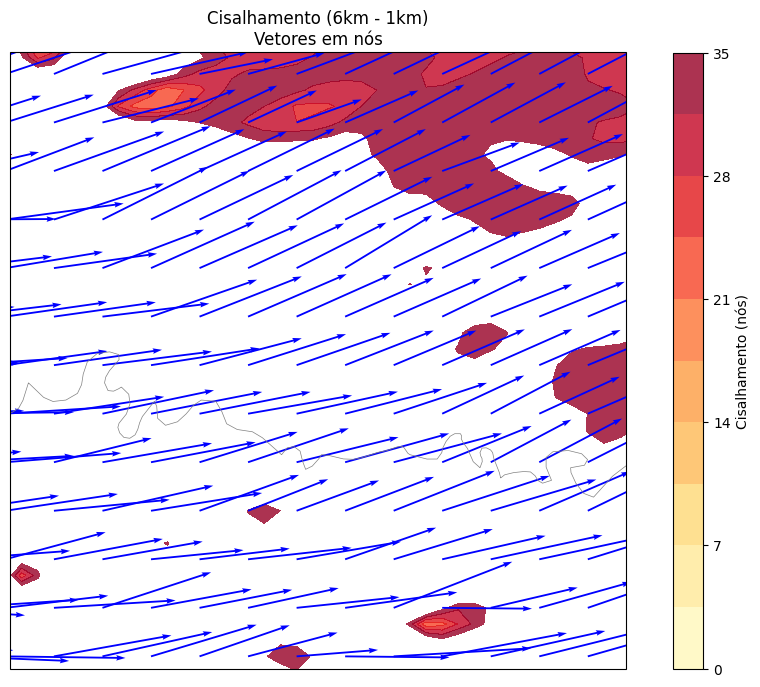

In [5]:
# Cisalhamento
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/'

site_lon = -52.6791  # longitude in degrees
site_lat = -27.0972  # latitude in degrees

vmin_global = 0 
vmax_global = 35  

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        xrds = xr.open_dataset(caminho_arquivo)

        # Converter de m/s para nós
        ms_to_knots = 1.94384
        u_700 = xrds['uzonal_6km'] * ms_to_knots
        v_700 = xrds['umeridional_6km'] * ms_to_knots
        u_925 = xrds['uzonal_1km'] * ms_to_knots
        v_925 = xrds['umeridional_1km'] * ms_to_knots

        shear_u = u_700 - u_925
        shear_v = v_700 - v_925
        shear_magnitude = np.sqrt(shear_u**2 + shear_v**2)

        lat = xrds['latitude']
        lon = xrds['longitude']

        plt.figure(figsize=(12, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())

        shear_plot = ax.contourf(lon, lat, shear_magnitude[0, :, :],
                                 transform=ccrs.PlateCarree(),
                                 cmap='YlOrRd', alpha=0.8,
                                 levels=np.linspace(vmin_global, vmax_global, 11))
        plt.colorbar(shear_plot, label='Cisalhamento (nós)')

        # Adicionar vetores de cisalhamento em nós
        ax.quiver(lon[::3], lat[::3], shear_u[0, ::3, ::3], shear_v[0, ::3, ::3],
                  transform=ccrs.PlateCarree(), scale=250, color='blue', width=0.003)

        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

        estados = cfeature.NaturalEarthFeature(category='cultural',
                                               name='admin_1_states_provinces_lines',
                                               scale='10m', facecolor='none')
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

        ax.set_extent([site_lon - 0.5, site_lon + 0.5, site_lat - 0.5, site_lat + 0.5], crs=ccrs.PlateCarree())

        plt.title('Cisalhamento (6km - 1km)\nVetores em nós')

        output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/WindShear_zoom/'
        os.makedirs(output_path, exist_ok=True)
        output_filename = os.path.join(output_path, f"WindShear_{arquivo.split('.')[0]}.png")
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        xrds.close()


In [44]:
#Geopot
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Caminho para a pasta que contém os arquivos .nc
pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/'

# Caminho para a pasta onde os gráficos serão salvos
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/Height_500hPa/'
os.makedirs(output_path, exist_ok=True)

site_lon, site_lat = -52.6791, -27.0972
g = 9.80665  # Aceleração da gravidade (m/s^2)

vmin_global = 5000
vmax_global = 6000

# Determinar os limites globais
# for arquivo in os.listdir(pasta):
#     if arquivo.endswith('.nc'):
#         caminho_arquivo = os.path.join(pasta, arquivo)

#         xrds = xr.open_dataset(caminho_arquivo)

#         # Converter a altura geométrica para altura geopotencial
#         height_geopotential = xrds['height_500hPa'] * g

#         vmin_arquivo = float(height_geopotential.min())
#         vmax_arquivo = float(height_geopotential.max())

#         # Atualizar os valores globais
#         vmin_global = min(vmin_global, vmin_arquivo)
#         vmax_global = max(vmax_global, vmax_arquivo)

#         xrds.close()

# Gerar gráficos
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        # Extrair a data e hora do nome do arquivo (formato AAMMDDHH)
        nome_arquivo = os.path.basename(arquivo)
        data_hora = nome_arquivo.split('_')[6]  # A data e hora estão na posição 6
        data_hora = data_hora.split('.')[0]

        xrds = xr.open_dataset(caminho_arquivo)
        height_geopotential = xrds['height_500hPa']

        lat = xrds['latitude']
        lon = xrds['longitude']

        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Fixar escala usando níveis com np.linspace
        height_plot = ax.contourf(lon, lat, height_geopotential[0, :, :], transform=ccrs.PlateCarree(),
                                  cmap='pyart_SCook18', alpha=0.8, levels=np.arange(vmin_global, vmax_global, 20))
        plt.colorbar(height_plot)

        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

        estados = cfeature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none')
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

        ax.set_extent([-60, -42, -38, -22], crs=ccrs.PlateCarree())

         # Adicionar rótulos de latitude e longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}
        ax.plot(site_lon, site_lat, marker='*', markersize=8,
               color='white', markeredgecolor='black', transform=ccrs.PlateCarree())
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        # Definir o nome do arquivo de saída usando o nome do arquivo .nc
        output_filename = os.path.join(output_path, f'Height_500hPa_{os.path.splitext(arquivo)[0]}.png')

        plt.savefig(output_filename, dpi=300, bbox_inches='tight')

        xrds.close()
        plt.close()


In [31]:
#Geopot e Vento(nós)
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# Caminho para a pasta que contém os arquivos .nc
pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/Full'

# Caminho para a pasta onde os gráficos serão salvos
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/Geopotential_WindBarbs/'
os.makedirs(output_path, exist_ok=True)

g = 9.80665  # Aceleração da gravidade (m/s^2)

# Processar cada arquivo .nc na pasta
for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        # Extrair a data e hora do nome do arquivo (formato AAMMDDHH)
        nome_arquivo = os.path.basename(arquivo)
        raw_data_hora = nome_arquivo.split('_')[6].split('.')[0] 
        ano = raw_data_hora[:4]
        mes = raw_data_hora[4:6] 
        dia = raw_data_hora[6:8]  
        hora = raw_data_hora[8:10]  

        data_hora = f'{hora}:00 UTC {dia}/{mes}/{ano}'

        # Abrir o arquivo NetCDF
        xrds = xr.open_dataset(caminho_arquivo)

        # Selecionar variáveis de geopotencial e vento
        height_geopotential = xrds['height_500hPa'] * g  # Converter para geopotencial
        u_wind = xrds['uzonal_500hPa'] * 1.94384  # Converter vento zonal para nós
        v_wind = xrds['umeridional_500hPa'] * 1.94384  # Converter vento meridional para nós

        # Coordenadas
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values

        # Selecionar um tempo específico
        height_geopotential = height_geopotential[0, :, :]  # Tempo 0
        u_wind = u_wind[0, :, :]
        v_wind = v_wind[0, :, :]

        # Subamostragem para espaçamento das barbatanas
        step = 43  # Ajuste para controlar o espaçamento
        lat_barbs = lat[::step]
        lon_barbs = lon[::step]
        u_wind_barbs = u_wind[::step, ::step]
        v_wind_barbs = v_wind[::step, ::step]

        # Determinar os limites do geopotencial para a escala
        vmin_global = 50000
        vmax_global = 57000

        # Criar o gráfico
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Plotar o geopotencial
        height_plot = ax.contourf(
            lon, lat, height_geopotential, transform=ccrs.PlateCarree(),
            cmap='pyart_Theodore16', alpha=0.8, levels=np.arange(vmin_global, vmax_global, 75)
        )
        plt.colorbar(height_plot, label='Altura Geopotencial (m²/s²)')

        # Adicionar barbatanas de vento
        ax.barbs(lon_barbs, lat_barbs, u_wind_barbs, v_wind_barbs, transform=ccrs.PlateCarree(), length=6, color='black')
        
        ax.plot(-52.6152, -27.1000, marker='*', markersize=7, color='white', 
        markeredgecolor='black', markeredgewidth=1.5, transform=ccrs.PlateCarree())
       
        # Adicionar elementos do mapa
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        estados = cfeature.NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines', scale='10m', facecolor='none'
        )
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

        # Configurar o zoom
        ax.set_extent([-63, -40, -40, -23], crs=ccrs.PlateCarree())

        # Adicionar rótulos de latitude e longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}

        # Adicionar título
        #plt.suptitle(f'{data_hora}', fontsize=18, ha='left',x=0.13,y=0.90,fontweight='bold')
        #plt.title(f'Altura Geopotencial\nBarbelas de Vento(nós) - 500 hPa', ha='left', fontsize=12,x=0)
    

        # Salvar o gráfico
        output_filename = os.path.join(output_path, f'Geopotential_WindBarbs_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        # Fechar o dataset
        xrds.close()


In [7]:
#Geopot ERA5
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.feature as cfeature
import pandas as pd
import pyart

# Configurações
pasta = '/home/jovyan/privado/Dados/ERA5/'
output_path = '/home/jovyan/privado/Saidas/ERA5/geopot'
os.makedirs(output_path, exist_ok=True)

# Parâmetros
g = 9.80665 
pressao_alvo = 500.0 
site_lon, site_lat = -52.6791, -27.0972  # Coordenadas de referência

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.grib') or arquivo.endswith('.nc'):
        print(f"Processando: {arquivo}")
        caminho_completo = os.path.join(pasta, arquivo)
        
        try:
            ds = xr.open_dataset(caminho_completo, engine='cfgrib')
            ds_nivel = ds

            # 3. Cálculo da Altura Geopotencial em metros
            altura_geopotencial = ds_nivel['z'] / g
            
            # 4. Tratamento de coordenadas
            lat_name = 'latitude' if 'latitude' in altura_geopotencial.coords else 'lat'
            lon_name = 'longitude' if 'longitude' in altura_geopotencial.coords else 'lon'

            # 5. Iteração sobre os tempos
            for tempo in altura_geopotencial['time']:
                data_hora = pd.to_datetime(tempo.values).strftime('%Y%m%d_%H%M')
                
                fig = plt.figure(figsize=(12, 8))
                ax = plt.axes(projection=ccrs.PlateCarree())
                
                # Recorte de tempo específico
                dado_plot = altura_geopotencial.sel(time=tempo)
                
                # --- CAMADA 1: Preenchimento de Cor (zorder=1) ---
                contorno = ax.contourf(
                    dado_plot[lon_name],
                    dado_plot[lat_name],
                    dado_plot,
                    transform=ccrs.PlateCarree(),
                    cmap='SCook18', # Certifique-se de que este cmap está registrado ou use pyart.graph.cm.SCook18
                    levels=np.arange(5000, 6000, 20),
                    extend='both',
                    zorder=1
                )
                
                # --- CAMADA 2: Linhas de Geopotencial (zorder=2) ---
                linhas = ax.contour(
                    dado_plot[lon_name],
                    dado_plot[lat_name],
                    dado_plot,
                    transform=ccrs.PlateCarree(),
                    colors='black',
                    linewidths=0.6,
                    levels=np.arange(4900, 6000, 20),
                    alpha = 0.8,
                    zorder=2
                )
                
                ax.clabel(linhas, inline=True, fontsize=7, fmt='%1.0f', colors='black')
                plt.colorbar(contorno, label='Altura Geopotencial (m)', shrink=0.8, pad=0.05)
                
                # --- CAMADA 3: GEOGRAFIA GARANTIDA NO TOPO (zorder=4 e 5) ---
                # Litoral
                ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1.2, edgecolor='black', zorder=4)

                # Países 
                countries = cfeature.NaturalEarthFeature(
                    category='cultural', name='admin_0_countries',
                    scale='50m', facecolor='none', edgecolor='black', linewidth=1.2
                )
                ax.add_feature(countries, zorder=4)

                # Estados
                states_lines = cfeature.NaturalEarthFeature(
                    category='cultural', name='admin_1_states_provinces_lines',
                    scale='50m', facecolor='none', edgecolor='black', linewidth=1.0
                )
                ax.add_feature(states_lines, zorder=5)
                
                # --- ACABAMENTOS ---
                # Grade
                gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.7, zorder=3)
                gl.top_labels = False
                gl.right_labels = False
                gl.xlabel_style = {"size": 10, "color": "black"}
                gl.ylabel_style = {"size": 10, "color": "black"}
                
                # Local de referência (Estrela)
                ax.plot(site_lon, site_lat, marker='*', markersize=12, color='white',
                        markeredgecolor='black', transform=ccrs.PlateCarree(), zorder=6) # Zorder máximo
                
                # Limites e Título
                ax.set_title(f'ERA5 - Altura Geopotencial @ 500 hPa\n{data_hora}', fontsize=14, loc='left')
                ax.set_extent([-80, -20, -50, -10], crs=ccrs.PlateCarree())
                
                # Salvar e fechar
                output_file = os.path.join(output_path, f'ERA5_500hPa_{data_hora}.png')
                plt.savefig(output_file, dpi=300, bbox_inches='tight')
                plt.close()
            
            ds.close()
            
        except Exception as e:
            print(f"Erro ao processar {arquivo}: {e}")

Processando: 2d0833e05eec5325d9f22906e4899234.grib


In [ ]:
# Refletividade CAPPI 
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart
import cartopy.io.shapereader as shpreader

# Caminho para os arquivos de entrada e saída
pasta = 'C:/Users/Paulo/Documents/INPE/Radar 202308/08/'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811-Radar/RefletividadeCorteTCCFull/'
os.makedirs(output_path, exist_ok=True)
path_municipios = 'SC_Municipios_2023.shp'

# Configurações globais do plot
vmin_global = 1
vmax_global = 75

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        # Extrair data e hora do nome do arquivo (mantido para o nome do arquivo de saída)
        nome_arquivo = os.path.basename(arquivo)
        raw_data_hora = nome_arquivo.split('_')[1].split('.')[0]
        
        # Abrir o arquivo
        ds = xr.open_dataset(caminho_arquivo)
        dbz = ds['dbz']
        lat = ds['lat']
        lon = ds['lon']
        sfc = ds['sfc']  # níveis verticais (altitude)

        # Selecionar o nível mais próximo de 1000 metros
        altura_alvo = 1500  # metros
        idx_altura = np.argmin(np.abs(sfc.values - altura_alvo))
        dbz2d = dbz.isel(time=0, sfc=idx_altura)

        # Plot
        plt.figure(figsize=(14, 12))
        ax = plt.axes(projection=ccrs.PlateCarree())

        levels = np.arange(vmin_global, vmax_global + 1, 1)
        cf = ax.contourf(lon, lat, dbz2d,
                         transform=ccrs.PlateCarree(),
                         cmap='pyart_NWSRef',
                         levels=levels,
                         alpha=0.8)
        cbar = plt.colorbar(cf, label='Refletividade (dBZ)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        estados = cfeature.NaturalEarthFeature(category='cultural',
                                               name='admin_1_states_provinces_lines',
                                               scale='10m', facecolor='none')
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

        #Adicionar os limites dos municípios de SC ---
        municipios_sc = list(shpreader.Reader(path_municipios).geometries())
        ax.add_geometries(municipios_sc, ccrs.PlateCarree(),
                          edgecolor='black', facecolor='none', linewidth=0.5)


        # Ajustar o zoom conforme a posição do radar
        ax.set_extent([-52.60374-1, -52.60374+1, -27.04879-1, -27.04879+1], crs=ccrs.PlateCarree())

        # Marcar o radar
        ax.plot(-52.60374, -27.04879, marker='*', markersize=7, color='black',
                markeredgecolor='black', markeredgewidth=1.5, transform=ccrs.PlateCarree())

        # Grade de latitude/longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}

         plt.suptitle(f'{data_hora}', fontsize=18, ha='left', x=0.13, y=0.88, fontweight='bold')
        
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        # Nome do arquivo de saída
        output_filename = os.path.join(output_path, f'Refletividade_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        ds.close()


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



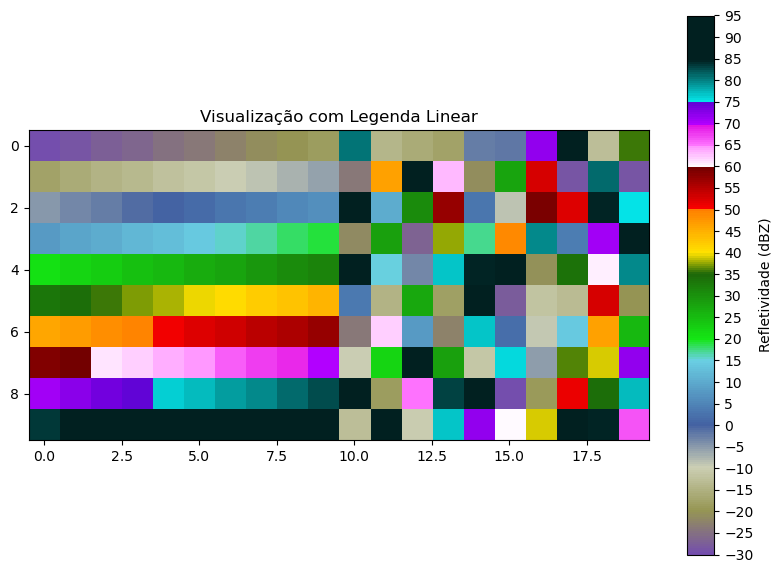

In [32]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

# 1. Seus dados de exemplo com o ajuste mais recente
colors_rgb = [
    [116, 78, 173],   # -30
    [150, 150, 83],   # -20
    [204, 207, 180],  # -10
    [67, 97, 162],    # 0
    [106, 208, 228],  # 15
    [20, 230, 20],    # 20
    [29, 104, 9],     # 35
    [255, 225, 0],    # 40
    [255, 128, 0],    # 49.9
    [255, 0, 0],      # 50
    [113, 0, 0],      # 59.9
    [255, 255, 255],  # 60
    [255, 146, 255],  # 64.9
    [255, 117, 255],  # 65
    [225, 11, 227],   # 69.9
    [178, 0, 255],    # 70
    [99, 0, 214],     # 74.9
    [5, 236, 240],    # 75
    [1, 32, 32],      # 84.9
    [1, 32, 32],      # 85
    [1, 32, 32],      # 95
]

dbz_levels = [-30, -20, -10, 0, 15, 20, 35, 40, 49.9, 50, 59.9, 60, 64.9, 65, 69.9, 70, 74.9, 75, 84.9, 85, 95]


# 2. Normalizar os valores RGB para a escala 0-1
normalized_colors = np.array(colors_rgb) / 255.0

# 3. Normalizar os níveis de dBZ para a escala 0-1
vmin = dbz_levels[0]
vmax = dbz_levels[-1]
norm_levels = (np.array(dbz_levels) - vmin) / (vmax - vmin)

# 4. Criar a lista de tuplas (posição_normalizada, cor)
color_pos_list = list(zip(norm_levels, normalized_colors))

# 5. Criar o colormap segmentado a partir de todos os pontos
final_cmap = LinearSegmentedColormap.from_list('custom_cmap_final_v2', color_pos_list)

# Gerar dados de exemplo para visualização
data = np.zeros((10, 20))
data[0:10,0:10] = np.linspace(vmin, vmax, 100).reshape(10,10)
data[0:10,10:20] = np.random.uniform(vmin, vmax, (10, 10))


# Plotar os dados
fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(data, cmap=final_cmap, vmin=vmin, vmax=vmax)
ax.set_title('Visualização com Legenda Linear')

# --- MODIFICAÇÃO AQUI ---
# Adicionar a barra de cores com ticks lineares de 10 em 10

# 1. Criar a lista de ticks desejados
linear_ticks = np.arange(-30, 100, 5)

# 2. Usar a nova lista de ticks na barra de cores
cbar = fig.colorbar(im, ax=ax, ticks=linear_ticks)
cbar.set_label('Refletividade (dBZ)')

plt.savefig("colormap_legenda_linear.png")

In [34]:
# Refletividade PPI
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart
import geopandas as gpd
import warnings

# Suprime avisos (Padrão Code 2)
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

# --- CONFIGURAÇÕES GERAIS ---
# Ajuste os caminhos conforme sua máquina
PASTA_ENTRADA = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
PASTA_SAIDA = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810/Refletividade'
SHP_PATH = '/home/jovyan/privado/SC_Municipios_2023.shp'  # Caminho para o shapefile

# Coordenadas do Radar (Mantidas do Code 1)
RADAR_LAT = -27.04879
RADAR_LON = -52.60374

# Cria diretório de saída se não existir
os.makedirs(PASTA_SAIDA, exist_ok=True)
cmap_plot = final_cmap
# Carregamento do Shapefile (Padrão Code 2 - usando Geopandas)
try:
    gdf_sc = gpd.read_file(SHP_PATH)
except Exception as e:
    print(f"Aviso: Não foi possível carregar o shapefile em {SHP_PATH}. Erro: {e}")
    gdf_sc = None

# Limites Globais de Refletividade
vmin_global = -30
vmax_global = 95

print(f"Iniciando processamento na pasta: {PASTA_ENTRADA}")

for arquivo in os.listdir(PASTA_ENTRADA):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(PASTA_ENTRADA, arquivo)
        
        # Processamento do nome e data
        nome_arquivo = os.path.basename(arquivo)
        try:
            # Tenta extrair data do padrão de nome do arquivo
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"

        print(f"Plotando: {nome_arquivo}")

        # Leitura dos dados (Code 1 - Xarray)
        xrds = xr.open_dataset(caminho_arquivo)
        refl = xrds['refl10cm_1km']
        lat = xrds['latitude']
        lon = xrds['longitude']

        # --- CORREÇÃO: MASCARAR DADOS BAIXOS ---
        # Seleciona o tempo 0 (2D)
        data_2d = refl[0, :, :]
        
        # Cria uma máscara: Oculta tudo que for menor que 0 dBZ (ou -10, ajuste se quiser ver ruído)
        # Valores mascarados ficam transparentes no plot
        data_masked = np.ma.masked_less(data_2d, 0) 

        # --- PLOTAGEM ---
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Note que agora passamos 'data_masked' ao invés de 'refl[0,:,:]'
        mesh = ax.pcolormesh(lon, lat, data_masked, 
                             transform=ccrs.PlateCarree(),
                             cmap=cmap_plot, 
                             vmin=vmin_global, 
                             vmax=vmax_global,
                             shading='nearest')

        # --- GEOGRAFIAS E ESTILO (Padrão Code 2) ---
        
        # Estados
        states = cfeature.NaturalEarthFeature(
            category='cultural', name='admin_1_states_provinces_lines',
            scale='10m', facecolor='none'
        )
        ax.add_feature(states, edgecolor='gray', linewidth=0.8, alpha=0.5) # Estilo Code 2
        
        # Fronteiras e Costa
        ax.add_feature(cfeature.BORDERS, linewidth=0.8)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

        # Municípios (Geopandas - Padrão Code 2)
        if gdf_sc is not None:
            gdf_sc.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

        # --- PONTO DO RADAR
        # Troca da estrela branca (Code 1) pelo ponto preto com borda (Code 2)
        ax.scatter(RADAR_LON, RADAR_LAT, color='black', s=15, marker='o', 
                   edgecolor='white', linewidth=1.5, zorder=10, 
                   transform=ccrs.PlateCarree())

        # --- CONFIGURAÇÃO DE ZOOM (Padrão Code 2) ---
        # Usa offset de 0.6 graus
        ax.set_extent([RADAR_LON - 1, RADAR_LON + 1, 
                       RADAR_LAT - 1, RADAR_LAT + 1], crs=ccrs.PlateCarree())

        # --- COLORBAR (Padrão Code 2) ---
        # Vertical, shrink 0.8, ticks de 10 em 10 começando de -30
        cb = plt.colorbar(mesh, ax=ax, orientation='vertical', shrink=0.8, pad=0.02)
        cb.set_label("Reflectivity (dBZ)")
        cb.set_ticks(np.arange(-30, 95, 10))
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.9)
        gl.top_labels = False
        gl.right_labels = False
        # Título
        plt.title(f"Reflectivity (dBZ)\nArquivo: {nome_arquivo}\nData: {data_hora}", fontsize=10)

        # Salvar arquivo
        output_filename = os.path.join(PASTA_SAIDA, f'Refletividade_{os.path.splitext(arquivo)[0]}.png')
        
        # DPI ajustado para 300 (Padrão Code 2, Code 1 usava 500)
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        xrds.close()

print("\nProcessamento concluído!")

Iniciando processamento na pasta: /home/jovyan/privado/MONAN/granizo2308/2023081000/
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081022.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081006.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081016.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081012.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081002.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081117.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081203.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081213.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081123.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081107.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081103.00.00.x1.65536002L55.nc
Plotando: MONAN_DIAG_R_POS_GFS_2023081000_2023081217.00.00.x1.655360


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



KeyboardInterrupt: 

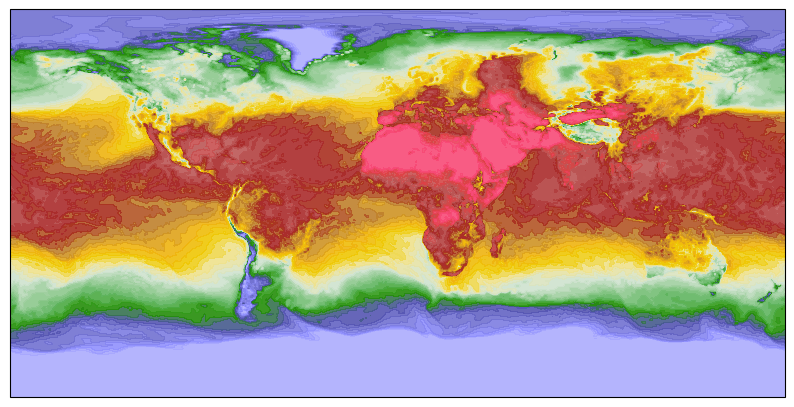

In [1]:
# Temperatura ERA5
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart

# Caminho do arquivo ERA5
arquivo_era5 = r'C:/Users/Paulo/Documents/Python Scripts/ERA5/varias.nc'

# Verificar se o arquivo existe
if not os.path.isfile(arquivo_era5):
    raise FileNotFoundError(f"Arquivo não encontrado: {arquivo_era5}")

# Pasta onde os gráficos serão salvos
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5_T2M/'
os.makedirs(output_path, exist_ok=True)

# Escala de temperatura (°C)
vmin_global = -5
vmax_global = 35

# Abrir o dataset ERA5
xrds = xr.open_dataset(arquivo_era5)

# Coordenadas e variáveis
lat = xrds['latitude']
lon = xrds['longitude']
valid_times = xrds['valid_time']

# Loop sobre cada valid_time disponível no dataset
for idx, vtime in enumerate(valid_times):
    # A dimensão se chama 'time', mesmo que a coordenada válida seja 'valid_time'
    t2m = xrds['t2m'].isel(valid_time=idx) - 273.15  # Converte para Celsius

    # Garante um nome de arquivo seguro (sem caracteres inválidos)
    data_hora = np.datetime_as_string(vtime.values, unit='h').replace(':', '')

    plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    cmap = 'pyart_Theodore16'
    levels = np.arange(vmin_global, vmax_global + 1, 1)

    temp_plot = ax.contourf(
        lon, lat, t2m,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=levels,
        extend='both',
        alpha=0.9
    )

    cbar = plt.colorbar(temp_plot, label='Temperatura a 2m (°C)')
    cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

    ax.coastlines(resolution='10m', color='black', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

    estados = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='10m',
        facecolor='none'
    )
    ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

    ax.set_extent([-63, -40, -40, -20], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10, "color": "black"}
    gl.ylabel_style = {"size": 10, "color": "black"}

    #plt.title(f'Temperatura a 2m - {data_hora}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    output_filename = os.path.join(output_path, f'T2M_{data_hora}.png')
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.close()

xrds.close()


KeyboardInterrupt: 

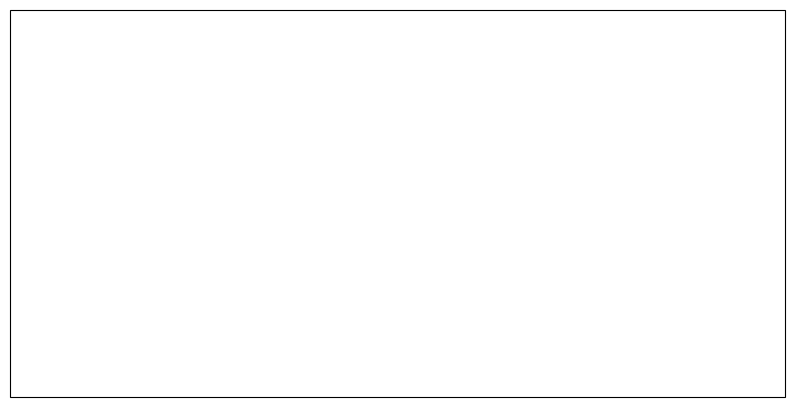

In [4]:
#Temperatura
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart

# Caminho para a pasta que contém os arquivos .nc
pasta = '/home/jovyan/arquivos/MONAN/2025011500/'

# Caminho para a pasta onde os gráficos serão salvos
output_path = '/home/jovyan/arquivos/MONAN/2025011500/T2M2/'
os.makedirs(output_path, exist_ok=True)

# Valores para escala de temperatura (°C)
vmin_global = -5
vmax_global = 35

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        # Extrair a data e hora do nome do arquivo (formato AAMMDDHH)
        nome_arquivo = os.path.basename(arquivo)
        data_hora = nome_arquivo.split('_')[6].split('.')[0]

        xrds = xr.open_dataset(caminho_arquivo)
        t2m = xrds['t2m'][0, :, :] - 273.15  # Converter de Kelvin para Celsius

        lat = xrds['latitude']
        lon = xrds['longitude']

        plt.figure(figsize=(10, 6))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Paleta de cores apropriada para temperatura
        cmap = 'Theodore16'
        levels = np.arange(vmin_global, vmax_global + 1, 1)

        temp_plot = ax.contourf(
            lon, lat, t2m,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            levels=levels,
            extend='both',
            alpha=0.9
        )

        cbar = plt.colorbar(temp_plot, label='Temperatura a 2m (°C)')
        cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='gray', linewidth=0.5)

        ax.set_extent([-63, -40, -40, -20], crs=ccrs.PlateCarree())

        # Adicionar rótulos de latitude e longitude
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray")
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 10, "color": "black"}
        gl.ylabel_style = {"size": 10, "color": "black"}

        #plt.title(f'Temperatura a 2m - {data_hora}')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')

        output_filename = os.path.join(output_path, f'T2M_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()

        xrds.close()


In [5]:
# CAPE, Cisalhamento e CIN com Shapefiles e Zoom
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

# Caminhos
pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081100/'
output_path = '/home/jovyan/privado/MONAN/granizo202308/Saidas202308/MUCAPE_shear0_6' 
os.makedirs(output_path, exist_ok=True)

# Shapefile municípios
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8
)

delta = 4  # zoom
site_lon, site_lat = -52.6791, -27.0972

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
        # Extração de data/hora
        nome_arquivo = os.path.basename(arquivo)
        try:
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"

        
        xrds = xr.open_dataset(caminho_arquivo)
        
       
        u_925 = xrds['u10'][0] * 1.94384  # Conversão m/s -> nós
        v_925 = xrds['v10'][0] * 1.94384
        u_700 = xrds['uzonal_6km'][0] * 1.94384
        v_700 = xrds['umeridional_6km'][0] * 1.94384
        
        #cisalhamento = vento superior - vento inferior
        u_shear = u_700 - u_925  # 
        v_shear = v_700 - v_925  # 
        
        
        cape = xrds['mucape'][0]
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values

        # Plotagem
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        cape_plot = ax.contourf(
            lon, lat, cape, transform=ccrs.PlateCarree(),
            cmap='pd17_c', levels=np.arange(100, 4200, 100),
            extend='max'
        )
    
        ticks_cape = np.arange(0, 3501, 500)
        plt.colorbar(cape_plot, label='MUCAPE (J/kg)', ticks=ticks_cape)
        plt.colorbar
        
        
        # Barbelas 
        
        step = 28#espaçamento 28 para delta 4
        ax.barbs(lon[::step], lat[::step], 
                 u_shear[::step,::step], v_shear[::step,::step],
                 transform=ccrs.PlateCarree(), length=6, color='black')

        # Elementos do mapa
        # ax.add_feature(municipios_feature)  # Shapefile
        ax.set_extent([site_lon - delta, site_lon + delta,  # Zoom igual anterior
                      site_lat - delta, site_lat + delta],
                      crs=ccrs.PlateCarree())
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)
        # Marcador e grades
        ax.plot(site_lon, site_lat, marker='*', markersize=15,
               color='white', markeredgecolor='black', transform=ccrs.PlateCarree())
        
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray",alpha=1)
        gl.top_labels = gl.right_labels = False
        
        plt.title(f"Variável: MUCAPE (J/kg)\nCisalhamento 0-6km \nArquivo: {nome_arquivo}\nData: {data_hora}", fontsize=12, loc='center')
        # ---------------------------------------

        output_filename = os.path.join(output_path, f'CAPE_Shear_Zoom_{raw_data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        xrds.close()

In [8]:
#CAPE Multhreading
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

def processar_arquivo(arquivo, pasta, output_path, site_lon, site_lat, delta):
    """
    Função isolada para processar e plotar um único arquivo.
    Executada em paralelo por múltiplos processos.
    """
    caminho_arquivo = os.path.join(pasta, arquivo)
    nome_arquivo = os.path.basename(arquivo)
    
    # Extração de data/hora
    try:
        raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
        data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
    except IndexError:
        data_hora = "Data Desconhecida"
        raw_data_hora = "desconhecida"

    # Processamento de Dados
    try:
        with xr.open_dataset(caminho_arquivo) as xrds:
            u_925 = xrds['u10'][0] * 1.94384  # Conversão m/s -> nós
            v_925 = xrds['v10'][0] * 1.94384
            u_700 = xrds['uzonal_6km'][0] * 1.94384
            v_700 = xrds['umeridional_6km'][0] * 1.94384
            
            # Cisalhamento = vento superior - vento inferior
            u_shear = u_700 - u_925  
            v_shear = v_700 - v_925  
            
            cape = xrds['mucape'][0]
            lat = xrds['latitude'].values
            lon = xrds['longitude'].values

            # Plotagem
            # Utiliza uma nova figura isolada para não conflitar na memória
            fig = plt.figure(figsize=(12, 10))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            cape_plot = ax.contourf(
                lon, lat, cape, transform=ccrs.PlateCarree(),
                cmap='pd17_c', levels=np.arange(100, 3500, 100),
                extend='max'
            )
        
            ticks_cape = np.arange(0, 3501, 500)
            plt.colorbar(cape_plot, label='MUCAPE (J/kg)', ticks=ticks_cape)
            
            # Barbelas 
            step = 28 # espaçamento 28 para delta 4
            ax.barbs(lon[::step], lat[::step], 
                     u_shear[::step,::step], v_shear[::step,::step],
                     transform=ccrs.PlateCarree(), length=6, color='black')

            # Elementos do mapa
            ax.set_extent([site_lon - delta, site_lon + delta, 
                           site_lat - delta, site_lat + delta],
                          crs=ccrs.PlateCarree())
            ax.coastlines(resolution='10m', color='black', linewidth=1)
            ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

            estados = cfeature.NaturalEarthFeature(
                category='cultural',
                name='admin_1_states_provinces_lines',
                scale='10m',
                facecolor='none'
            )
            ax.add_feature(estados, edgecolor='black', linewidth=1)
            
            # Marcador e grades
            ax.plot(site_lon, site_lat, marker='*', markersize=15,
                    color='white', markeredgecolor='black', transform=ccrs.PlateCarree())
            
            gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=1)
            gl.top_labels = gl.right_labels = False
            
            plt.title(f"Variável: MUCAPE (J/kg)\nCisalhamento 0-6km \nArquivo: {nome_arquivo}\nData: {data_hora}", fontsize=12, loc='center')
            
            # Salvamento
            output_filename = os.path.join(output_path, f'CAPE_Shear_Zoom_{raw_data_hora}.png')
            plt.savefig(output_filename, dpi=300, bbox_inches='tight')
            
    except Exception as e:
        print(f"Erro ao processar {nome_arquivo}: {e}")
    finally:
        # Crucial para evitar vazamento de memória RAM nos processos filhos
        plt.close('all')

if __name__ == '__main__':
    # Configurações Iniciais
    pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
    output_path = '/home/jovyan/privado/MONAN/granizo2308/Saidas20230810/MUCAPE_shear0_6' 
    os.makedirs(output_path, exist_ok=True)

    delta = 4  # zoom
    site_lon, site_lat = -52.6791, -27.0972
    
    # Coleta apenas os arquivos .nc
    arquivos_nc = [f for f in os.listdir(pasta) if f.endswith('.nc')]
    
    # Define o número de processos.
    if multiprocessing.cpu_count() < len(arquivos_nc):
        num_workers = 50
    else:
        num_workers = len(arquivos_nc)
    
    print(f"Iniciando o processamento de {len(arquivos_nc)} arquivos usando {num_workers} processos...")

    # Execução Paralela
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        futures = []
        for arquivo in arquivos_nc:
            future = executor.submit(
                processar_arquivo, 
                arquivo, pasta, output_path, site_lon, site_lat, delta
            )
            futures.append(future)
        
        # Opcional: Monitorar o término das tarefas
        for future in futures:
            future.result() # Aguarda a conclusão e levanta erros, se houverem
            
    print("Processamento concluído.")

Iniciando o processamento de 73 arquivos usando 73 processos...


/opt/conda/lib/python3.13/site-packages/matplotlib/quiver.py:1021: RuntimeWarning: invalid value encountered in cast
  return n_flags.astype(int), n_barb.astype(int), half_flag, empty_flag


Processamento concluído.


In [36]:
#ERA5 CAPE
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import pandas as pd

# Configurações
pasta = 'C:/Users/Paulo/Documents/Python Scripts/2023081100/ERA5/'
output_path = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/'
os.makedirs(output_path, exist_ok=True)

# Shapefile
shp_path = 'SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8
)

# Zoom
delta = 1
site_lon, site_lat = -52.6791, -27.0972

for arquivo in os.listdir(pasta):
    if arquivo == 'ERA52.nc':
        caminho_arquivo = os.path.join(pasta, arquivo)
        ds = xr.open_dataset(caminho_arquivo)
        
        # Loop sobre todos os tempos válidos (valid_time)
        for time_idx in range(len(ds['valid_time'])):
            time = ds['valid_time'].values[time_idx]
            data_hora = pd.to_datetime(time).strftime('%H:%M UTC %d/%m/%Y')
            
            # Dados CAPE para o tempo atual
            cape = ds['cape'][time_idx, :, :].values  # Acessa o índice do tempo
            lat = ds['latitude'].values
            lon = ds['longitude'].values
            
            # Plotagem
            plt.figure(figsize=(12, 10))
            ax = plt.axes(projection=ccrs.PlateCarree())
            
            # Configuração do CAPE
            levels = np.arange(100, 4200, 100)
            cmap = plt.get_cmap('pyart_LangRainbow12')
            plot = ax.contourf(
                lon, lat, cape,
                transform=ccrs.PlateCarree(),
                cmap=cmap,
                levels=levels,
                extend='both'
            )
            plt.colorbar(plot, label='CAPE (J/kg)')
            
            # Elementos do mapa
            ax.add_feature(municipios_feature)
            ax.set_extent([site_lon - delta, site_lon + delta, site_lat - delta, site_lat + delta])
            
            # Grades
            gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.7)
            gl.top_labels = gl.right_labels = False
            ax.plot(site_lon, site_lat, marker='*', markersize=15,
               color='white', markeredgecolor='black', transform=ccrs.PlateCarree())
            # Título e salvamento
            plt.title(f'CAPE - {data_hora}', fontsize=14)
            data_hora_safe = pd.to_datetime(time).strftime('%Y%m%d_%H%M')
            output_filename = os.path.join(output_path, f'ERA5_CAPE_{data_hora_safe}.png')
            print(f"Salvando: {output_filename}")
            plt.savefig(output_filename, dpi=300, bbox_inches='tight')
            plt.close()
        
        ds.close()

Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0000.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0100.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0200.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0300.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0400.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0500.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0600.png
Salvando: C:/Users/Paulo/Documents/INPE/Caso 20230811/ERA5 CAPE/ERA5_CAPE_20230812_0700.png


In [15]:
#Corte Refletividade
import os
from PIL import Image

# --- 1. CONFIGURAÇÃO DOS CAMINHOS ---
# ATENÇÃO: Verifique se estes caminhos estão corretos!

# Pasta com as imagens do modelo (MONAN)
# Ex: Refletividade_MONAN_..._2023081200.mm...png
path_model = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/RefletividadeCorte/'

# Pasta com as imagens do radar
# Ex: Refletividade_R13132245_202308120006.png
path_radar = 'C:/Users/Paulo/Documents/INPE/Caso 20230811-Radar/RefletividadeCorte/'

# Pasta onde as imagens combinadas serão salvas
path_saida = 'C:/Users/Paulo/Documents/INPE/Caso 20230811/Imagens_Comparativas/'

# -------------------------------------------

# Cria a pasta de saída se ela não existir
os.makedirs(path_saida, exist_ok=True)

def get_key_from_model_filename(filename):
    """Extrai a chave YYYYMMDDHH do nome do arquivo do modelo."""
    # Pega o segundo timestamp no nome do arquivo: ..._2023081100_2023081200...
    try:
        return filename.split('_')[7].split('.')[0][:10]
    except IndexError:
        return None

def get_key_from_radar_filename(filename):
    """Extrai a chave YYYYMMDDHH do nome do arquivo do radar."""
    # Pega o timestamp e trunca para os primeiros 10 dígitos: ..._202308120006.png
    try:
        return filename.split('_')[2][:10]
    except IndexError:
        return None

# Mapeia as chaves (YYYYMMDDHH) para os nomes de arquivo do radar para busca rápida
radar_map = {get_key_from_radar_filename(f): f for f in os.listdir(path_radar) if f.endswith('.png')}

# Itera sobre os arquivos do modelo para encontrar os pares no mapa do radar
model_files = [f for f in os.listdir(path_model) if f.endswith('.png')]

for model_file in model_files:
    model_key = get_key_from_model_filename(model_file)
    
    # Verifica se a chave extraída é válida e se existe no mapa do radar
    if model_key and model_key in radar_map:
        radar_file = radar_map[model_key]
        
        print(f"Combinando par com chave '{model_key}':")
        print(f"  > Modelo: {model_file}")
        print(f"  > Radar:  {radar_file}")

        try:
            # Abre as duas imagens
            img_model = Image.open(os.path.join(path_model, model_file))
            img_radar = Image.open(os.path.join(path_radar, radar_file))

            # Cria uma nova imagem lado a lado
            largura, altura = img_model.size
            imagem_combinada = Image.new('RGB', (largura * 2, altura))
            
            # Cola a imagem do modelo na esquerda e a do radar na direita
            imagem_combinada.paste(img_model, (0, 0))
            imagem_combinada.paste(img_radar, (largura, 0))
            
            # Salva a imagem combinada
            nome_arquivo_saida = os.path.join(path_saida, f"Comparativo_{model_key}.png")
            imagem_combinada.save(nome_arquivo_saida)
            
        except Exception as e:
            print(f"  -> Erro ao processar o par com chave {model_key}: {e}")
            
print("\nProcesso concluído!")

Combinando par com chave '2023081200':
  > Modelo: Refletividade_MONAN_DIAG_R_POS_ERA5_2023081100_2023081200.mm.x20.835586L55.png
  > Radar:  Refletividade_R13132245_202308120054.png
Combinando par com chave '2023081201':
  > Modelo: Refletividade_MONAN_DIAG_R_POS_ERA5_2023081100_2023081201.mm.x20.835586L55.png
  > Radar:  Refletividade_R13132245_202308120154.png
Combinando par com chave '2023081202':
  > Modelo: Refletividade_MONAN_DIAG_R_POS_ERA5_2023081100_2023081202.mm.x20.835586L55.png
  > Radar:  Refletividade_R13132245_202308120254.png
Combinando par com chave '2023081203':
  > Modelo: Refletividade_MONAN_DIAG_R_POS_ERA5_2023081100_2023081203.mm.x20.835586L55.png
  > Radar:  Refletividade_R13132245_202308120354.png
Combinando par com chave '2023081204':
  > Modelo: Refletividade_MONAN_DIAG_R_POS_ERA5_2023081100_2023081204.mm.x20.835586L55.png
  > Radar:  Refletividade_R13132245_202308120454.png
Combinando par com chave '2023081205':
  > Modelo: Refletividade_MONAN_DIAG_R_POS_ERA

In [11]:
#Acumulado 24h
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart

# --- CONFIGURAÇÕES ---
PASTA_INPUT = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
OUTPUT_PATH = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810//Acumulado24' 
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Visual
#SC_ESTADO_EXTENT = [-54.5, -48.0, -29.5, -25.5], LITORAL_SC_EXTENT = [-50.5, -47.5, -30.0, -25.5]
EXTENT = [-54.5, -48.0, -29.5, -25.5]
CMAP_CHUVA = 'Theodore16'
VMIN = 0
VMAX = 100

# --- 1. LISTAR E AGRUPAR ARQUIVOS POR DATA ---
print("Listando arquivos...")
arquivos_nc = sorted([f for f in os.listdir(PASTA_INPUT) if f.endswith('.nc')])

# Dicionário para guardar a lista de arquivos de cada dia
# Ex: {'20250115': ['arq1.nc', 'arq2.nc'], '20250116': [...]}
arquivos_por_dia = {}

for arquivo in arquivos_nc:
    try:
        # Extrai a data do nome (ex: MONAN_..._2025011500...)
        # Ajuste o índice do split se necessário, baseando-se no padrão anterior
        raw_data = arquivo.split('_')[6][:8] # Pega YYYYMMDD
        
        if raw_data not in arquivos_por_dia:
            arquivos_por_dia[raw_data] = []
        arquivos_por_dia[raw_data].append(arquivo)
    except IndexError:
        print(f"Pulado (nome fora do padrão): {arquivo}")
        continue

# --- 2. PROCESSAR CADA DIA ---
print(f"Dias encontrados: {list(arquivos_por_dia.keys())}")

for dia, lista_arquivos in arquivos_por_dia.items():
    print(f"\n--- Calculando acumulado para o dia: {dia} ({len(lista_arquivos)} arquivos) ---")
    
    if len(lista_arquivos) < 2:
        print(f"Aviso: O dia {dia} tem menos de 2 arquivos. Impossível calcular a diferença do período.")
        continue
        
    arquivo_inicial = lista_arquivos[0]  # Primeiro arquivo do dia (ex: 00Z)
    arquivo_final = lista_arquivos[-1]   # Último arquivo do dia (ex: 23Z ou 24Z)
    
    caminho_ini = os.path.join(PASTA_INPUT, arquivo_inicial)
    caminho_fin = os.path.join(PASTA_INPUT, arquivo_final)
    
    try:
        with xr.open_dataset(caminho_ini) as ds_ini, xr.open_dataset(caminho_fin) as ds_fin:
            
            # Verifica integridade das variáveis
            if 'rainnc' not in ds_fin or 'rainc' not in ds_fin:
                print(f"Erro: Variáveis de chuva ausentes no arquivo {arquivo_final}.")
                continue
                
            # Extrai totais iniciais (Convectiva + Não-Convectiva)
            chuva_ini_nc = ds_ini['rainnc'][0, :, :].values
            chuva_ini_c = ds_ini['rainc'][0, :, :].values
            total_ini = chuva_ini_nc + chuva_ini_c
            
            # Extrai totais finais (Convectiva + Não-Convectiva)
            chuva_fin_nc = ds_fin['rainnc'][0, :, :].values
            chuva_fin_c = ds_fin['rainc'][0, :, :].values
            total_fin = chuva_fin_nc + chuva_fin_c
            
            # O acumulado real do dia é a diferença entre o final e o início
            acumulado = total_fin - total_ini
            
            # Previne valores negativos causados por resets ou anomalias do modelo
            acumulado = np.where(acumulado < 0, 0, acumulado)
            
            # Recria um DataArray para facilitar o uso com xarray/plot
            precip_total = xr.DataArray(
                acumulado,
                coords=ds_fin['rainnc'][0,:,:].coords,
                dims=ds_fin['rainnc'][0,:,:].dims
            )

    except Exception as e:
        print(f"Erro crítico ao processar o dia {dia}: {e}")
        continue

    # Padronização de coordenadas
    if 'XLONG' in precip_total.coords:
        precip_total = precip_total.rename({'XLONG': 'longitude', 'XLAT': 'latitude'})
    
    if 'longitude' in precip_total.coords:
        precip_total = precip_total.sortby(['longitude', 'latitude'])

    # --- CÁLCULO DO MÁXIMO (NO ZOOM) ---
    lon_min, lon_max, lat_min, lat_max = EXTENT
    try:
        recorte = precip_total.sel(
            longitude=slice(lon_min, lon_max),
            latitude=slice(lat_min, lat_max)
        )
        max_prec = float(recorte.max()) if recorte.size > 0 else 0.0
    except:
        max_prec = float(precip_total.max())

    # --- PLOTAGEM ---
    try:
        fig = plt.figure(figsize=(10, 9))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

        # Elementos Geográficos
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.2)
        ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', linewidth=1.5, facecolor='none')
        ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff') 

        # Grades
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.6, linewidth=1.2)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 11, "color": "black", "weight": "bold"}
        gl.ylabel_style = {"size": 11, "color": "black", "weight": "bold"}

        # Mapa de Cores
        mapa = ax.pcolormesh(
            precip_total['longitude'], precip_total['latitude'], precip_total.values,
            cmap=CMAP_CHUVA, vmin=VMIN, vmax=VMAX,
            transform=ccrs.PlateCarree(), alpha=0.9
        )

        # Barra de Cores
        cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', shrink=0.56, pad=0.03)
        cbar.set_label('Precipitação Acumulada 24h (mm)', fontsize=12, weight='bold')

        # Texto Máximo
        ax.text(0.98, 0.03, f"Máx Acumulado: {max_prec:.1f} mm", transform=ax.transAxes,
                ha='right', va='bottom', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

        # Título
        ano, mes, dia_str = dia[:4], dia[4:6], dia[6:8]
        ax.set_title(f'Acumulado Diário (24h) - MONAN\nData: {dia_str}/{mes}/{ano}', fontsize=14, loc='left', weight='bold')

        # Salvar
        output_filename = os.path.join(OUTPUT_PATH, f'Acumulado_24h_{dia}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close(fig)
        
        print(f" -> Mapa salvo: {output_filename}")
        
    except Exception as e:
        print(f"Erro ao plotar dia {dia}: {e}")

print("Processamento finalizado.")

Listando arquivos...
Dias encontrados: ['20230810', '20230811', '20230812', '20230813']

--- Calculando acumulado para o dia: 20230810 (24 arquivos) ---
 -> Mapa salvo: /home/jovyan/privado/MONAN/granizo202308/Saidas20230810//Acumulado24/Acumulado_24h_20230810.png

--- Calculando acumulado para o dia: 20230811 (24 arquivos) ---
 -> Mapa salvo: /home/jovyan/privado/MONAN/granizo202308/Saidas20230810//Acumulado24/Acumulado_24h_20230811.png

--- Calculando acumulado para o dia: 20230812 (24 arquivos) ---
 -> Mapa salvo: /home/jovyan/privado/MONAN/granizo202308/Saidas20230810//Acumulado24/Acumulado_24h_20230812.png

--- Calculando acumulado para o dia: 20230813 (1 arquivos) ---
Aviso: O dia 20230813 tem menos de 2 arquivos. Impossível calcular a diferença do período.
Processamento finalizado.


In [ ]:
#Prec Horária
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import pyart # Não está sendo usado explicitamente, pode comentar se quiser

# --- CONFIGURAÇÕES ---
PASTA_INPUT = r'C:\Users\Paulo\Documents\Python Scripts\2023081100\Full'
# Mudei a pasta de saída para não misturar com os acumulados
OUTPUT_PATH = r'C:\Users\Paulo\Documents\INPE\Caso 20230811\PrecHorario' 
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Visual
EXTENT = [-54.5, -48.0, -29.5, -25.5]
CMAP_CHUVA = 'pyart_Theodore16' # Ou 'pyart_Theodore16' se estiver usando via pyart
VMIN = 0
VMAX = 40  # AJUSTE IMPORTANTE: Reduzido de 100 para 50, pois é chuva por hora, não 24h.

# --- 1. LISTAR ARQUIVOS ---
print("Listando arquivos...")
arquivos_nc = sorted([f for f in os.listdir(PASTA_INPUT) if f.endswith('.nc')])

print(f"Total de arquivos encontrados: {len(arquivos_nc)}")

# --- 2. PROCESSAR CADA ARQUIVO INDIVIDUALMENTE ---
for arquivo in arquivos_nc:
    caminho = os.path.join(PASTA_INPUT, arquivo)
    
    # Tenta extrair Data e Hora do nome do arquivo
    # Assumindo padrão ex: MONAN_..._2023081100... (YYYYMMDDHH)
    try:
        part_time = arquivo.split('_')[6] # Ajuste este índice se necessário
        ano = part_time[:4]
        mes = part_time[4:6]
        dia = part_time[6:8]
        hora = part_time[8:10] # Pega a hora (caracteres 8 e 9)
        data_str = f"{dia}/{mes}/{ano} - {hora}Z"
    except Exception as e:
        print(f"Nome fora do padrão ({arquivo}), pulando extração de data: {e}")
        data_str = arquivo
        ano, mes, dia, hora = "0000", "00", "00", "00"

    print(f"Processando: {data_str} -> {arquivo}")

    try:
        ds = xr.open_dataset(caminho)

        if 'prec' not in ds:
            print(f"Variável 'prec' não encontrada em {arquivo}")
            ds.close()
            continue
        
        # Pega a precipitação (tempo, lat, lon) -> Pega o tempo 0
        precip_inst = ds['prec'][0, :, :]

        # --- PREPARAR DADOS (Padronização) ---
        # Renomeia coordenadas se necessário para xarray plot funcionar bem
        if 'XLONG' in precip_inst.coords:
            precip_inst = precip_inst.rename({'XLONG': 'longitude', 'XLAT': 'latitude'})
        
        # Ordena latitudes/longitudes para evitar artefatos no pcolormesh
        if 'longitude' in precip_inst.coords:
            precip_inst = precip_inst.sortby(['longitude', 'latitude'])

        # --- CÁLCULO DO MÁXIMO (NO ZOOM) ---
        lon_min, lon_max, lat_min, lat_max = EXTENT
        try:
            recorte = precip_inst.sel(
                longitude=slice(lon_min, lon_max),
                latitude=slice(lat_min, lat_max)
            )
            max_prec = float(recorte.max()) if recorte.size > 0 else 0.0
        except:
            max_prec = float(precip_inst.max())

        # --- PLOTAGEM ---
        fig = plt.figure(figsize=(10, 9))
        ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
        ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

        # Elementos Geográficos
        ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1.2)
        ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='black', linewidth=1.5, facecolor='none')
        ax.add_feature(cfeature.OCEAN, facecolor='#e6f2ff') 

        # Grades
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.6, linewidth=1.2)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {"size": 11, "color": "black", "weight": "bold"}
        gl.ylabel_style = {"size": 11, "color": "black", "weight": "bold"}

        # Mapa de Cores
        mapa = ax.pcolormesh(
            precip_inst['longitude'], precip_inst['latitude'], precip_inst.values,
            cmap=CMAP_CHUVA, vmin=10, vmax=VMAX,
            transform=ccrs.PlateCarree(), alpha=0.9, shading='nearest'
        )

        # Barra de Cores
        cbar = plt.colorbar(mapa, ax=ax, orientation='vertical', shrink=0.56, pad=0.03)
        cbar.set_label('Precipitação Horária (mm)', fontsize=12, weight='bold')

        # Texto Máximo
        ax.text(0.98, 0.03, f"Máx na área: {max_prec:.1f} mm", transform=ax.transAxes,
                ha='right', va='bottom', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

        # Título
        ax.set_title(f'Precipitação Horária - MONAN\nData: {data_str}', fontsize=14, loc='left', weight='bold')

        # Salvar
        nome_saida = f'Precip_{ano}{mes}{dia}_{hora}Z.png'
        output_filename = os.path.join(OUTPUT_PATH, nome_saida)
        plt.savefig(output_filename, dpi=200, bbox_inches='tight') # DPI 200 é mais rápido pra muitos arquivos
        plt.close(fig)
        
        ds.close()

    except Exception as e:
        print(f"Erro ao processar {arquivo}: {e}")
        # Tenta fechar o dataset se der erro no meio
        try: ds.close() 
        except: pass

print("\nProcessamento horário finalizado.")


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Listando arquivos...
Total de arquivos encontrados: 43
Processando: 11/08/2023 - 00Z -> MONAN_DIAG_R_POS_ERA5_2023081100_2023081100.mm.x20.835586L55.nc
Processando: 11/08/2023 - 01Z -> MONAN_DIAG_R_POS_ERA5_2023081100_2023081101.mm.x20.835586L55.nc
Processando: 11/08/2023 - 02Z -> MONAN_DIAG_R_POS_ERA5_2023081100_2023081102.mm.x20.835586L55.nc
Processando: 11/08/2023 - 03Z -> MONAN_DIAG_R_POS_ERA5_2023081100_2023081103.mm.x20.835586L55.nc
Processando: 11/08/2023 - 04Z -> MONAN_DIAG_R_POS_ERA5_2023081100_2023081104.mm.x20.835586L55.nc
Processando: 1

=== GERANDO GRÁFICO MPAS (MÉDIA 3x3) PARA A895 ===
Lendo Estação: INMET_S_SC_A895_CHAPECO_01-01-2023_A_31-12-2023.CSV
Carregando Dataset MPAS (NetCDF)...
Localizando ponto mais próximo de Lat: -27.0853111, Lon: -52.6357111...
Calculando média 3x3...
Gerando gráfico...
Concluído! Gráfico salvo em: /home/jovyan/privado/MONAN/Saidas202308/grafico_validacao_MPAS_A895_3x3.png


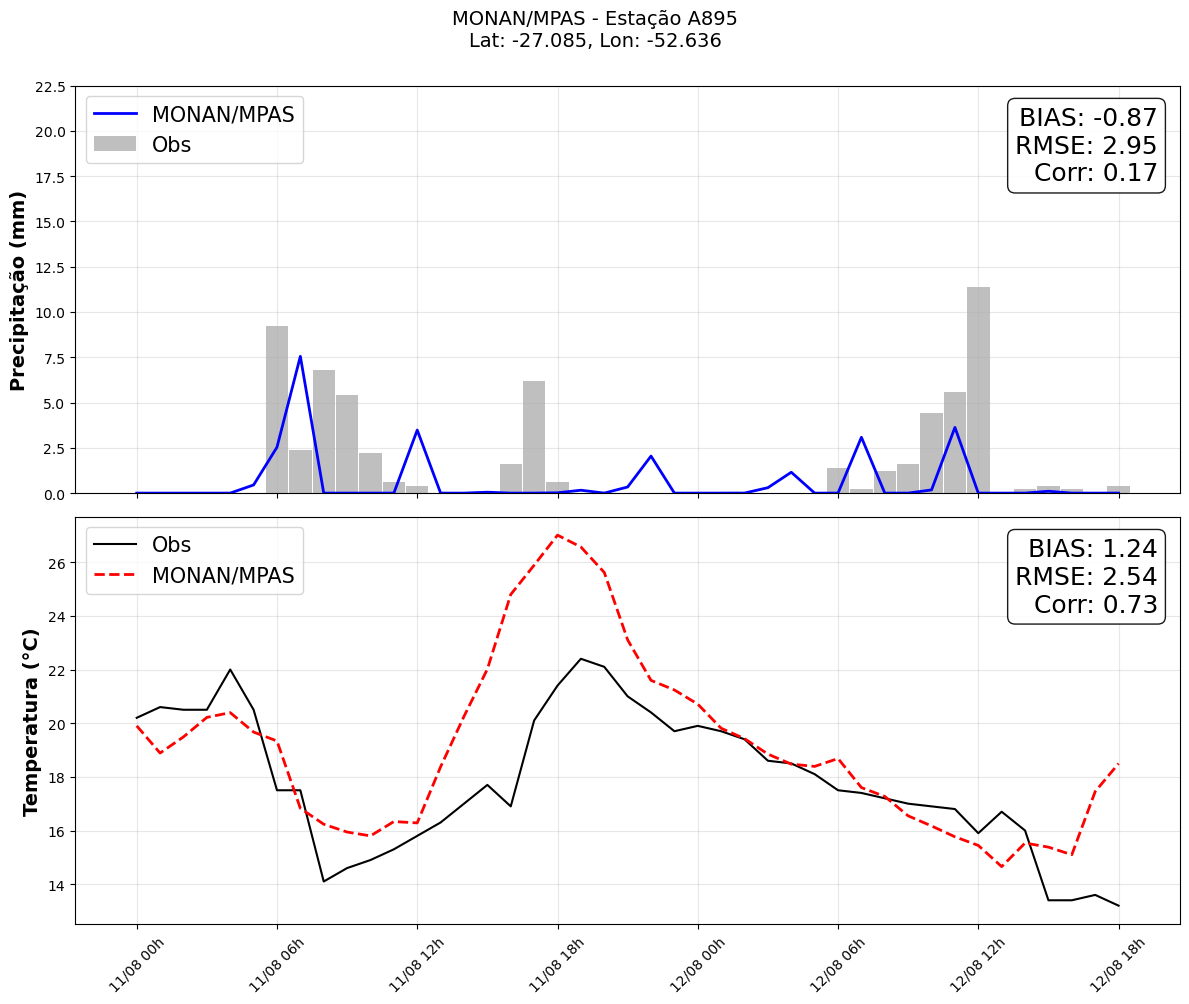

In [53]:
#Dados estações 3x3
import os
import glob
import sys
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import gc

# Ignorar avisos
warnings.filterwarnings("ignore")

# --- 1. CONFIGURAÇÕES ---
ESTACOES_DIR = '/home/jovyan/privado/Estações INMET/Estações2023'
# Ajuste o diretório do seu modelo MPAS
MODEL_DIR = '/home/jovyan/privado/MONAN/202308' 
DATA_INICIO = '2023-08-11'
DATA_FIM = '2023-08-12'
ESTACAO_ALVO = 'A895'  # Código da estação desejada

# Configuração de Saída
DIR_SAIDA_IMAGENS = '/home/jovyan/privado/MONAN/Saidas202308'
NOME_ARQUIVO_SAIDA = os.path.join(DIR_SAIDA_IMAGENS, f'grafico_validacao_MPAS_{ESTACAO_ALVO}_3x3.png')

LIMITES_FISICOS = {
    'temp': (-80, 60), 
    'prec': (0, 500)
}

# --- 2. FUNÇÕES AUXILIARES ---

def encontrar_arquivo_estacao(diretorio, codigo):
    padrao = os.path.join(diretorio, f'*{codigo}*.CSV')
    arquivos = glob.glob(padrao)
    if not arquivos:
        padrao = os.path.join(diretorio, f'*{codigo}*.csv')
        arquivos = glob.glob(padrao)
    return arquivos[0] if arquivos else None

def carregar_dados_estacao(caminho_arquivo):
    """Lê CSV do INMET"""
    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            linhas = f.readlines()
            lat = float(linhas[4].split(';')[1].replace(',', '.'))
            lon = float(linhas[5].split(';')[1].replace(',', '.'))

        df = pd.read_csv(
            caminho_arquivo, sep=';', skiprows=8, decimal=',',
            encoding='latin-1', engine='python', na_values=['-9999', 'null', '', 'nan']
        )
        
        # Tratamento de Data
        if 'Data' in df.columns and 'Hora UTC' in df.columns:
            df['Data'] = df['Data'].astype(str).str.replace('/', '-')
            df['Hora UTC'] = df['Hora UTC'].astype(str).str.replace(' UTC', '').str.replace(':', '').str.strip().str.zfill(4)
            datetime_str = df['Data'] + ' ' + df['Hora UTC']
            df['datetime'] = pd.to_datetime(datetime_str, format='%Y-%m-%d %H%M', errors='coerce')
        else:
            # Tenta pegar coluna combinada se existir
            df['datetime'] = pd.to_datetime(df.iloc[:,0], errors='coerce')

        df = df.dropna(subset=['datetime']).set_index('datetime').sort_index()
        
        df.index = df.index.round('1h')
        if df.index.tz is not None: df.index = df.index.tz_localize(None)
        
        # Filtro de Data
        df = df[DATA_INICIO:DATA_FIM]

        cols_map = {
            'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)': 'prec_obs',
            'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': 'temp_obs'
        }
        cols = {k: v for k, v in cols_map.items() if k in df.columns}
        df = df[cols.keys()].rename(columns=cols)
        
        # Garante float
        for c in df.columns: df[c] = pd.to_numeric(df[c], errors='coerce')
        
        return df, lat, lon
    except Exception as e:
        print(f"Erro ao ler estação: {e}")
        return None, None, None

def extrair_dados_mpas_3x3(diretorio_modelo, lat_alvo, lon_alvo):
    print("Carregando Dataset MPAS (NetCDF)...")
    try:
        # Abre múltiplos arquivos (otimizado com Dask/Xarray)
        ds = xr.open_mfdataset(
            os.path.join(diretorio_modelo, '*.nc'), 
            combine='by_coords', 
            engine='netcdf4'
        )
        
        # --- Tratamento de Longitude (0-360 para -180/180) ---
        if 'longitude' in ds.coords:
            if ds['longitude'].max() > 180:
                print("  Ajustando longitude do modelo (0-360 -> -180/180)...")
                ds.coords['longitude'] = (ds.coords['longitude'] + 180) % 360 - 180
                ds = ds.sortby('longitude')
        
        # --- Localizar Índices ---
        print(f"Localizando ponto mais próximo de Lat: {lat_alvo}, Lon: {lon_alvo}...")
        
        # Calcula distâncias absolutas para achar o centro
        lats = ds['latitude'].values
        lons = ds['longitude'].values
        
        lat_idx = np.abs(lats - lat_alvo).argmin()
        lon_idx = np.abs(lons - lon_alvo).argmin()
        
        # Validação de Borda para 3x3
        if lat_idx < 1 or lat_idx >= len(lats)-1 or lon_idx < 1 or lon_idx >= len(lons)-1:
            print("ERRO: Estação muito próxima da borda do domínio do modelo.")
            return pd.DataFrame()

        # --- Extração e Média 3x3 ---
        print("Calculando média 3x3...")
        
        # Slice: Seleciona lat_idx-1 até lat_idx+2 (o +2 é exclusivo no python, então pega +1)
        vizinhanca = ds.isel(
            latitude=slice(lat_idx - 1, lat_idx + 2),
            longitude=slice(lon_idx - 1, lon_idx + 2)
        )
        
        # Carrega dados para a RAM para processar
        # Ajuste aqui os nomes das variáveis do SEU arquivo MPAS ('t2m', 'prec', etc)
        subset = vizinhanca[['t2m', 'prec']].load()
        
        # 1. Temperatura: Média da área (K -> C)
        temp_area_mean = subset['t2m'].mean(dim=['latitude', 'longitude']) - 273.15
        
        # 2. Chuva: Média da área
        prec_area_mean = subset['prec'].mean(dim=['latitude', 'longitude'])
        
        # Cria DataFrame
        df_mod = pd.DataFrame({
            'temp_mod': temp_area_mean.values,
            'prec_acum': prec_area_mean.values
        }, index=pd.to_datetime(subset.Time.values))
        
        # Remove duplicatas de tempo
        df_mod = df_mod[~df_mod.index.duplicated(keep='first')]
        
        # Calcula chuva horária (diferença do acumulado)
        df_mod['prec_mod'] = df_mod['prec_acum'].diff().fillna(0).clip(lower=0)
        
        return df_mod[['temp_mod', 'prec_mod']]

    except Exception as e:
        print(f"Erro fatal ao processar MPAS: {e}")
        return pd.DataFrame()

def calcular_stats(obs, mod):
    diff = mod - obs
    bias = diff.mean()
    rmse = np.sqrt((diff**2).mean())
    corr = obs.corr(mod)
    return bias, rmse, corr

# --- 3. PRINCIPAL ---

if __name__ == "__main__":
    gc.collect()
    
    # Cria diretório de saída
    if not os.path.exists(DIR_SAIDA_IMAGENS):
        os.makedirs(DIR_SAIDA_IMAGENS, exist_ok=True)
    
    print(f"=== GERANDO GRÁFICO MPAS (MÉDIA 3x3) PARA {ESTACAO_ALVO} ===")
    
    # 1. Dados da Estação
    arq_estacao = encontrar_arquivo_estacao(ESTACOES_DIR, ESTACAO_ALVO)
    if not arq_estacao: sys.exit("Estação não encontrada.")
    
    print(f"Lendo Estação: {os.path.basename(arq_estacao)}")
    df_obs, lat, lon = carregar_dados_estacao(arq_estacao)
    if df_obs is None or df_obs.empty: sys.exit("Sem dados válidos na estação.")

    # 2. Dados do Modelo MPAS
    df_mod = extrair_dados_mpas_3x3(MODEL_DIR, lat, lon)
    
    if df_mod.empty: sys.exit("Falha na extração do modelo MPAS.")
    
    # Ajuste fino de índices temporais
    df_mod.index = df_mod.index.round('1h')
    if df_mod.index.tz is not None: df_mod.index = df_mod.index.tz_localize(None)

    # 3. Merge (Cruzamento)
    df_final = pd.merge(df_obs, df_mod, left_index=True, right_index=True, how='inner')
    if df_final.empty: sys.exit("Nenhuma data coincidente entre Estação e Modelo.")

    # 4. Plotagem
   # 4. Plotagem
    print("Gerando gráfico...")
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    configs = [
        ('Precipitação', 'prec_obs', 'prec_mod', 'mm', 'blue', 'bar'),
        ('Temperatura', 'temp_obs', 'temp_mod', '°C', 'red', 'line')
    ]

    for i, (nome, obs_col, mod_col, unid, cor, tipo) in enumerate(configs):
        ax = axes[i]
        
        if obs_col in df_final:
            limites = LIMITES_FISICOS[nome.lower()[:4]]
            df_p = df_final[
                (df_final[obs_col].between(limites[0], limites[1])) & 
                (df_final[mod_col].between(limites[0], limites[1]))
            ]
            
            if df_p.empty:
                ax.text(0.5, 0.5, "Sem dados válidos no range", ha='center', transform=ax.transAxes)
                continue

            b, r, c = calcular_stats(df_p[obs_col], df_p[mod_col])
            stats_str = f"BIAS: {b:.2f}\nRMSE: {r:.2f}\nCorr: {c:.2f}"
            
            if tipo == 'bar':
                ax.bar(df_p.index, df_p[obs_col], color='gray', alpha=0.5, label='Obs', width=0.04)
                ax.plot(df_p.index, df_p[mod_col], color=cor, label='MONAN/MPAS', linewidth=2)
            else:
                ax.plot(df_p.index, df_p[obs_col], 'k-', label='Obs', linewidth=1.5)
                ax.plot(df_p.index, df_p[mod_col], color=cor, label='MONAN/MPAS', linewidth=2, linestyle='--')
            
            # --- ALTERAÇÃO AQUI ---
            # Fixar o eixo Y se for precipitação
            if nome == 'Precipitação':
                ax.set_ylim(0, 22.5)
            # ----------------------

            ax.set_ylabel(f"{nome} ({unid})", fontweight='bold', fontsize = 14)
            ax.legend(loc='upper left', fontsize = 15)
            ax.grid(True, alpha=0.3)
            
            ax.text(0.98, 0.95, stats_str, transform=ax.transAxes, 
                    ha='right', va='top', bbox=dict(boxstyle="round", fc="w", alpha=0.9), fontsize = 18)
        else:
            ax.text(0.5, 0.5, "Variável não encontrada", ha='center', transform=ax.transAxes)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    plt.xticks(rotation=45)
    plt.suptitle(f"MONAN/MPAS - Estação {ESTACAO_ALVO}\nLat: {lat:.3f}, Lon: {lon:.3f}", fontsize=14, y=1)
    
    plt.tight_layout()
    plt.savefig(NOME_ARQUIVO_SAIDA, dpi=300)
    print(f"Concluído! Gráfico salvo em: {NOME_ARQUIVO_SAIDA}")
    plt.show()

Iniciando processamento do arquivo: /home/jovyan/privado/Dados/ERA5/7d9d9eb4490d52582db9471eeb56450f.grib


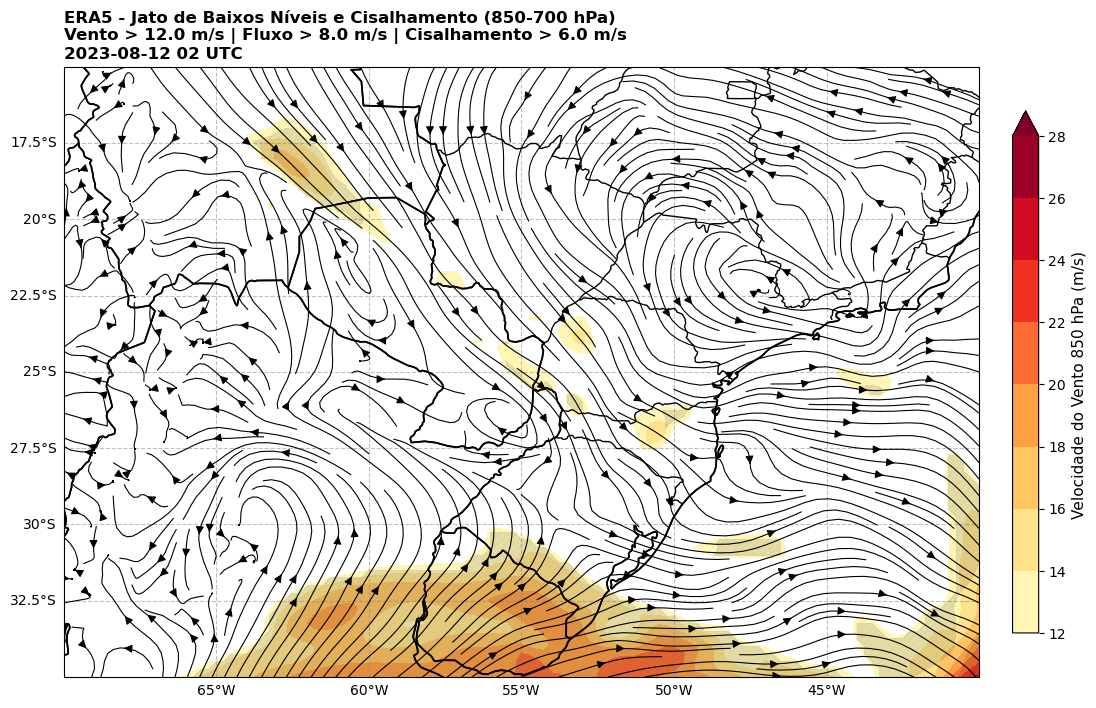

In [41]:
#JBN ERA5
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- 1. CONFIGURAÇÕES E PARÂMETROS ---
caminho_arquivo = '/home/jovyan/privado/Dados/ERA5/7d9d9eb4490d52582db9471eeb56450f.grib'
output_path = '/home/jovyan/privado/Saidas/ERA5/JBN'
os.makedirs(output_path, exist_ok=True)

nivel_base = 850.0  # Nível principal para o JBN
nivel_topo = 700.0  # Nível superior para cálculo do cisalhamento vertical
limiar_jato = 12.0  # Velocidade mínima para JBN (m/s)
limiar_stream = 8.0 # Velocidade mínima para desenhar linhas de corrente (m/s)
limiar_cisalhamento = 6.0 # Cisalhamento vertical mínimo para a textura (m/s)
hora = 26 # Índice temporal no arquivo

print(f"Iniciando processamento do arquivo: {caminho_arquivo}")

try:
    # --- 2. LEITURA E ROTEAMENTO DE DADOS (ERA5) ---
    # O motor 'cfgrib' é obrigatório para arquivos GRIB operacionais do ECMWF.
    if caminho_arquivo.endswith('.grib'):
        ds = xr.open_dataset(caminho_arquivo, engine='cfgrib')
        coord_pressao = 'isobaricInhPa'
    else:
        ds = xr.open_dataset(caminho_arquivo)
        coord_pressao = 'level' # Ajuste se o seu NetCDF usar 'plev'

    # Verifica se a coordenada de pressão existe e seleciona os dois níveis
    if coord_pressao in ds.coords:
        ds_850 = ds.sel({coord_pressao: nivel_base}, method='nearest')
        ds_700 = ds.sel({coord_pressao: nivel_topo}, method='nearest')
    else:
        raise ValueError("Coordenada de pressão não encontrada. O arquivo deve ter os níveis 850 e 700 hPa.")

    # Seleção Temporal (Primeiro tempo disponível para análise)
    tempo_atual = ds_850['time'].values[hora]
    ds_plot_850 = ds_850.sel(time=tempo_atual)
    ds_plot_700 = ds_700.sel(time=tempo_atual)

    # Extração de Variáveis de Vento
    u_850 = ds_plot_850['u']
    v_850 = ds_plot_850['v']
    u_700 = ds_plot_700['u']
    v_700 = ds_plot_700['v']
    
    # Padronização de Coordenadas (ERA5 pode usar 'latitude'/'longitude' ou 'lat'/'lon')
    lat_name = 'latitude' if 'latitude' in u_850.coords else 'lat'
    lon_name = 'longitude' if 'longitude' in u_850.coords else 'lon'
    lons = ds_plot_850[lon_name].values
    lats = ds_plot_850[lat_name].values

    # --- 3. CÁLCULOS METEOROLÓGICOS ---
    # Magnitude do vento em 850 hPa
    vel_vento_850 = np.sqrt(u_850**2 + v_850**2)

    # Magnitude do Cisalhamento Vertical (850 - 700 hPa)
    cisalhamento = np.sqrt((u_850 - u_700)**2 + (v_850 - v_700)**2)

    # Filtro Analítico: Cisalhamento APENAS dentro do núcleo do Jato (> 12 m/s)
    cisalhamento_jato = np.ma.masked_where(vel_vento_850.values < limiar_jato, cisalhamento.values)

    # Máscara para as Streamlines (Apenas fluxo > 8 m/s)
    u_masked = np.ma.masked_where(vel_vento_850.values < limiar_stream, u_850.values)
    v_masked = np.ma.masked_where(vel_vento_850.values < limiar_stream, v_850.values)

    # --- 4. ARQUITETURA DE PLOTAGEM (A NOVA ESTRUTURA GARANTIDA) ---
    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    
    # Domínio focado no Sul do Brasil / Uruguai / Argentina / Paraguai
    ax.set_extent([-70, -40, -35, -15], crs=ccrs.PlateCarree())

    # CAMADA 1 (Fundo): Preenchimento de Cor da Velocidade (850 hPa)
    # Z-order baixo para que as fronteiras fiquem em cima.
    niveis_jato = np.arange(limiar_jato, 30, 2) 
    contorno = ax.contourf(
        lons, lats, vel_vento_850,
        levels=niveis_jato,
        cmap='YlOrRd',
        transform=ccrs.PlateCarree(),
        extend='max',
        zorder=1
    )

# CAMADA 2: Hachuras de Cisalhamento Forte APENAS dentro do Jato
    regiao_cisalhamento = ax.contourf(
        lons, lats, cisalhamento_jato, 
        levels=[limiar_cisalhamento, 100],
        colors='none',
        hatches=['////'],
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    # Ajuste manual da hachura com proteção de versão (Matplotlib antigo vs novo)
    try:
        # Tenta o método legado (Matplotlib < 3.8)
        for collection in regiao_cisalhamento.collections:
            collection.set_edgecolor('#aaaaaa') # Cinza claro
            collection.set_linewidth(0.1)       # Linhas finas
            collection.set_alpha(0.1)           # Transparência
    except AttributeError:
        # Aplica o método moderno (Matplotlib >= 3.8)
        regiao_cisalhamento.set_edgecolor('#aaaaaa')
        regiao_cisalhamento.set_linewidth(0.1)
        regiao_cisalhamento.set_alpha(0.1)

    # CAMADA 3: Linhas de Corrente (Streamlines)
    # Z-order inferior ao da geografia para não tapar as fronteiras.
    ax.streamplot(
        lons, lats, u_masked, v_masked,
        transform=ccrs.PlateCarree(),
        color='black',
        linewidth=0.8,
        density=2.5,
        arrowsize=1.2,
        zorder=3 
    )

    # --- CAMADA 4 (GEOGRAFIA GARANTIDA - AGRESSIVA): ---
    # Z-order superior a TUDO (zorder=4 e 5) para garantir visibilidade.
    
    # Litoral
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=1.2, edgecolor='black', zorder=4)

    # Países (carregamento explícito e controlado do Natural Earth)
    countries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_countries',
        scale='50m',
        facecolor='none',
        edgecolor='black',
        linewidth=1.2
    )
    ax.add_feature(countries, zorder=4)

    # Estados / Províncias (as linhas internas de admin_1_states_provinces)
    states_lines = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m', # Escala 50m é mais comum e compatível com 50m do litoral/países.
        facecolor='none',
        edgecolor='black',
        linewidth=1.0
    )
    ax.add_feature(states_lines, zorder=5) # Estados no topo dos países
    
    # Linhas de grade (coordenadas)
    gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.5, zorder=3)
    gl.top_labels = False
    gl.right_labels = False

    # --- 5. ACABAMENTO ---
    # Barra de cores
    cb = plt.colorbar(contorno, ax=ax, orientation='vertical', shrink=0.6, pad=0.03)
    cb.set_label('Velocidade do Vento 850 hPa (m/s)', fontsize=11)

    # Título formatado
    data_str = np.datetime_as_string(tempo_atual, unit='h').replace('T', ' ')
    plt.title(f'ERA5 - Jato de Baixos Níveis e Cisalhamento (850-700 hPa)\n'
              f'Vento > {limiar_jato} m/s | Fluxo > {limiar_stream} m/s | Cisalhamento > {limiar_cisalhamento} m/s\n'
              f'{data_str} UTC', 
              fontsize=12, loc='left', fontweight='bold')
    
    output_filename = os.path.join(output_path, f'ERA5-JBN_Shear_GeoGarantida_{tempo_atual}.png')
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()
    
    ds.close()

except Exception as e:
    print(f"Falha crítica durante a execução: {e}")

In [122]:
#W max level 1 e column
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
import warnings

warnings.filterwarnings("ignore")
try:
    import pyart
    cmap_w = 'ChaseSpec_c'
    cmap_ws = 'ChaseSpec_c'
except ImportError:
    print("Aviso: Biblioteca 'pyart' não instalada no servidor. Usando mapas de cores nativos (RdBu_r e YlOrRd).")
    cmap_w = 'RdBu_r'   # Divergente padrão para W (negativo/positivo)
    cmap_ws = 'YlOrRd'  # Sequencial padrão para Vento

radar_lon = -52.60374
radar_lat = -27.04879
set_lon = -52.60374  
set_lat = -27.04879  

# Caminho de Entrada (Ajuste para a pasta correta dos seus arquivos NetCDF no servidor)
pasta = '/home/jovyan/privado/MONAN/202308' # <-- Substitua se necessário

# Caminhos de Saída
output_path_w_vel = '/home/jovyan/privado/Saidas/Espacial/WVelMax/'
output_path_wind_speed = '/home/jovyan/privado/Saidas/Espacial/WindSpeedMax/'

os.makedirs(output_path_w_vel, exist_ok=True)
os.makedirs(output_path_wind_speed, exist_ok=True)

# ==============================================================================
# 3. CARREGAMENTO GEOESPACIAL
# ==============================================================================
# Caminho absoluto do Shapefile no seu servidor
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'

try:
    municipios_reader = shpreader.Reader(shp_path)
    municipios_feature = ShapelyFeature(
        municipios_reader.geometries(),
        ccrs.PlateCarree(),
        edgecolor='black',
        facecolor='none',
        linewidth=0.5
    )
    tem_shp = True
except Exception as e:
    print(f"Aviso: Não foi possível carregar o Shapefile de municípios -> {e}")
    tem_shp = False

estados_feature = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lines',
    scale='10m',
    facecolor='none',
    edgecolor='black',
    linewidth=0.5
)

# ==============================================================================
# 4. LOOP DE PROCESSAMENTO E PLOTAGEM
# ==============================================================================
arquivos_nc = [f for f in os.listdir(pasta) if f.endswith('.nc')]
print(f"Encontrados {len(arquivos_nc)} arquivos NetCDF para processar.")

for arquivo in arquivos_nc:
    caminho_arquivo = os.path.join(pasta, arquivo)
    
    # Extração de data/hora protegida
    nome_arquivo_base = os.path.splitext(arquivo)[0]
    try:
        raw_data_hora = nome_arquivo_base.split('_')[6]
        data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
    except IndexError:
        data_hora = nome_arquivo_base # Fallback caso o nome não tenha a estrutura esperada
    
    print(f"Processando: {data_hora}...")
    
    try:
        xrds = xr.open_dataset(caminho_arquivo)
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
        
        # --------------------------------------------------------------
        # PLOT 1: Velocidade Vertical Máxima (w_velocity_max)
        # --------------------------------------------------------------
        w_vel = xrds['w_velocity_max'][0, :, :]
        
        fig1 = plt.figure(figsize=(12, 10))
        ax1 = plt.axes(projection=ccrs.PlateCarree())
        
        vmin_w, vmax_w = 10, 50
        levels_w = np.linspace(vmin_w, vmax_w, 101)
        
        plot1 = ax1.contourf(
            lon, lat, w_vel,
            transform=ccrs.PlateCarree(),
            cmap=cmap_w,  
            levels=levels_w,
            extend='max'
        )
        cbar1 = plt.colorbar(plot1, shrink=0.85)
        cbar1.set_label(label='Max W Velocity (m/s)', fontsize=14)
        
        ax1.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax1.add_feature(estados_feature)
        if tem_shp: ax1.add_feature(municipios_feature)
        
        ax1.set_extent([radar_lon - 3.5, radar_lon + 3.5, radar_lat - 3.5, radar_lat + 3.5], crs=ccrs.PlateCarree())
        
        ax1.plot(set_lon, set_lat, marker='*', color='yellow', markersize=10, transform=ccrs.PlateCarree(), markeredgecolor='black')
        gl1 = ax1.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.7)
        gl1.top_labels = gl1.right_labels = False
        
        plt.suptitle(f'{data_hora}', fontsize=18, ha='left', x=0.13, y=0.93, fontweight='bold')
        plt.title('Max Column Vertical Velocity (Shaded)', ha='left', fontsize=12, loc='left')
        
        output_filename1 = os.path.join(output_path_w_vel, f'WVelMax_{nome_arquivo_base}.png')
        plt.savefig(output_filename1, dpi=300, bbox_inches='tight')
        plt.close(fig1)

        # --------------------------------------------------------------
        # PLOT 2: Velocidade do Vento Máxima (wind_speed_level1_max)
        # --------------------------------------------------------------
        wind_speed = xrds['wind_speed_level1_max'][0, :, :]
        
        fig2 = plt.figure(figsize=(12, 10))
        ax2 = plt.axes(projection=ccrs.PlateCarree())
        
        vmin_ws, vmax_ws = 10, 50 
        levels_ws = np.linspace(vmin_ws, vmax_ws, 100)
        
        plot2 = ax2.contourf(
            lon, lat, wind_speed,
            transform=ccrs.PlateCarree(),
            cmap=cmap_ws,
            levels=levels_ws,
            extend='max'
        )
        cbar2 = plt.colorbar(plot2, shrink=0.85)
        cbar2.set_label(label='Max Wind Speed at Level 1 (m/s)', fontsize=14)
        
        ax2.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.8)
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax2.add_feature(estados_feature)
        if tem_shp: ax2.add_feature(municipios_feature)
        
        ax2.set_extent([radar_lon - 3.5, radar_lon + 3.5, radar_lat - 3.5, radar_lat + 3.5], crs=ccrs.PlateCarree())
        
        ax2.plot(set_lon, set_lat, marker='*', color='yellow', markersize=10, transform=ccrs.PlateCarree(), markeredgecolor='black')
        gl2 = ax2.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.7)
        gl2.top_labels = gl2.right_labels = False
        
        plt.suptitle(f'{data_hora}', fontsize=18, ha='left', x=0.13, y=0.93, fontweight='bold')
        plt.title('Max Wind Speed at Level 1 (Shaded)', ha='left', fontsize=12, loc='left')
        
        output_filename2 = os.path.join(output_path_wind_speed, f'WindSpeedMax_{nome_arquivo_base}.png')
        plt.savefig(output_filename2, dpi=300, bbox_inches='tight')
        plt.close(fig2)
        
        xrds.close()
        
    except Exception as e:
        print(f"Erro inesperado no arquivo {arquivo}: {e}")

print("Processamento concluído com sucesso!")

Encontrados 43 arquivos NetCDF para processar.
Processando: 12:00 UTC 12/08/2023...
Processando: 08:00 UTC 12/08/2023...
Processando: 15:00 UTC 12/08/2023...
Processando: 01:00 UTC 12/08/2023...
Processando: 06:00 UTC 12/08/2023...
Processando: 22:00 UTC 11/08/2023...
Processando: 17:00 UTC 11/08/2023...
Processando: 10:00 UTC 11/08/2023...
Processando: 04:00 UTC 11/08/2023...
Processando: 19:00 UTC 11/08/2023...
Processando: 03:00 UTC 11/08/2023...
Processando: 05:00 UTC 12/08/2023...
Processando: 18:00 UTC 12/08/2023...
Processando: 21:00 UTC 11/08/2023...
Processando: 02:00 UTC 12/08/2023...
Processando: 16:00 UTC 12/08/2023...
Processando: 11:00 UTC 12/08/2023...
Processando: 00:00 UTC 11/08/2023...
Processando: 07:00 UTC 11/08/2023...
Processando: 13:00 UTC 11/08/2023...
Processando: 09:00 UTC 11/08/2023...
Processando: 14:00 UTC 11/08/2023...
Processando: 02:00 UTC 11/08/2023...
Processando: 18:00 UTC 11/08/2023...
Processando: 05:00 UTC 11/08/2023...
Processando: 11:00 UTC 11/08

In [ ]:
#SRH 13/04
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. TRATAMENTO DE DEPENDÊNCIAS VISUAIS
# ==============================================================================
try:
    import pyart
    cmap_srh = 'LangRainbow12'
except ImportError:
    print("Aviso: Biblioteca 'pyart' não instalada no servidor. Usando mapa de cores nativo (turbo).")
    cmap_srh = 'turbo' # Alternativa visual excelente para o LangRainbow

# ==============================================================================
# 2. CONFIGURAÇÕES GERAIS E CAMINHOS
# ==============================================================================
radar_lon = -52.60374
radar_lat = -27.04879

# Caminho de Entrada (Ajuste o diretório se seus arquivos NetCDF estiverem em outra pasta)
pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/' 

# Caminho de Saída
output_path = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810/SRH_03'
os.makedirs(output_path, exist_ok=True)

# ==============================================================================
# 3. CARREGAMENTO GEOESPACIAL (SHAPEFILE)
# ==============================================================================
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'

try:
    municipios_reader = shpreader.Reader(shp_path)
    municipios_feature = ShapelyFeature(
        municipios_reader.geometries(), ccrs.PlateCarree(),
        edgecolor='gray', facecolor='none', linewidth=0.5
    )
    tem_shp = True
except Exception as e:
    print(f"Aviso: Não foi possível carregar o Shapefile de municípios -> {e}")
    tem_shp = False

estados_feature = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none', edgecolor='gray', linewidth=0.5
)

# Limites Globais de Plotagem
vmin_global = -300
vmax_global = 300
levels_srh = np.linspace(vmin_global, vmax_global+1, 100)

# ==============================================================================
# 4. LOOP DE PROCESSAMENTO
# ==============================================================================
arquivos_nc = [f for f in os.listdir(pasta) if f.endswith('.nc')]
print(f"Encontrados {len(arquivos_nc)} arquivos NetCDF para processar.")

for arquivo in arquivos_nc:
    caminho_arquivo = os.path.join(pasta, arquivo)
    
    # Extração de data/hora (com fallback para não quebrar o código se o nome for diferente)
    try:
        raw = os.path.basename(arquivo).split('_')[6].split('.')[0]  
        ano, mes, dia, hora = raw[:4], raw[4:6], raw[6:8], raw[8:10]
        data_hora = f'{hora}:00 UTC {dia}/{mes}/{ano}'
    except IndexError:
        data_hora = os.path.splitext(arquivo)[0]

    print(f"Processando: {data_hora}...")
    
    try:
        xrds = xr.open_dataset(caminho_arquivo)
        
        srh = xrds['srh_0_3km']  
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
               
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        srh_plot = ax.contourf(
            lon, lat, srh[0, :, :], 
            transform=ccrs.PlateCarree(),
            cmap='refdiff_c', 
            alpha=0.8, 
            levels=levels_srh,
            extend='max' 
        )
        
        # Corrigido: Unidade real do SRH
        cbar = plt.colorbar(srh_plot, pad=0.03, shrink=0.85,ticks=np.arange(vmin_global, vmax_global + 1, 100))
        cbar.set_label('SRH ($m^2/s^2$)', fontsize=12, fontweight='bold')
        
        # Adicionando features ao mapa
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        ax.add_feature(estados_feature)
        if tem_shp: ax.add_feature(municipios_feature) # Corrigido: O shapefile agora é plotado
        
        # Zoom conforme a posição do radar (+- 1 grau)
        ax.set_extent([radar_lon - 2, radar_lon + 2, radar_lat - 2, radar_lat + 2], crs=ccrs.PlateCarree())

        # Marcar o radar (alterado para estrela amarela com borda preta para melhor contraste)
        ax.plot(radar_lon, radar_lat, marker='*', markersize=12, color='yellow',
                markeredgecolor='black', markeredgewidth=1.0, transform=ccrs.PlateCarree())
        
        # Adicionar gridlines com rótulos
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.8)
        gl.top_labels = gl.right_labels = False
        
        plt.title(f'Storm Relative Helicity (0-3 km)\n{data_hora}', fontsize=14, fontweight='bold', loc='left')
        
        output_filename = os.path.join(output_path, f'SRH_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close(fig)
        xrds.close()
        
    except Exception as e:
        print(f"Erro ao processar o arquivo {arquivo}: {e}")

print("Processamento concluído com sucesso!")

Encontrados 73 arquivos NetCDF para processar.
Processando: 22:00 UTC 10/08/2023...
Processando: 06:00 UTC 10/08/2023...
Processando: 16:00 UTC 10/08/2023...
Processando: 12:00 UTC 10/08/2023...
Processando: 02:00 UTC 10/08/2023...
Processando: 17:00 UTC 11/08/2023...
Processando: 03:00 UTC 12/08/2023...
Processando: 13:00 UTC 12/08/2023...
Processando: 23:00 UTC 11/08/2023...
Processando: 07:00 UTC 11/08/2023...
Processando: 03:00 UTC 11/08/2023...
Processando: 17:00 UTC 12/08/2023...
Processando: 07:00 UTC 12/08/2023...
Processando: 13:00 UTC 11/08/2023...
Processando: 23:00 UTC 12/08/2023...
Processando: 04:00 UTC 11/08/2023...
Processando: 19:00 UTC 10/08/2023...
Processando: 10:00 UTC 12/08/2023...
Processando: 20:00 UTC 11/08/2023...
Processando: 09:00 UTC 10/08/2023...
Processando: 00:00 UTC 12/08/2023...
Processando: 14:00 UTC 11/08/2023...
Processando: 10:00 UTC 11/08/2023...
Processando: 20:00 UTC 12/08/2023...
Processando: 04:00 UTC 12/08/2023...


In [6]:
# SRH - Cisalhamento (SFC - 700hPa)
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import numpy as np
import warnings
import pyart
warnings.filterwarnings("ignore")

# ==============================================================================
# 1. TRATAMENTO DE DEPENDÊNCIAS VISUAIS
# ==============================================================================
cmap_srh = 'LangRainbow12'

# ==============================================================================
# 2. CONFIGURAÇÕES GERAIS E CAMINHOS
# ==============================================================================
radar_lon = -52.60374
radar_lat = -27.04879

pasta = '/home/jovyan/privado/MONAN/202308/' 
output_path = '/home/jovyan/privado/Saidas/Espacial/SRH1_Shear/' 
os.makedirs(output_path, exist_ok=True)

# ==============================================================================
# 3. CARREGAMENTO GEOESPACIAL
# ==============================================================================
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'

try:
    municipios_reader = shpreader.Reader(shp_path)
    municipios_feature = ShapelyFeature(
        municipios_reader.geometries(), ccrs.PlateCarree(),
        edgecolor='gray', facecolor='none', linewidth=0.5
    )
    tem_shp = True
except Exception as e:
    print(f"Aviso: Não foi possível carregar o Shapefile de municípios -> {e}")
    tem_shp = False

estados_feature = cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='10m', facecolor='none', edgecolor='gray', linewidth=0.5
)

vmin_global = 30
vmax_global = 500
levels_srh = np.linspace(vmin_global, vmax_global+1, 100)

# ==============================================================================
# 4. LOOP DE PROCESSAMENTO
# ==============================================================================
arquivos_nc = [f for f in os.listdir(pasta) if f.endswith('.nc')]
print(f"Encontrados {len(arquivos_nc)} arquivos NetCDF para processar.")

for arquivo in arquivos_nc:
    caminho_arquivo = os.path.join(pasta, arquivo)
    
    try:
        raw = os.path.basename(arquivo).split('_')[6].split('.')[0]  
        ano, mes, dia, hora = raw[:4], raw[4:6], raw[6:8], raw[8:10]
        data_hora = f'{hora}:00 UTC {dia}/{mes}/{ano}'
    except IndexError:
        data_hora = os.path.splitext(arquivo)[0]

    print(f"Processando: {data_hora}...")
    
    try:
        xrds = xr.open_dataset(caminho_arquivo)
        
        # Extração de variáveis base
        srh = xrds['srh_0_1km']  
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
        
        
        ms_to_knots = 1.94384
        u_sfc = xrds['u10'][0, :, :] * ms_to_knots
        v_sfc = xrds['v10'][0, :, :] * ms_to_knots
        
        
        u_700 = xrds['uzonal_1km'][0, :, :] * ms_to_knots
        v_700 = xrds['umeridional_1km'][0, :, :] * ms_to_knots
        
        shear_u = u_700 - u_sfc
        shear_v = v_700 - v_sfc
        
        # Subamostragem ajustada para o zoom local (+- 1 grau)
        step = 25 # Avalie se as barbelas ficam muito densas ou esparsas e ajuste este valor
        lat_barbs = lat[::step]
        lon_barbs = lon[::step]
        shear_u_barbs = shear_u[::step, ::step]
        shear_v_barbs = shear_v[::step, ::step]
                
        # Plotagem
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())
        
        srh_plot = ax.contourf(
            lon, lat, srh[0, :, :], 
            transform=ccrs.PlateCarree(),
            cmap='refdiff_c',
            alpha=0.8, 
            levels=levels_srh,
            extend='max' 
        )
        
        cbar = plt.colorbar(srh_plot, pad=0.03, shrink=0.85, ticks=np.arange(vmin_global, vmax_global + 1, 100))
        cbar.set_label('SRH ($m^2/s^2$)', fontsize=12, fontweight='bold')
        
        # Adicionando as barbelas do cisalhamento
        ax.barbs(lon_barbs, lat_barbs, shear_u_barbs.values, shear_v_barbs.values, 
                 transform=ccrs.PlateCarree(), length=5.5, color='black', alpha=0.75, linewidth=0.8)
        
        # Adicionando features ao mapa
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='gray')
        ax.add_feature(estados_feature)
        if tem_shp: ax.add_feature(municipios_feature) 
        
        # Zoom conforme a posição do radar (+- 1 grau)
        ax.set_extent([radar_lon - 3, radar_lon + 3, radar_lat - 3, radar_lat + 3], crs=ccrs.PlateCarree())

        ax.plot(radar_lon, radar_lat, marker='*', markersize=12, color='yellow',
                markeredgecolor='black', markeredgewidth=1.0, transform=ccrs.PlateCarree())
        
        gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.8)
        gl.top_labels = gl.right_labels = False
        
        plt.title(f'SRH (0-1 km) & Bulk Shear (SFC-1km)\n{data_hora}', fontsize=13, fontweight='bold', loc='left')
        
        output_filename = os.path.join(output_path, f'SRH_Shear_{os.path.splitext(arquivo)[0]}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close(fig)
        xrds.close()
        
    except Exception as e:
        print(f"Erro ao processar o arquivo {arquivo}: {e}")

print("Processamento concluído com sucesso!")

Encontrados 43 arquivos NetCDF para processar.
Processando: 12:00 UTC 12/08/2023...
Processando: 08:00 UTC 12/08/2023...
Processando: 15:00 UTC 12/08/2023...
Processando: 01:00 UTC 12/08/2023...
Processando: 06:00 UTC 12/08/2023...
Processando: 22:00 UTC 11/08/2023...
Processando: 17:00 UTC 11/08/2023...
Processando: 10:00 UTC 11/08/2023...
Processando: 04:00 UTC 11/08/2023...
Processando: 19:00 UTC 11/08/2023...
Processando: 03:00 UTC 11/08/2023...
Processando: 05:00 UTC 12/08/2023...
Processando: 18:00 UTC 12/08/2023...
Processando: 21:00 UTC 11/08/2023...
Processando: 02:00 UTC 12/08/2023...
Processando: 16:00 UTC 12/08/2023...
Processando: 11:00 UTC 12/08/2023...
Processando: 00:00 UTC 11/08/2023...
Processando: 07:00 UTC 11/08/2023...
Processando: 13:00 UTC 11/08/2023...
Processando: 09:00 UTC 11/08/2023...
Processando: 14:00 UTC 11/08/2023...
Processando: 02:00 UTC 11/08/2023...
Processando: 18:00 UTC 11/08/2023...
Processando: 05:00 UTC 11/08/2023...
Processando: 11:00 UTC 11/08

In [69]:
#SCP
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

# Caminhos
pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
output_path = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810/SCP_Sul' 
os.makedirs(output_path, exist_ok=True)

# Shapefile municípios
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8
)

delta = 4  # zoom
site_lon, site_lat = -52.6791, -27.0972

# Limites do recorte (zoom)
lon_min, lon_max = site_lon - delta, site_lon + delta
lat_min, lat_max = site_lat - delta, site_lat + delta

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)
        
        # Extração de data/hora
        nome_arquivo = os.path.basename(arquivo)
        try:
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"

        xrds = xr.open_dataset(caminho_arquivo)
        
        lat = xrds['latitude'].values
        lon = xrds['longitude'].values
        
        # 1. Extração das variáveis
        u_10m_ms = xrds['u10'][0].values
        v_10m_ms = xrds['v10'][0].values
        u_6km_ms = xrds['uzonal_6km'][0].values
        v_6km_ms = xrds['umeridional_6km'][0].values
        
        mlcape = xrds['mlcape'][0].values
        mucin = xrds['mucin'][0].values 
        
        srh_0_3km = xrds['srh_0_3km'][0].values
        
        # 2. Cálculo do Cisalhamento 0-6km (m/s)
        u_diff_ms = u_6km_ms - u_10m_ms
        v_diff_ms = v_6km_ms - v_10m_ms
        shear_0_6km_ms = np.sqrt(u_diff_ms**2 + v_diff_ms**2)
        termo_cin = np.where(mucin >= -40, 1.0, -40.0 / np.where(mucin == 0, -1e-6, mucin))
        
        scp_sul = (mlcape / 800.0) * (srh_0_3km / -250.0) * (shear_0_6km_ms / 20.0)
        
        # Máscara Física
        mascara_fisica = (mlcape > 0) & (shear_0_6km_ms >= 0) & (srh_0_3km < 0)
        scp_sul = np.where(mascara_fisica, scp_sul, 0)
        
        # 4. Cálculo do valor máximo apenas dentro do recorte de zoom
        # Garante que as matrizes de lat/lon sejam 2D para a máscara lógica
        if lon.ndim == 1 and lat.ndim == 1:
            lon_2d, lat_2d = np.meshgrid(lon, lat)
        else:
            lon_2d, lat_2d = lon, lat
            
        mascara_zoom = (lon_2d >= lon_min) & (lon_2d <= lon_max) & (lat_2d >= lat_min) & (lat_2d <= lat_max)
        max_scp_recorte = np.nanmax(np.where(mascara_zoom, scp_sul, np.nan))
        
        # 5. Conversão do cisalhamento para nós
        u_shear_kt = u_diff_ms * 1.94384
        v_shear_kt = v_diff_ms * 1.94384

        # ---------------------------------------
        # Plotagem
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        

        scp_plot = ax.contourf(
            lon, lat, scp_sul, transform=ccrs.PlateCarree(),
            cmap='pd17_c', levels=np.arange(0.5, 10.5, 0.5),
            extend='max'
        )
    
        plt.colorbar(scp_plot, label='SCP Recalibrado (Adimensional)', shrink=0.8, pad=0.03)
        
        # Barbelas
        step = 28
        ax.barbs(lon[::step], lat[::step], 
                 u_shear_kt[::step,::step], v_shear_kt[::step,::step],
                 transform=ccrs.PlateCarree(), length=6, color='black', linewidth=0.6)

        # Elementos do mapa
        # ax.add_feature(municipios_feature)  # Shapefile
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)
        
        # Marcador e grades
        ax.plot(site_lon, site_lat, marker='*', markersize=15,
                color='white', markeredgecolor='black', transform=ccrs.PlateCarree())
        
        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.7)
        gl.top_labels = gl.right_labels = False
        
        plt.title(f"Supercell Composite Parameter (Sul)\nCisalhamento 0-6km (nós) \nArquivo: {nome_arquivo}\nData: {data_hora}", fontsize=12, loc='center')
        
        # 6. Adição da caixa de texto no canto inferior direito
        ax.text(0.98, 0.02, f'Máx SCP: {max_scp_recorte:.1f}', 
                transform=ax.transAxes, 
                ha='right', va='bottom', 
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))
        # ---------------------------------------

        output_filename = os.path.join(output_path, f'SCP_Sul_Zoom_{raw_data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        xrds.close()

In [58]:
#Sondagem Unitária
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from metpy.plots import SkewT, Hodograph
from metpy.units import units
import metpy.calc as mpcalc

# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO ###
# ######################################################################
MPAS_FILE_PATH = '/home/jovyan/privado/MONAN/granizo2308/2023081100/MONAN_DIAG_R_POS_GFS_2023081100_2023081200.00.00.x1.65536002L55.nc'
TARGET_LAT = -27.56
TARGET_LON = -48.71
OUTPUT_DIR = "/home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens"
# ######################################################################

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"--- Abrindo arquivo MPAS: {MPAS_FILE_PATH} ---")
try:
    ds = xr.open_dataset(MPAS_FILE_PATH)
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{MPAS_FILE_PATH}'")
    sys.exit()

# --- Busca do ponto de grade mais próximo ---
lat_vals = ds['latitude'].values
lon_vals = ds['longitude'].values
iy = int(np.argmin(np.abs(lat_vals - TARGET_LAT)))
ix = int(np.argmin(np.abs(lon_vals - TARGET_LON)))
print(f"Ponto real: Lat {lat_vals[iy]:.4f}, Lon {lon_vals[ix]:.4f}")

def _extract_masked(var_name, iy, ix):
    da = ds[var_name][0, :, iy, ix]
    arr = da.values.astype(float)
    for attr_name in ('_FillValue', 'missing_value'):
        if attr_name in da.attrs:
            fill_val = float(da.attrs[attr_name])
            arr = np.where(np.isclose(arr, fill_val, rtol=1e-3, equal_nan=False), np.nan, arr)
    return arr

# --- Extração dos dados brutos 3D ---
pressure_raw = ds['level'].values.astype(float) # Pa (decrescente de sfc para topo)
temperature_raw = _extract_masked('temperature', iy, ix)
dewpoint_raw = _extract_masked('dewpoint', iy, ix)
height_raw = _extract_masked('zgeo', iy, ix)
u_raw = _extract_masked('uzonal', iy, ix)
v_raw = _extract_masked('umeridional', iy, ix)

# --- Extração dos dados brutos de Superfície ---
p_sfc_val = float(ds['surface_pressure'][0, iy, ix].values)
t_sfc_val = float(ds['temperature_surface'][0, iy, ix].values)
td_sfc_val = float(ds['dewpoint_surface'][0, iy, ix].values)
u_sfc_val = float(ds['u10'][0, iy, ix].values)
v_sfc_val = float(ds['v10'][0, iy, ix].values)

# --- Cálculo da Elevação do Terreno (AMSL) via Interpolação Logarítmica ---
# Invertemos para ordem crescente de pressão para garantir o comportamento correto do np.interp
p_raw_asc = pressure_raw[::-1]
h_raw_asc = height_raw[::-1]
z_sfc_amsl = np.interp(p_sfc_val, p_raw_asc, h_raw_asc)

# --- Filtragem de Níveis Isobáricos Subterrâneos ---
# Retém apenas os níveis cuja pressão seja estritamente menor que a pressão de superfície
mask_above_ground = pressure_raw < p_sfc_val

p_3d_valid = pressure_raw[mask_above_ground]
t_3d_valid = temperature_raw[mask_above_ground]
td_3d_valid = dewpoint_raw[mask_above_ground]
h_3d_valid = height_raw[mask_above_ground]
u_3d_valid = u_raw[mask_above_ground]
v_3d_valid = v_raw[mask_above_ground]

# Converte alturas AMSL dos níveis válidos em alturas AGL (Acima do Nível do Terreno)
h_3d_agl = h_3d_valid - z_sfc_amsl

# --- Acoplamento e Ancoragem do Perfil Vertical Final (Superfície + Níveis Livres) ---
print("--- Acoplando dados de superfície e ancorando alturas AGL ---")
pressure_np = np.insert(p_3d_valid, 0, p_sfc_val)
temperature_np = np.insert(t_3d_valid, 0, t_sfc_val)
dewpoint_np = np.insert(td_3d_valid, 0, td_sfc_val)
u_wind_np = np.insert(u_3d_valid, 0, u_sfc_val)
v_wind_np = np.insert(v_3d_valid, 0, v_sfc_val)
height_agl_np = np.insert(h_3d_agl, 0, 10.0) # Vento U10/V10 está calibrado a 10m AGL

# Força ordenação estritamente crescente por altura para mitigar ruídos do pós-processamento
order = np.argsort(height_agl_np)
pressure = units.Quantity(pressure_np[order], "Pa")
temperature = units.Quantity(temperature_np[order], "kelvin")
dewpoint = units.Quantity(dewpoint_np[order], "kelvin")
height_mass_agl = units.Quantity(height_agl_np[order], "m")
u_wind = units.Quantity(u_wind_np[order], "m/s")
v_wind = units.Quantity(v_wind_np[order], "m/s")

u_wind_kt = u_wind.to('knots')
v_wind_kt = v_wind.to('knots')
parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

# --- Extração de Parâmetros Nativos do MPAS ---
def _scalar(var_name, unit_str):
    try:
        val = float(ds[var_name][0, iy, ix].values)
        return units.Quantity(val, unit_str) if not np.isnan(val) else np.nan * units(unit_str)
    except Exception: return np.nan * units(unit_str)

sbcape = _scalar('sbcape', 'J/kg')
sbcin = _scalar('sbcin', 'J/kg')
mlcape = _scalar('mlcape', 'J/kg')
mlcin = _scalar('mlcin', 'J/kg')
mucape = _scalar('mucape', 'J/kg')
mucin = _scalar('mucin', 'J/kg')
pw = (_scalar('precipw', 'kg/m**2') / units.Quantity(1000.0, 'kg/m**3')).to('mm')
srh_0_1km_model = _scalar('srh_0_1km', 'm**2/s**2')
srh_0_3km_model = _scalar('srh_0_3km', 'm**2/s**2')

# --- Cálculos Diagnósticos Complementares ---
try:
    ncl_pressure_cape, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.Pa
    cape_3km_mask = (pressure <= ncl_pressure_cape) & (pressure >= p_3km)
    cape_0_3km = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])[0] if np.any(cape_3km_mask) else 0 * units('J/kg')
except Exception: cape_0_3km = 0 * units('J/kg')

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        t_sorted = temperature_q.to('degC').m
        h_sorted = height_q.to('m').m
        t_bottom = np.interp(h_bottom_m, h_sorted, t_sorted)
        t_top = np.interp(h_top_m, h_sorted, t_sorted)
        return (-(t_top - t_bottom) / ((h_top_m - h_bottom_m) / 1000.0))
    except Exception: return np.nan

lr_700_500 = mpcalc.static_stability(pressure, temperature) # Placeholder simplificado ou manual anterior
lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

def compute_bwd(u_q, v_q, heights_q, depth_m):
    try:
        u_sfc = np.interp(0.0, heights_q.to('m').m, u_q.to('m/s').m)
        v_sfc = np.interp(0.0, heights_q.to('m').m, v_q.to('m/s').m)
        u_top = np.interp(depth_m, heights_q.to('m').m, u_q.to('m/s').m)
        v_top = np.interp(depth_m, heights_q.to('m').m, v_q.to('m/s').m)
        return mpcalc.wind_speed((u_top - u_sfc) * units('m/s'), (v_top - v_sfc) * units('m/s')).to('knots')
    except Exception: return np.nan * units.knots

bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)

# --- Configuração Dinâmica de Saída ---
sim_time = pd.to_datetime(ds['Time'].values[0])
sim_time_str = sim_time.strftime('%Y-%m-%d %H:%M:%S')
time_for_filename = sim_time.strftime('%Y%m%d_%H%M%S')
OUTPUT_IMAGE_NAME = os.path.join(OUTPUT_DIR, f"sondagem_e_hodografa_{time_for_filename}.png")

# --- Estrutura Gráfica ---
fig = plt.figure(figsize=(17, 11))
skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
hodo_ax = fig.add_subplot(1, 2, 2)
fig.subplots_adjust(bottom=0.25)

# --- Renderização do Skew-T ---
print("--- Plotando perfis termodinâmicos ---")
skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
skew.plot_barbs(pressure[::2], u_wind_kt[::2], v_wind_kt[::2])
skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')

try:
    ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
    skew.shade_cape(pressure, temperature, parcel_prof, alpha=0.25)
    skew.ax.fill_betweenx(pressure, temperature, parcel_prof, where=pressure >= ncl_pressure, facecolor='blue', alpha=0.25)
except Exception: pass

skew.ax.text(temperature[0].to('degC').m + 1, pressure[0].to('hPa').m, f'{temperature[0].to('degC').m:.1f}', color='red', fontsize=10)
skew.ax.text(dewpoint[0].to('degC').m - 1, pressure[0].to('hPa').m, f'{dewpoint[0].to('degC').m:.1f}', color='green', fontsize=10, ha='right')
skew.ax.set_ylim(1000, 100)
skew.ax.set_xlabel('Temperatura (°C)')
skew.ax.set_ylabel('Pressão (hPa)')
skew.ax.set_title(f'Sondagem Vertical - MPAS\nLat: {lat_vals[iy]:.2f}, Lon: {lon_vals[ix]:.2f}\n{sim_time_str}', loc='center')
skew.ax.legend(loc='upper left')

# --- Renderização de Alta Resolução da Hodógrafa ---
print("--- Gerando hodógrafa de alta resolução ---")
h = Hodograph(hodo_ax, component_range=60.)
h.add_grid(increment=10, color='gray', linestyle='--')
hodo_ax.set_title('Hodógrafa Contínua Ground-Relative (0-10 km AGL)', loc='center')
hodo_ax.set_xlabel('Componente U do Vento (m/s)')
hodo_ax.set_ylabel('Componente V do Vento (m/s)')

# Interpolação contínua e fina de 50 em 50 metros para eliminar quebras e dentes de serra
fine_heights = np.linspace(0, 10000, 201) * units.m
u_fine = np.interp(fine_heights.m, height_mass_agl.to('m').m, u_wind.to('m/s').m) * units('m/s')
v_fine = np.interp(fine_heights.m, height_mass_agl.to('m').m, v_wind.to('m/s').m) * units('m/s')

bounds = [0, 500, 3000, 6000, 10000]
colors = ['#FF00FF', '#FF0000', '#00FF00', '#0000FF']
labels = ['0-0.5 km', '#FF0000' if True else '', '3-6 km', '6-10 km'] # Labels corrigidos no loop
layer_labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']

for i in range(len(bounds) - 1):
    layer_mask = (fine_heights.m >= bounds[i]) & (fine_heights.m <= bounds[i+1])
    h.plot(u_fine[layer_mask], v_fine[layer_mask], color=colors[i], label=layer_labels[i], linewidth=3)

# Vetores Bunkers Storm Motion
left_mover, right_mover, mean_wind = None, None, None
try:
    right_mover, left_mover, mean_wind = mpcalc.bunkers_storm_motion(pressure, u_wind, v_wind, height_mass_agl)
    h.plot(right_mover[0], right_mover[1], marker='o', color='blue', markersize=8, label='Right-Mover (RM)')
    h.plot(left_mover[0], left_mover[1], marker='o', color='red', markersize=8, label='Left-Mover (LM)')
    h.plot(mean_wind[0], mean_wind[1], marker='s', color='gray', markersize=8, label='Storm Motion (SM)')
    
    sm_speed, sm_dir = mpcalc.wind_speed(mean_wind[0], mean_wind[1]), mpcalc.wind_direction(mean_wind[0], mean_wind[1])
    rm_speed, rm_dir = mpcalc.wind_speed(right_mover[0], right_mover[1]), mpcalc.wind_direction(right_mover[0], right_mover[1])
    lm_speed, lm_dir = mpcalc.wind_speed(left_mover[0], left_mover[1]), mpcalc.wind_direction(left_mover[0], left_mover[1])

    storm_motion_text = (f"SM: {sm_dir.m:.0f}° / {sm_speed.to('knots').m:.0f} kt\n"
                         f"RM: {rm_dir.m:.0f}° / {rm_speed.to('knots').m:.0f} kt\n"
                         f"LM: {lm_dir.m:.0f}° / {lm_speed.to('knots').m:.0f} kt")
    hodo_ax.text(0.02, 0.98, storm_motion_text, transform=hodo_ax.transAxes,
                 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
except Exception as e: print(f"Aviso: bunkers_storm_motion falhou: {e}")

# --- Sombreamento Fiel da SRH Integrado à Curva Real ---
srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2 / s**2')
if left_mover is not None:
    try:
        lm_u, lm_v = left_mover[0], left_mover[1]
        top_available = float(np.nanmax(height_mass_agl.to('m').m))
        
        srh_list = []
        for depth_m in [500.0, 1000.0, 3000.0]:
            use_depth = min(depth_m, top_available)
            try:
                res = mpcalc.storm_relative_helicity(height_mass_agl, u_wind, v_wind, bottom=0 * units.m, depth=use_depth * units.m, storm_u=lm_u, storm_v=lm_v)
                val = res[0] if isinstance(res, (tuple, list)) else res
                srh_list.append(units.Quantity(val.m.flatten()[0] if hasattr(val, 'm') and np.shape(val.m) != () else float(val), 'm**2/s**2'))
            except Exception: srh_list.append(np.nan * units('m**2/s**2'))
        srh_0_500, srh_0_1km, srh_0_3km = srh_list

        # Executa o preenchimento da área geométrica real varrida pelo cisalhamento relativo
        shade_top = min(3000.0, top_available)
        if shade_top > 0:
            mask_shade = fine_heights.m <= shade_top
            u_shade = u_fine[mask_shade].m
            v_shade = v_fine[mask_shade].m
            lm_u_val = lm_u.to('m/s').m if hasattr(lm_u, 'to') else float(lm_u)
            lm_v_val = lm_v.to('m/s').m if hasattr(lm_v, 'to') else float(lm_v)
            
            # Conecta o ponto LM a toda a extensão da curva real do vento, fechando o polígono de volta no LM
            poly_x = np.concatenate(([lm_u_val], u_shade, [lm_u_val]))
            poly_y = np.concatenate(([lm_v_val], v_shade, [lm_v_val]))
            hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.12, label=f'Área SRH 0-{int(round(shade_top))}m (LM)')
    except Exception as e: print(f"Aviso: Shading de SRH falhou: {e}")

hodo_ax.legend(loc='lower right')

# --- Painel de Texto de Parâmetros ---
def format_srh_val(srh_q):
    try:
        val = srh_q.to('m**2/s**2').m if hasattr(srh_q, 'to') else float(srh_q)
        return 'N/A' if np.isnan(val) else f"{val:.0f}"
    except Exception: return 'N/A'

try:
    params_col1 = (f"SBCAPE: {sbcape.m:.0f} J/kg\nSBCIN: {sbcin.m:.0f} J/kg\nMLCAPE: {mlcape.m:.0f} J/kg\n"
                   f"MLCIN: {mlcin.m:.0f} J/kg\nMUCAPE: {mucape.m:.0f} J/kg\nMUCIN: {mucin.m:.0f} J/kg\n"
                   f"CAPE 0-3km: {cape_0_3km.m:.0f} J/kg")
    params_col2 = (f"PW: {pw.m:.1f} mm\nLR 0-3km: {lr_0_3km:.2f} °C/km\nLR 3-6km: {lr_3_6km:.2f} °C/km")
    params_col3 = (f"BWD 0-1km: {bwd_0_1km.m:.1f} kt\nBWD 0-3km: {bwd_0_3km.m:.1f} kt\nBWD 0-6km: {bwd_0_6km.m:.1f} kt\n")
    params_col4 = (f"SRH LM 0-500m: {format_srh_val(srh_0_500)} m²/s²\n"
                   f"SRH LM 0-1km:  {format_srh_val(srh_0_1km)} m²/s² (MPAS: {format_srh_val(srh_0_1km_model)})\n"
                   f"SRH LM 0-3km:  {format_srh_val(srh_0_3km)} m²/s² (MPAS: {format_srh_val(srh_0_3km_model)})\n")

    fig.text(0.5, 0.18, "Parâmetros de Tempestade Convectiva (Ancorados na Superfície)", ha='center', va='top', fontsize=12, weight='bold')
    fig.text(0.1, 0.02, params_col1, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
    fig.text(0.4, 0.02, params_col2, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
    fig.text(0.7, 0.02, params_col3, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
    fig.text(0.9, 0.02, params_col4, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
except Exception as e: print(f"Aviso: Erro no painel de texto: {e}")

print(f"--- Salvando imagem final em: {OUTPUT_IMAGE_NAME} ---")
plt.savefig(OUTPUT_IMAGE_NAME, dpi=300, bbox_inches='tight')
plt.close(fig)
print("\n--- Processo finalizado com sucesso! ---")

--- Abrindo arquivo MPAS: /home/jovyan/privado/MONAN/granizo2308/2023081100/MONAN_DIAG_R_POS_GFS_2023081100_2023081200.00.00.x1.65536002L55.nc ---
Ponto real: Lat -27.5683, Lon -48.7131
--- Acoplando dados de superfície e ancorando alturas AGL ---
--- Plotando perfis termodinâmicos ---
--- Gerando hodógrafa de alta resolução ---
--- Salvando imagem final em: /home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens/sondagem_e_hodografa_20230812_000000.png ---

--- Processo finalizado com sucesso! ---


In [60]:
#Sondagem Pasta
import os
import sys
import glob
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from metpy.plots import SkewT, Hodograph
from metpy.units import units
import metpy.calc as mpcalc

# ######################################################################
# ### CONFIGURAÇÃO DO USUÁRIO ###
# ######################################################################
# 1. Especifique o diretório que contém os arquivos .nc do MPAS
INPUT_DIR = '/home/jovyan/privado/MONAN/granizo2308/2023081100/'

# 2. Defina a coordenada para a sondagem
TARGET_LAT = -27.56
TARGET_LON = -48.71

# 3. Diretório de saída onde todas as imagens serão salvas
OUTPUT_DIR = "/home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens"
# ######################################################################

# Garante a existência do diretório de destino
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Busca todos os arquivos .nc no diretório de entrada e os ordena alfabeticamente/cronologicamente
search_pattern = os.path.join(INPUT_DIR, "*.nc")
mpas_files = sorted(glob.glob(search_pattern))

if not mpas_files:
    print(f"ERRO: Nenhum arquivo .nc encontrado em '{INPUT_DIR}'")
    sys.exit()

print(f"--- Encontrados {len(mpas_files)} arquivos para processamento ---")

# --- Funções utilitárias mantidas do escopo anterior ---
def _extract_masked(ds_node, var_name, iy, ix):
    da = ds_node[var_name][0, :, iy, ix]
    arr = da.values.astype(float)
    for attr_name in ('_FillValue', 'missing_value'):
        if attr_name in da.attrs:
            fill_val = float(da.attrs[attr_name])
            arr = np.where(np.isclose(arr, fill_val, rtol=1e-3, equal_nan=False), np.nan, arr)
    return arr

def manual_lapse_rate_height(temperature_q, height_q, h_bottom_m, h_top_m):
    try:
        t_sorted = temperature_q.to('degC').m
        h_sorted = height_q.to('m').m
        t_bottom = np.interp(h_bottom_m, h_sorted, t_sorted)
        t_top = np.interp(h_top_m, h_sorted, t_sorted)
        return (-(t_top - t_bottom) / ((h_top_m - h_bottom_m) / 1000.0))
    except Exception: return np.nan

def compute_bwd(u_q, v_q, heights_q, depth_m):
    try:
        u_sfc = np.interp(0.0, heights_q.to('m').m, u_q.to('m/s').m)
        v_sfc = np.interp(0.0, heights_q.to('m').m, v_q.to('m/s').m)
        u_top = np.interp(depth_m, heights_q.to('m').m, u_q.to('m/s').m)
        v_top = np.interp(depth_m, heights_q.to('m').m, v_q.to('m/s').m)
        return mpcalc.wind_speed((u_top - u_sfc) * units('m/s'), (v_top - v_sfc) * units('m/s')).to('knots')
    except Exception: return np.nan * units.knots

def format_srh_val(srh_q):
    try:
        val = srh_q.to('m**2/s**2').m if hasattr(srh_q, 'to') else float(srh_q)
        return 'N/A' if np.isnan(val) else f"{val:.0f}"
    except Exception: return 'N/A'


# --- Loop Principal de Processamento ---
for idx, file_path in enumerate(mpas_files, start=1):
    file_name = os.path.basename(file_path)
    print(f"\n[{idx}/{len(mpas_files)}] Processando: {file_name}")
    
    try:
        ds = xr.open_dataset(file_path)
        
        # Na primeira iteração, calcula os índices espaciais (fixos para toda a grade regular 1D)
        if idx == 1:
            lat_vals = ds['latitude'].values
            lon_vals = ds['longitude'].values
            iy = int(np.argmin(np.abs(lat_vals - TARGET_LAT)))
            ix = int(np.argmin(np.abs(lon_vals - TARGET_LON)))
            print(f"Ponto de grade fixado: Lat {lat_vals[iy]:.4f}, Lon {lon_vals[ix]:.4f}")

        # Extração temporal
        sim_time = pd.to_datetime(ds['Time'].values[0])
        sim_time_str = sim_time.strftime('%Y-%m-%d %H:%M:%S')
        time_for_filename = sim_time.strftime('%Y%m%d_%H%M%S')
        OUTPUT_IMAGE_NAME = os.path.join(OUTPUT_DIR, f"sondagem_e_hodografa_{time_for_filename}.png")
        
        # Extração de perfis verticais e superfície
        pressure_raw = ds['level'].values.astype(float)
        temperature_raw = _extract_masked(ds, 'temperature', iy, ix)
        dewpoint_raw = _extract_masked(ds, 'dewpoint', iy, ix)
        height_raw = _extract_masked(ds, 'zgeo', iy, ix)
        u_raw = _extract_masked(ds, 'uzonal', iy, ix)
        v_raw = _extract_masked(ds, 'umeridional', iy, ix)

        p_sfc_val = float(ds['surface_pressure'][0, iy, ix].values)
        t_sfc_val = float(ds['temperature_surface'][0, iy, ix].values)
        td_sfc_val = float(ds['dewpoint_surface'][0, iy, ix].values)
        u_sfc_val = float(ds['u10'][0, iy, ix].values)
        v_sfc_val = float(ds['v10'][0, iy, ix].values)

        # Altura do terreno e filtragem subterrânea
        z_sfc_amsl = np.interp(p_sfc_val, pressure_raw[::-1], height_raw[::-1])
        mask_above_ground = pressure_raw < p_sfc_val

        p_3d_valid = pressure_raw[mask_above_ground]
        t_3d_valid = temperature_raw[mask_above_ground]
        td_3d_valid = dewpoint_raw[mask_above_ground]
        h_3d_valid = height_raw[mask_above_ground]
        u_3d_valid = u_raw[mask_above_ground]
        v_3d_valid = v_raw[mask_above_ground]
        h_3d_agl = h_3d_valid - z_sfc_amsl

        # Acoplamento definitivo
        pressure_np = np.insert(p_3d_valid, 0, p_sfc_val)
        temperature_np = np.insert(t_3d_valid, 0, t_sfc_val)
        dewpoint_np = np.insert(td_3d_valid, 0, td_sfc_val)
        u_wind_np = np.insert(u_3d_valid, 0, u_sfc_val)
        v_wind_np = np.insert(v_3d_valid, 0, v_sfc_val)
        height_agl_np = np.insert(h_3d_agl, 0, 10.0)

        order = np.argsort(height_agl_np)
        pressure = units.Quantity(pressure_np[order], "Pa")
        temperature = units.Quantity(temperature_np[order], "kelvin")
        dewpoint = units.Quantity(dewpoint_np[order], "kelvin")
        height_mass_agl = units.Quantity(height_agl_np[order], "m")
        u_wind = units.Quantity(u_wind_np[order], "m/s")
        v_wind = units.Quantity(v_wind_np[order], "m/s")

        u_wind_kt = u_wind.to('knots')
        v_wind_kt = v_wind.to('knots')
        parcel_prof = mpcalc.parcel_profile(pressure, temperature[0], dewpoint[0])

        # Parâmetros nativos MPAS
        def _scalar_node(var_name, unit_str):
            val = float(ds[var_name][0, iy, ix].values)
            return units.Quantity(val, unit_str) if not np.isnan(val) else np.nan * units(unit_str)

        sbcape = _scalar_node('sbcape', 'J/kg')
        sbcin = _scalar_node('sbcin', 'J/kg')
        mlcape = _scalar_node('mlcape', 'J/kg')
        mlcin = _scalar_node('mlcin', 'J/kg')
        mucape = _scalar_node('mucape', 'J/kg')
        mucin = _scalar_node('mucin', 'J/kg')
        pw = (_scalar_node('precipw', 'kg/m**2') / units.Quantity(1000.0, 'kg/m**3')).to('mm')
        srh_0_1km_model = _scalar_node('srh_0_1km', 'm**2/s**2')
        srh_0_3km_model = _scalar_node('srh_0_3km', 'm**2/s**2')

        # CAPE 0-3km manual
        try:
            ncl_pressure_cape, _ = mpcalc.lfc(pressure, temperature, dewpoint)
            p_3km = np.interp(3000, height_mass_agl.m, pressure.m) * units.Pa
            cape_3km_mask = (pressure <= ncl_pressure_cape) & (pressure >= p_3km)
            cape_0_3km = mpcalc.cape_cin(pressure[cape_3km_mask], temperature[cape_3km_mask], dewpoint[cape_3km_mask], parcel_prof[cape_3km_mask])[0] if np.any(cape_3km_mask) else 0 * units('J/kg')
        except Exception: cape_0_3km = 0 * units('J/kg')

        lr_0_3km = manual_lapse_rate_height(temperature, height_mass_agl, 0, 3000)
        lr_3_6km = manual_lapse_rate_height(temperature, height_mass_agl, 3000, 6000)

        bwd_0_1km = compute_bwd(u_wind, v_wind, height_mass_agl, 1000.0)
        bwd_0_3km = compute_bwd(u_wind, v_wind, height_mass_agl, 3000.0)
        bwd_0_6km = compute_bwd(u_wind, v_wind, height_mass_agl, 6000.0)

        # Plotagem da estrutura gráfica
        fig = plt.figure(figsize=(17, 11))
        skew = SkewT(fig, subplot=(1, 2, 1), rotation=35)
        hodo_ax = fig.add_subplot(1, 2, 2)
        fig.subplots_adjust(bottom=0.25)

        skew.plot(pressure, temperature, 'r', linewidth=2, label='Temperatura')
        skew.plot(pressure, dewpoint, 'g', linewidth=2, label='Ponto de Orvalho')
        skew.plot_barbs(pressure[::2], u_wind_kt[::2], v_wind_kt[::2])
        skew.plot_dry_adiabats(t0=np.arange(233, 533, 5) * units.K, color='gray', linestyle='-', linewidth=0.5)
        skew.plot_moist_adiabats(color='gray', linestyle='-', linewidth=0.5)
        skew.ax.axvline(0, color='blue', linestyle='--', linewidth=1.2)
        skew.ax.axvline(-20, color='blue', linestyle='--', linewidth=1.2)
        skew.plot(pressure, parcel_prof, 'k', linestyle='--', label='Perfil da Parcela')

        try:
            ncl_pressure, _ = mpcalc.lfc(pressure, temperature, dewpoint)
            skew.shade_cape(pressure, temperature, parcel_prof, alpha=0.25)
            skew.ax.fill_betweenx(pressure, temperature, parcel_prof, where=pressure >= ncl_pressure, facecolor='blue', alpha=0.25)
        except Exception: pass

        skew.ax.text(temperature[0].to('degC').m + 1, pressure[0].to('hPa').m, f'{temperature[0].to('degC').m:.1f}', color='red', fontsize=10)
        skew.ax.text(dewpoint[0].to('degC').m - 1, pressure[0].to('hPa').m, f'{dewpoint[0].to('degC').m:.1f}', color='green', fontsize=10, ha='right')
        skew.ax.set_ylim(1000, 100)
        skew.ax.set_xlabel('Temperatura (°C)')
        skew.ax.set_ylabel('Pressão (hPa)')
        skew.ax.set_title(f'Sondagem Vertical - MPAS\nLat: {lat_vals[iy]:.2f}, Lon: {lon_vals[ix]:.2f}\n{sim_time_str}', loc='center')
        skew.ax.legend(loc='upper left')

        # Gerando hodógrafa suave
        h = Hodograph(hodo_ax, component_range=60.)
        h.add_grid(increment=10, color='gray', linestyle='--')
        hodo_ax.set_title('Hodógrafa Contínua Ground-Relative (0-10 km AGL)', loc='center')
        hodo_ax.set_xlabel('Componente U do Vento (m/s)')
        hodo_ax.set_ylabel('Componente V do Vento (m/s)')

        fine_heights = np.linspace(0, 10000, 201) * units.m
        u_fine = np.interp(fine_heights.m, height_mass_agl.to('m').m, u_wind.to('m/s').m) * units('m/s')
        v_fine = np.interp(fine_heights.m, height_mass_agl.to('m').m, v_wind.to('m/s').m) * units('m/s')

        bounds = [0, 500, 3000, 6000, 10000]
        colors = ['#FF00FF', '#FF0000', '#00FF00', '#0000FF']
        layer_labels = ['0-0.5 km', '0.5-3 km', '3-6 km', '6-10 km']

        for i in range(len(bounds) - 1):
            layer_mask = (fine_heights.m >= bounds[i]) & (fine_heights.m <= bounds[i+1])
            h.plot(u_fine[layer_mask], v_fine[layer_mask], color=colors[i], label=layer_labels[i], linewidth=3)

        # Bunkers Storm Motion & SRH Shading
        left_mover, right_mover, mean_wind = None, None, None
        try:
            right_mover, left_mover, mean_wind = mpcalc.bunkers_storm_motion(pressure, u_wind, v_wind, height_mass_agl)
            h.plot(right_mover[0], right_mover[1], marker='o', color='blue', markersize=8, label='Right-Mover (RM)')
            h.plot(left_mover[0], left_mover[1], marker='o', color='red', markersize=8, label='Left-Mover (LM)')
            h.plot(mean_wind[0], mean_wind[1], marker='s', color='gray', markersize=8, label='Storm Motion (SM)')
            
            sm_speed, sm_dir = mpcalc.wind_speed(mean_wind[0], mean_wind[1]), mpcalc.wind_direction(mean_wind[0], mean_wind[1])
            rm_speed, rm_dir = mpcalc.wind_speed(right_mover[0], right_mover[1]), mpcalc.wind_direction(right_mover[0], right_mover[1])
            lm_speed, lm_dir = mpcalc.wind_speed(left_mover[0], left_mover[1]), mpcalc.wind_direction(left_mover[0], left_mover[1])

            storm_motion_text = (f"SM: {sm_dir.m:.0f}° / {sm_speed.to('knots').m:.0f} kt\n"
                                 f"RM: {rm_dir.m:.0f}° / {rm_speed.to('knots').m:.0f} kt\n"
                                 f"LM: {lm_dir.m:.0f}° / {lm_speed.to('knots').m:.0f} kt")
            hodo_ax.text(0.02, 0.98, storm_motion_text, transform=hodo_ax.transAxes,
                         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
        except Exception as e: print(f"Aviso: bunkers_storm_motion falhou no arquivo {file_name}: {e}")

        srh_0_500 = srh_0_1km = srh_0_3km = np.nan * units('m**2 / s**2')
        if left_mover is not None:
            try:
                lm_u, lm_v = left_mover[0], left_mover[1]
                top_available = float(np.nanmax(height_mass_agl.to('m').m))
                
                srh_list = []
                for depth_m in [500.0, 1000.0, 3000.0]:
                    use_depth = min(depth_m, top_available)
                    try:
                        res = mpcalc.storm_relative_helicity(height_mass_agl, u_wind, v_wind, bottom=0 * units.m, depth=use_depth * units.m, storm_u=lm_u, storm_v=lm_v)
                        val = res[0] if isinstance(res, (tuple, list)) else res
                        srh_list.append(units.Quantity(val.m.flatten()[0] if hasattr(val, 'm') and np.shape(val.m) != () else float(val), 'm**2/s**2'))
                    except Exception: srh_list.append(np.nan * units('m**2/s**2'))
                srh_0_500, srh_0_1km, srh_0_3km = srh_list

                shade_top = min(3000.0, top_available)
                if shade_top > 0:
                    mask_shade = fine_heights.m <= shade_top
                    lm_u_val = lm_u.to('m/s').m if hasattr(lm_u, 'to') else float(lm_u)
                    lm_v_val = lm_v.to('m/s').m if hasattr(lm_v, 'to') else float(lm_v)
                    poly_x = np.concatenate(([lm_u_val], u_fine[mask_shade].m, [lm_u_val]))
                    poly_y = np.concatenate(([lm_v_val], v_fine[mask_shade].m, [lm_v_val]))
                    hodo_ax.fill(poly_x, poly_y, color='red', alpha=0.12, label=f'Área SRH 0-{int(round(shade_top))}m (LM)')
            except Exception as e: print(f"Aviso: Shading de SRH falhou em {file_name}: {e}")

        hodo_ax.legend(loc='lower right')

        # Painel de texto inferior
        params_col1 = (f"SBCAPE: {sbcape.m:.0f} J/kg\nSBCIN: {sbcin.m:.0f} J/kg\nMLCAPE: {mlcape.m:.0f} J/kg\n"
                       f"MLCIN: {mlcin.m:.0f} J/kg\nMUCAPE: {mucape.m:.0f} J/kg\nMUCIN: {mucin.m:.0f} J/kg\n"
                       f"CAPE 0-3km: {cape_0_3km.m:.0f} J/kg")
        params_col2 = (f"PW: {pw.m:.1f} mm\nLR 0-3km: {lr_0_3km:.2f} °C/km\nLR 3-6km: {lr_3_6km:.2f} °C/km")
        params_col3 = (f"BWD 0-1km: {bwd_0_1km.m:.1f} kt\nBWD 0-3km: {bwd_0_3km.m:.1f} kt\nBWD 0-6km: {bwd_0_6km.m:.1f} kt\n")
        params_col4 = (f"SRH LM 0-500m: {format_srh_val(srh_0_500)} m²/s²\n"
                       f"SRH LM 0-1km:  {format_srh_val(srh_0_1km)} m²/s² (MPAS: {format_srh_val(srh_0_1km_model)})\n"
                       f"SRH LM 0-3km:  {format_srh_val(srh_0_3km)} m²/s² (MPAS: {format_srh_val(srh_0_3km_model)})\n")

        fig.text(0.5, 0.18, "Parâmetros de Tempestade Convectiva (Ancorados na Superfície)", ha='center', va='top', fontsize=12, weight='bold')
        fig.text(0.1, 0.02, params_col1, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
        fig.text(0.4, 0.02, params_col2, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
        fig.text(0.7, 0.02, params_col3, ha='left', va='bottom', fontsize=9, fontfamily='monospace')
        fig.text(0.9, 0.02, params_col4, ha='left', va='bottom', fontsize=9, fontfamily='monospace')

        # Salvamento e fechamento de memória obrigatórios
        plt.savefig(OUTPUT_IMAGE_NAME, dpi=300, bbox_inches='tight')
        plt.close(fig)
        ds.close()
        print(f"-> Sucesso! Salvo em: {OUTPUT_IMAGE_NAME}")

    except Exception as e:
        print(f"X ERRO CRÍTICO no arquivo {file_name}. Pulando para o próximo. Detalhes: {e}")
        # Garante liberação de recursos se houver falha intermediária
        try: plt.close(fig)
        except: pass
        try: ds.close()
        except: pass

print("\n--- Processamento do lote finalizado com sucesso! ---")

--- Encontrados 73 arquivos para processamento ---

[1/73] Processando: MONAN_DIAG_R_POS_GFS_2023081100_2023081100.00.00.x1.65536002L55.nc
Ponto de grade fixado: Lat -27.5683, Lon -48.7131
-> Sucesso! Salvo em: /home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens/sondagem_e_hodografa_20230811_000000.png

[2/73] Processando: MONAN_DIAG_R_POS_GFS_2023081100_2023081101.00.00.x1.65536002L55.nc
-> Sucesso! Salvo em: /home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens/sondagem_e_hodografa_20230811_010000.png

[3/73] Processando: MONAN_DIAG_R_POS_GFS_2023081100_2023081102.00.00.x1.65536002L55.nc
-> Sucesso! Salvo em: /home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens/sondagem_e_hodografa_20230811_020000.png

[4/73] Processando: MONAN_DIAG_R_POS_GFS_2023081100_2023081103.00.00.x1.65536002L55.nc
-> Sucesso! Salvo em: /home/jovyan/privado/MONAN/granizo2308/Saidas11/Sondagens/sondagem_e_hodografa_20230811_030000.png

[5/73] Processando: MONAN_DIAG_R_POS_GFS_2023081100_2023081104

In [91]:
"""
severe_utils.py

Funções vetorizadas para diagnostico de ambiente pre-convectivo a partir
de saida MPAS/MONAN em niveis isobaricos (dimensao 'level' ascendente em
altura, ou seja, level[0] = 1000 hPa / superficie, level[-1] = topo).

Todas as funcoes operam sobre arrays 3D (level, lat, lon) ou 2D (lat, lon)
sem loop explicito por ponto de grade.
"""

import numpy as np


# ---------------------------------------------------------------------
# 1. Conversões básicas
# ---------------------------------------------------------------------

def mixing_ratio_from_spechum(spechum):
    """Converte specific humidity (kg/kg) em mixing ratio (kg/kg).
    w = q / (1 - q)
    """
    return spechum / (1.0 - spechum)


def mixing_ratio_gkg_from_spechum(spechum):
    """Mixing ratio em g/kg a partir de specific humidity (kg/kg)."""
    return mixing_ratio_from_spechum(spechum) * 1000.0


def wetbulb_stull_celsius(temp_c, rh_pct):
    """Temperatura de bulbo úmido (°C) via aproximação empírica de Stull (2011).

    Válida para RH entre 5-99% e T entre -20 e 50°C, erro tipico < 1°C.
    Totalmente vetorizada (numpy), ideal para grades grandes onde o
    calculo iterativo "correto" (adiabatica saturada) seria caro demais.

    Referencia: Stull, R. (2011), "Wet-Bulb Temperature from Relative
    Humidity and Air Temperature", J. Appl. Meteor. Climatol., 50, 2267-2269.
    """
    t = temp_c
    rh = rh_pct
    tw = (
        t * np.arctan(0.151977 * np.sqrt(rh + 8.313659))
        + np.arctan(t + rh)
        - np.arctan(rh - 1.676331)
        + 0.00391838 * rh ** 1.5 * np.arctan(0.023101 * rh)
        - 4.686035
    )
    return tw


# ---------------------------------------------------------------------
# 2. Interpolação vertical: altura em que um perfil cruza um limiar
# ---------------------------------------------------------------------

def height_of_threshold_crossing(height, profile, threshold, from_below=True):
    """Para cada coluna (lat, lon), encontra a altura (interpolada
    linearmente) em que `profile` cruza `threshold`, assumindo que o
    perfil é aproximadamente decrescente com a altura (ex.: temperatura).

    Parameters
    ----------
    height : ndarray (level, lat, lon)
        Altura geopotencial (ou qualquer coordenada vertical) crescente
        com o indice de nivel (level[0] = superficie).
    profile : ndarray (level, lat, lon)
        Variavel cujo cruzamento se quer localizar (ex.: temperatura em K).
    threshold : float
        Valor de referencia (ex.: 273.15 K para isoterma de 0°C).
    from_below : bool
        Se True, procura o PRIMEIRO cruzamento subindo a partir da
        superficie (ex.: freezing level classico, ignora inversoes acima).

    Returns
    -------
    height_at_crossing : ndarray (lat, lon)
        Altura interpolada do cruzamento. NaN onde não há cruzamento
        (ex.: perfil inteiro abaixo ou acima do limiar).
    """
    above = profile > threshold  # True onde mais "quente" que o limiar
    # cruzamento entre o nivel j (acima do limiar) e j+1 (abaixo do limiar)
    crossing = above[:-1] & ~above[1:]

    has_crossing = np.any(crossing, axis=0)

    if from_below:
        idx_lower = np.argmax(crossing, axis=0)  # primeiro True no eixo vertical
    else:
        idx_lower = crossing.shape[0] - 1 - np.argmax(crossing[::-1], axis=0)

    idx_upper = idx_lower + 1

    h_lower = np.take_along_axis(height, idx_lower[None, :, :], axis=0)[0]
    h_upper = np.take_along_axis(height, idx_upper[None, :, :], axis=0)[0]
    p_lower = np.take_along_axis(profile, idx_lower[None, :, :], axis=0)[0]
    p_upper = np.take_along_axis(profile, idx_upper[None, :, :], axis=0)[0]

    # interpolação linear: onde profile == threshold
    with np.errstate(divide="ignore", invalid="ignore"):
        frac = (p_lower - threshold) / (p_lower - p_upper)
        result = h_lower + frac * (h_upper - h_lower)

    result = np.where(has_crossing, result, np.nan)
    return result


def isotherm_height(zgeo, temperature_k, target_c):
    """Altura (m) da isoterma `target_c` (°C), primeiro cruzamento subindo
    a partir da superficie. zgeo e temperature_k tem shape (level, lat, lon).
    """
    target_k = target_c + 273.15
    return height_of_threshold_crossing(zgeo, temperature_k, target_k, from_below=True)


def wbz_height(zgeo, temperature_k, relhum_pct):
    """Altura (m) do wet-bulb zero (Tw = 0°C), primeiro cruzamento subindo
    a partir da superficie.
    """
    temp_c = temperature_k - 273.15
    tw_c = wetbulb_stull_celsius(temp_c, relhum_pct)
    tw_k = tw_c + 273.15
    return height_of_threshold_crossing(zgeo, tw_k, 273.15, from_below=True)


# ---------------------------------------------------------------------
# 3. Lapse rate 700-500 hPa e temperatura em 500 hPa
# ---------------------------------------------------------------------

def lapse_rate_700_500(zgeo, temperature_k, level_pa):
    """Lapse rate (°C/km) entre 700 e 500 hPa.

    zgeo, temperature_k: (level, lat, lon)
    level_pa: (level,) coordenada de pressao em Pa (ex.: xrds['level'].values)
    """
    idx_700 = int(np.argmin(np.abs(level_pa - 70000.0)))
    idx_500 = int(np.argmin(np.abs(level_pa - 50000.0)))

    t700 = temperature_k[0][idx_700] - 273.15
    t500 = temperature_k[0][idx_500] - 273.15
    z700 = zgeo[0][idx_700]
    z500 = zgeo[0][idx_500]

    dz_km = (z500 - z700) / 1000.0
    lapse = -(t500 - t700) / dz_km  # positivo = temperatura cai com altura
    return lapse, t500


# ---------------------------------------------------------------------
# 4. SHIP (Significant Hail Parameter) — formulação SPC
# ---------------------------------------------------------------------

def compute_ship(mucape, mu_mixr_gkg, lapse75, t500_c, shear06_ms, freezing_level_m):
    """Calcula o SHIP seguindo a formulação oficial do SPC, incluindo os
    bounds e as três correções multiplicativas.

    Todas as entradas devem ser arrays 2D (lat, lon) de mesma shape.

    Parameters
    ----------
    mucape : J/kg
    mu_mixr_gkg : g/kg  (mixing ratio do parcel mais instavel; ver nota
        no script de plotagem sobre a aproximação usada aqui)
    lapse75 : °C/km  (lapse rate 700-500 hPa)
    t500_c : °C  (temperatura em 500 hPa)
    shear06_ms : m/s  (cisalhamento 0-6 km, magnitude)
    freezing_level_m : m AGL (altura da isoterma de 0°C)
    """
    mixr = np.clip(mu_mixr_gkg, 11.0, 13.6)
    shear = np.clip(shear06_ms, 7.0, 27.0)
    t500 = np.where(t500_c > -5.5, -5.5, t500_c)

    ship = (mucape * mixr * lapse75 * (-t500) * shear) / 42_000_000.0

    # Correções multiplicativas
    ship = np.where(mucape < 1300.0, ship * (mucape / 1300.0), ship)
    ship = np.where(lapse75 < 5.8, ship * (lapse75 / 5.8), ship)
    ship = np.where(freezing_level_m < 2400.0, ship * (freezing_level_m / 2400.0), ship)

    # Onde MUCAPE <= 0, SHIP não faz sentido físico
    ship = np.where(mucape > 0, ship, 0.0)

    return ship


KeyboardInterrupt: 

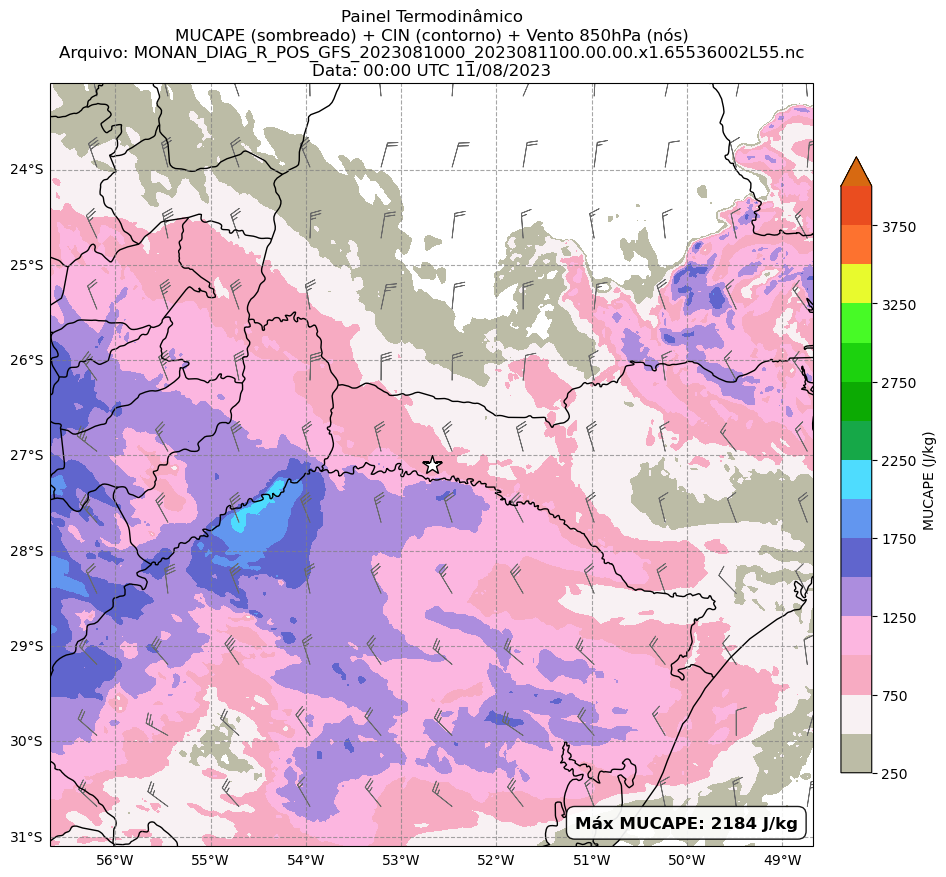

In [82]:
#PAINEL TERMODINAMICO — MUCAPE (sombreado) + CIN (contorno) + vento 850hPa (barbelas)
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

# Caminhos
pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
output_path = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810/Painel_Termodinamico'
os.makedirs(output_path, exist_ok=True)

# Shapefile municípios
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8
)

delta = 4  # zoom
site_lon, site_lat = -52.6791, -27.0972

lon_min, lon_max = site_lon - delta, site_lon + delta
lat_min, lat_max = site_lat - delta, site_lat + delta

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        nome_arquivo = os.path.basename(arquivo)
        try:
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"

        xrds = xr.open_dataset(caminho_arquivo)

        lat = xrds['latitude'].values
        lon = xrds['longitude'].values

        # 1. MUCAPE e CIN (2D, ja prontos no arquivo)
        mucape = xrds['mucape'][0].values
        mucin = xrds['sbcin'][0].values

        # 2. Vento em 850 hPa, extraido de campos 3D (level, lat, lon)
        #    ATENCAO: confira os nomes das variaveis no seu dataset
        uwind = xrds['uzonal'].values        # (level, lat, lon), m/s
        vwind = xrds['umeridional'].values        # (level, lat, lon), m/s
        level_pa = xrds['level'].values     # (level,), Pa

        idx_850 = int(np.argmin(np.abs(level_pa - 85000.0)))
        u850_ms = uwind[0][idx_850]
        v850_ms = vwind[0][idx_850]
        u850_kt = u850_ms * 1.94384
        v850_kt = v850_ms * 1.94384

        # 3. Recorte de zoom para o valor maximo de MUCAPE
        if lon.ndim == 1 and lat.ndim == 1:
            lon_2d, lat_2d = np.meshgrid(lon, lat)
        else:
            lon_2d, lat_2d = lon, lat

        mascara_zoom = (lon_2d >= lon_min) & (lon_2d <= lon_max) & (lat_2d >= lat_min) & (lat_2d <= lat_max)
        max_mucape_recorte = np.nanmax(np.where(mascara_zoom, mucape, np.nan))

        # ---------------------------------------
        # Plotagem
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # MUCAPE sombreado
        cape_plot = ax.contourf(
            lon, lat, mucape, transform=ccrs.PlateCarree(),
            cmap='pd17_c', levels=np.arange(250, 4250, 250),
            extend='max'
        )
        plt.colorbar(cape_plot, label='MUCAPE (J/kg)', shrink=0.8, pad=0.03)

        # CIN em contorno (so onde ha inibicao relevante)
        cin_levels = [-200, -100, -50, -25]
        cin_contour = ax.contour(
            lon, lat, mucin, transform=ccrs.PlateCarree(),
            levels=cin_levels, colors='black', linewidths=0.8, linestyles='dashed'
        )
        ax.clabel(cin_contour, inline=True, fontsize=7, fmt='%d')

        # Vento 850 hPa em barbelas
        step = 28
        ax.barbs(lon[::step], lat[::step],
                 u850_kt[::step, ::step], v850_kt[::step, ::step],
                 transform=ccrs.PlateCarree(), length=6, color='dimgray', linewidth=0.6)

        # Elementos do mapa
        # ax.add_feature(municipios_feature)  # Shapefile
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)

        ax.plot(site_lon, site_lat, marker='*', markersize=15,
                color='white', markeredgecolor='black', transform=ccrs.PlateCarree())

        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.7)
        gl.top_labels = gl.right_labels = False

        plt.title(
            f"Painel Termodinâmico\nMUCAPE (sombreado) + CIN (contorno) + Vento 850hPa (nós)\nArquivo: {nome_arquivo}\nData: {data_hora}",
            fontsize=12, loc='center'
        )

        ax.text(0.98, 0.02, f'Máx MUCAPE: {max_mucape_recorte:.0f} J/kg',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))
        # ---------------------------------------

        output_filename = os.path.join(output_path, f'Termodinamico_Zoom_{raw_data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        xrds.close()

In [ ]:
#PAINEL SEVERIDADE — SHIP (sombreado) + Shear 0-6km (vetores/contorno)
import os
import sys
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

sys.path.append('/home/jovyan/privado/MONAN')  # ajuste se necessario
from severe_utils import (
    mixing_ratio_gkg_from_spechum,
    lapse_rate_700_500,
    isotherm_height,
    compute_ship,
)

# Caminhos
pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
output_path = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810/Painel_Severidade'
os.makedirs(output_path, exist_ok=True)

# Shapefile municípios
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8
)

delta = 4  # zoom
site_lon, site_lat = -52.6791, -27.0972

lon_min, lon_max = site_lon - delta, site_lon + delta
lat_min, lat_max = site_lat - delta, site_lat + delta

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        nome_arquivo = os.path.basename(arquivo)
        try:
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"

        xrds = xr.open_dataset(caminho_arquivo)

        lat = xrds['latitude'].values
        lon = xrds['longitude'].values

        # 1. Cisalhamento 0-6km (m/s)
        u_10m_ms = xrds['u10'][0].values
        v_10m_ms = xrds['v10'][0].values
        u_6km_ms = xrds['uzonal_6km'][0].values
        v_6km_ms = xrds['umeridional_6km'][0].values

        u_diff_ms = u_6km_ms - u_10m_ms
        v_diff_ms = v_6km_ms - v_10m_ms
        shear_0_6km_ms = np.sqrt(u_diff_ms**2 + v_diff_ms**2)
        shear_0_6km_kt = shear_0_6km_ms * 1.94384

        # 2. MUCAPE
        mucape = xrds['mucape'][0].values

        # 3. Campos 3D em niveis isobaricos (level[0] = superficie)
        #    ATENCAO: confira os nomes das variaveis no seu dataset
        zgeo = xrds['zgeo'].isel(Time=0).values
        temperature_k = xrds['temperature'].isel(Time=0).values
        spechum = xrds['spechum'].isel(Time=0).values
        
        # Level geralmente é apenas (level,), mas garantimos sua extração limpa
        level_pa = xrds['level'].values
        # 4. Lapse rate 700-500 hPa e temperatura em 500 hPa
        lapse75, t500_c = lapse_rate_700_500(zgeo, temperature_k, level_pa)

        # 5. Freezing level (isoterma de 0°C)
        freezing_level_m = isotherm_height(zgeo, temperature_k, target_c=0.0)

        # 6. Mixing ratio do parcel MU — aproximacao via specific humidity de superficie
        mu_mixr_gkg = mixing_ratio_gkg_from_spechum(spechum[0])

        # 7. SHIP
        ship = compute_ship(
            mucape=mucape,
            mu_mixr_gkg=mu_mixr_gkg,
            lapse75=lapse75,
            t500_c=t500_c,
            shear06_ms=shear_0_6km_ms,
            freezing_level_m=freezing_level_m,
        )

        # 8. Recorte de zoom para o valor maximo de SHIP
        if lon.ndim == 1 and lat.ndim == 1:
            lon_2d, lat_2d = np.meshgrid(lon, lat)
        else:
            lon_2d, lat_2d = lon, lat

        mascara_zoom = (lon_2d >= lon_min) & (lon_2d <= lon_max) & (lat_2d >= lat_min) & (lat_2d <= lat_max)
        max_ship_recorte = np.nanmax(np.where(mascara_zoom, ship, np.nan))

        # ---------------------------------------
        # Plotagem
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # SHIP sombreado
        ship_plot = ax.contourf(
            lon, lat, ship, transform=ccrs.PlateCarree(),
            cmap='pd17_c', levels=np.arange(0.5, 5.5, 0.5),
            extend='max'
        )
        plt.colorbar(ship_plot, label='SHIP (Adimensional)', shrink=0.8, pad=0.03)

        # Shear 0-6km em contorno (magnitude, nós)
        shear_levels = [10, 20, 30, 40, 50]
        shear_contour = ax.contour(
            lon, lat, shear_0_6km_kt, transform=ccrs.PlateCarree(),
            levels=shear_levels, colors='black', linewidths=0.8, linestyles='dashed'
        )
        ax.clabel(shear_contour, inline=True, fontsize=7, fmt='%d kt')

        # Shear 0-6km em vetores (barbelas)
        step = 28
        ax.barbs(lon[::step], lat[::step],
                 u_diff_ms[::step, ::step] * 1.94384, v_diff_ms[::step, ::step] * 1.94384,
                 transform=ccrs.PlateCarree(), length=6, color='dimgray', linewidth=0.6)

        # Elementos do mapa
        # ax.add_feature(municipios_feature)  # Shapefile
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)

        ax.plot(site_lon, site_lat, marker='*', markersize=15,
                color='white', markeredgecolor='black', transform=ccrs.PlateCarree())

        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.7)
        gl.top_labels = gl.right_labels = False

        plt.title(
            f"Painel de Severidade\nSHIP (sombreado) + Shear 0-6km (vetores/contorno, nós)\nArquivo: {nome_arquivo}\nData: {data_hora}",
            fontsize=12, loc='center'
        )

        ax.text(0.98, 0.02, f'Máx SHIP: {max_ship_recorte:.1f}',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))
        

        output_filename = os.path.join(output_path, f'Severidade_Zoom_{raw_data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        xrds.close()

In [ ]:
#PAINEL ZONA DE CRESCIMENTO — Espessura 0°C a -20°C (sombreado) + WBZ (contorno)
import os
import sys
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature

sys.path.append('/home/jovyan/privado/MONAN')  # ajuste se necessario
from severe_utils import isotherm_height, wbz_height

# Caminhos
pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
output_path = '/home/jovyan/privado/MONAN/granizo202308/Saidas20230810/Painel_Zona_Crescimento'
os.makedirs(output_path, exist_ok=True)

# Shapefile municípios
shp_path = '/home/jovyan/privado/SC_Municipios_2023.shp'
municipios_reader = shpreader.Reader(shp_path)
municipios_feature = ShapelyFeature(
    municipios_reader.geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.5,
    alpha=0.8
)

delta = 4  # zoom
site_lon, site_lat = -52.6791, -27.0972

lon_min, lon_max = site_lon - delta, site_lon + delta
lat_min, lat_max = site_lat - delta, site_lat + delta

for arquivo in os.listdir(pasta):
    if arquivo.endswith('.nc'):
        caminho_arquivo = os.path.join(pasta, arquivo)

        nome_arquivo = os.path.basename(arquivo)
        try:
            raw_data_hora = nome_arquivo.split('_')[6].split('.')[0]
            data_hora = f'{raw_data_hora[8:10]}:00 UTC {raw_data_hora[6:8]}/{raw_data_hora[4:6]}/{raw_data_hora[:4]}'
        except IndexError:
            data_hora = "Data Desconhecida"

        xrds = xr.open_dataset(caminho_arquivo)

        lat = xrds['latitude'].values
        lon = xrds['longitude'].values

        # Campos 3D em niveis isobaricos (level[0] = superficie)
        # ATENCAO: confira os nomes das variaveis no seu dataset
        zgeo = xrds['height'].values             # (level, lat, lon), metros
        temperature_k = xrds['temperature'].values  # (level, lat, lon), K
        relhum_pct = xrds['relhum'].values        # (level, lat, lon), %

        # 1. Altura da isoterma de 0°C e de -20°C -> espessura da zona de
        #    crescimento do granizo (camada classica para wet growth)
        h_0c = isotherm_height(zgeo, temperature_k, target_c=0.0)
        h_m20c = isotherm_height(zgeo, temperature_k, target_c=-20.0)
        espessura_0_m20 = h_0c - h_m20c

        # 2. Wet-bulb zero (WBZ), usando RH em superficie como aproximacao
        #    (wbz_height espera relhum_pct com a mesma shape de temperature_k;
        #    se voce tiver o perfil 3D completo de RH, passe ele direto)
        wbz_m = wbz_height(zgeo, temperature_k, relhum_pct)

        # 3. Recorte de zoom para o valor maximo de espessura
        if lon.ndim == 1 and lat.ndim == 1:
            lon_2d, lat_2d = np.meshgrid(lon, lat)
        else:
            lon_2d, lat_2d = lon, lat

        mascara_zoom = (lon_2d >= lon_min) & (lon_2d <= lon_max) & (lat_2d >= lat_min) & (lat_2d <= lat_max)
        max_espessura_recorte = np.nanmax(np.where(mascara_zoom, espessura_0_m20, np.nan))

        # ---------------------------------------
        # Plotagem
        plt.figure(figsize=(12, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())

        # Espessura 0°C a -20°C sombreada
        esp_plot = ax.contourf(
            lon, lat, espessura_0_m20, transform=ccrs.PlateCarree(),
            cmap='pd17_c', levels=np.arange(500, 4000, 250),
            extend='both'
        )
        plt.colorbar(esp_plot, label='Espessura 0°C a -20°C (m)', shrink=0.8, pad=0.03)

        # WBZ em contorno
        wbz_levels = np.arange(1000, 4500, 500)
        wbz_contour = ax.contour(
            lon, lat, wbz_m, transform=ccrs.PlateCarree(),
            levels=wbz_levels, colors='black', linewidths=0.8, linestyles='dashed'
        )
        ax.clabel(wbz_contour, inline=True, fontsize=7, fmt='%d m')

        # Elementos do mapa
        # ax.add_feature(municipios_feature)  # Shapefile
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines(resolution='10m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

        estados = cfeature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='10m',
            facecolor='none'
        )
        ax.add_feature(estados, edgecolor='black', linewidth=1)

        ax.plot(site_lon, site_lat, marker='*', markersize=15,
                color='white', markeredgecolor='black', transform=ccrs.PlateCarree())

        gl = ax.gridlines(draw_labels=True, linestyle="--", color="gray", alpha=0.7)
        gl.top_labels = gl.right_labels = False

        plt.title(
            f"Painel de Zona de Crescimento\nEspessura 0°C a -20°C (sombreado) + WBZ (contorno, m)\nArquivo: {nome_arquivo}\nData: {data_hora}",
            fontsize=12, loc='center'
        )

        ax.text(0.98, 0.02, f'Máx espessura: {max_espessura_recorte:.0f} m',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=12, fontweight='bold', color='black',
                bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='round,pad=0.5'))
        # ---------------------------------------

        output_filename = os.path.join(output_path, f'ZonaCrescimento_Zoom_{raw_data_hora}.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        plt.close()
        xrds.close()

In [9]:
#PAINEL SEVERIDADE (DEBUG) — diagnostico dos inputs do SHIP
import os
import sys
import xarray as xr
import numpy as np

sys.path.append('/home/jovyan/privado/MONAN')  # ajuste se necessario
from severe_utils import (
    mixing_ratio_gkg_from_spechum,
    lapse_rate_700_500,
    isotherm_height,
    compute_ship,
)

pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'

arquivo = sorted(f for f in os.listdir(pasta) if f.endswith('.nc'))[0]
caminho_arquivo = os.path.join(pasta, arquivo)
xrds = xr.open_dataset(caminho_arquivo)

# 1. Cisalhamento 0-6km (m/s)
u_10m_ms = xrds['u10'][0].values
v_10m_ms = xrds['v10'][0].values
u_6km_ms = xrds['uzonal_6km'][0].values
v_6km_ms = xrds['umeridional_6km'][0].values
u_diff_ms = u_6km_ms - u_10m_ms
v_diff_ms = v_6km_ms - v_10m_ms
shear_0_6km_ms = np.sqrt(u_diff_ms**2 + v_diff_ms**2)

# 2. MUCAPE
mucape = xrds['mucape'][0].values

# 3. Campos 3D
zgeo = xrds['zgeo'].isel(Time=0).values
temperature_k = xrds['temperature'].isel(Time=0).values
spechum = xrds['spechum'].isel(Time=0).values
level_pa = xrds['level'].values

print("level_pa (primeiros 10):", level_pa[:10])
print("level_pa min/max:", level_pa.min(), level_pa.max())
print("zgeo shape:", zgeo.shape, "| zgeo[0] (deve ser ~superficie) min/max:", zgeo[0].min(), zgeo[0].max())
print("zgeo[-1] (deve ser ~topo) min/max:", zgeo[-1].min(), zgeo[-1].max())

lapse75, t500_c = lapse_rate_700_500(zgeo, temperature_k, level_pa)
freezing_level_m = isotherm_height(zgeo, temperature_k, target_c=0.0)
mu_mixr_gkg = mixing_ratio_gkg_from_spechum(spechum[0])

for name, arr in [
    ('mucape', mucape),
    ('mu_mixr_gkg', mu_mixr_gkg),
    ('lapse75', lapse75),
    ('t500_c', t500_c),
    ('shear_0_6km_ms', shear_0_6km_ms),
    ('freezing_level_m', freezing_level_m),
]:
    arr = np.asarray(arr, dtype=np.float64)
    print(
        f"{name:18s} min={np.nanmin(arr): .3f}  max={np.nanmax(arr): .3f}  "
        f"mean={np.nanmean(arr): .3f}  %NaN={100*np.isnan(arr).mean():.1f}"
    )

ship = compute_ship(
    mucape=mucape, mu_mixr_gkg=mu_mixr_gkg, lapse75=lapse75, t500_c=t500_c,
    shear06_ms=shear_0_6km_ms, freezing_level_m=freezing_level_m,
)
print(f"{'ship':18s} min={np.nanmin(ship): .3f}  max={np.nanmax(ship): .3f}  mean={np.nanmean(ship): .3f}")

xrds.close()

level_pa (primeiros 10): [100000.  97500.  95000.  92500.  90000.  87500.  85000.  82500.  80000.
  77500.]
level_pa min/max: 300.0 100000.0
zgeo shape: (30, 1492, 1492) | zgeo[0] (deve ser ~superficie) min/max: nan nan
zgeo[-1] (deve ser ~topo) min/max: nan nan
mucape             min= 0.000  max= 716.178  mean= 30.808  %NaN=53.9
mu_mixr_gkg        min= 0.632  max= 14.562  mean= 8.524  %NaN=53.9
lapse75            min= nan  max= nan  mean= nan  %NaN=100.0
t500_c             min= nan  max= nan  mean= nan  %NaN=100.0
shear_0_6km_ms     min= inf  max= inf  mean= inf  %NaN=53.9
freezing_level_m   min= 1507.246  max= 5320.320  mean= 4215.252  %NaN=53.9
ship               min= 0.000  max= 0.000  mean= 0.000


In [10]:
import os
import sys
import xarray as xr
import numpy as np

pasta = '/home/jovyan/privado/MONAN/granizo2308/2023081000/'
arquivo = sorted(f for f in os.listdir(pasta) if f.endswith('.nc'))[0]
xrds = xr.open_dataset(os.path.join(pasta, arquivo))

zgeo = xrds['zgeo'].isel(Time=0).values
temperature_k = xrds['temperature'].isel(Time=0).values
level_pa = xrds['level'].values

idx_700 = int(np.argmin(np.abs(level_pa - 70000.0)))
idx_500 = int(np.argmin(np.abs(level_pa - 50000.0)))
print(f"idx_700={idx_700} (level_pa={level_pa[idx_700]}), idx_500={idx_500} (level_pa={level_pa[idx_500]})")
print()

print(f"{'nivel':>3} {'level_pa':>10} {'%NaN zgeo':>10} {'%NaN temp':>10} {'zgeo min':>10} {'zgeo max':>10}")
for k in range(zgeo.shape[0]):
    nan_z = 100 * np.isnan(zgeo[k]).mean()
    nan_t = 100 * np.isnan(temperature_k[k]).mean()
    zmin = np.nanmin(zgeo[k]) if nan_z < 100 else float('nan')
    zmax = np.nanmax(zgeo[k]) if nan_z < 100 else float('nan')
    marca = "  <-- 700hPa" if k == idx_700 else ("  <-- 500hPa" if k == idx_500 else "")
    print(f"{k:>3} {level_pa[k]:>10.0f} {nan_z:>10.1f} {nan_t:>10.1f} {zmin:>10.1f} {zmax:>10.1f}{marca}")

xrds.close()

idx_700=11 (level_pa=70000.0), idx_500=15 (level_pa=50000.0)

nivel   level_pa  %NaN zgeo  %NaN temp   zgeo min   zgeo max
  0     100000       53.9       53.9       58.4      278.6
  1      97500       53.9       53.9      274.0      488.8
  2      95000       53.9       53.9      495.2      702.8
  3      92500       53.9       53.9      722.2      920.9
  4      90000       53.9       53.9      955.5     1143.3
  5      87500       53.9       53.9     1193.8     1375.7
  6      85000       53.9       53.9     1437.9     1616.8
  7      82500       53.9       53.9     1687.4     1864.1
  8      80000       53.9       53.9     1944.7     2118.0
  9      77500       53.9       53.9     2210.7     2378.9
 10      75000       53.9       53.9     2484.6     2647.1
 11      70000       53.9       53.9     3055.6     3207.6  <-- 700hPa
 12      65000       53.9       53.9     3655.3     3803.9
 13      60000       53.9       53.9     4292.3     4444.8
 14      55000       53.9       53.9   